# TraffIQ — Vehicle Analysis + ANPR Pipeline (single Colab notebook)

End-to-end: **vehicle detection → tracking → multi-colour HEX estimation → plate detection → crop → LPSR → Real-ESRGAN → char.pt → TrOCR → OCR fusion → structured JSON**.

---

## What was inspected, and what was decided

Four notebooks were supplied and read in full before any code was written.

| File | What it actually contains | Decision |
|---|---|---|
| `vehicle_detection_hex_colour_estimator.ipynb` | Ultralytics `YOLO("best_vehicle.pt")`, `imgsz=960, conf=0.25`. Plus a large classical colour estimator: GrabCut foreground → body spatial prior → edge softness → specular/glass/dark penalties → weighted sampling → LAB KMeans → cluster scoring → trimmed-LAB representative → HEX. Also `HexColourTrackMemory` (per-track EMA on RGB). | **Reused verbatim.** Every private helper (`_grabcut_mask`, `_body_spatial_prior`, `_edge_softness`, `_normalised_rgb`, `_hex_from_lab`, `_prepare_candidate_pixels`, `_select_paint_cluster`, `_robust_representative_lab`) is carried over unchanged. A **multi-colour layer was added on top** — it does not replace the single-colour path, it consumes the same clusters. |
| `lpsr_test.ipynb` | Custom `TraffiqLPSR` = head conv → 4× `CSARBlock` (RDB(64,growth 32,4 layers) + ChannelAttention + SpatialAttention) → global fusion → reconstruction → **global residual** → `clamp(0,1)`. Checkpoint is a dict with `model_state_dict`. Input is **letterboxed to 256×64** on a black canvas, `float32/255`, NCHW. | **Reused verbatim.** Architecture copied exactly so `load_state_dict(strict=True)` still works. |
| `Real_Esrgan.ipynb` | Two things: (a) a second copy of the identical `TraffiqLPSR` (confirms the architecture), (b) `RealESRGANer(scale=2, model=RRDBNet(...scale=2), model_path=RealESRGAN_x2plus.pth)` fed **with the LPSR output**, not the raw crop. | **Chain order reused** (LPSR → ESRGAN ×2). The Python-3.11 venv + subprocess workaround was **dropped** — see the Real-ESRGAN section for why, and what replaced it. |
| `char_test.ipynb` | `YOLO(char_epoch2/best.pt)`, `imgsz=640, conf=0.30, iou=0.45`. Detections are sorted by box centre-x and concatenated. Then: Indian state-code table, `LETTER_TO_DIGIT` / `DIGIT_TO_LETTER` confusion maps, segment-length patterns `[2,1,1,4] … [2,2,3,4]`, BH-series regex, `is_normal_plate` regex set. | **Reused.** All tables, regexes and the position-aware corrector are carried over. |

---

## ⚠️ Correction to one assumption in the brief

The brief says char.pt may be a **Character Time-series Matching** model (chequanghuy/Character-Time-series-Matching) and warns against simplifying it into ordinary classification.

**Your `char.pt` is not that.** `char_test.ipynb` loads it with `ultralytics.YOLO(...)` and reads `box.xyxy / box.conf / box.cls / model.names` — it is a **YOLO character *detector*** (one box per character, class = the character glyph). There is no LSTM, no temporal head, no paired raw+enhanced input, no time-series tensor anywhere in the supplied file. Inventing those tensor shapes would break loading.

What was preserved instead is the part of CTSM that *is* applicable and *is* the reason that repo exists — **reading detections as an ordered sequence rather than a bag of boxes**. The supplied notebook does this with a single `sort(key=x_centre)`, which silently corrupts **two-line Indian plates** (it interleaves the top and bottom rows). This notebook keeps the x-sort for single-line plates and adds **row clustering first, then x-sort within each row** — that is CTSM's sequence-ordering idea, applied correctly. Documented in §16.

Nothing was invented about char.pt's architecture. If you later supply a genuine CTSM checkpoint, replace `run_char_model` only — the rest of the pipeline is unaffected.

---

## Newly implemented (not present in any supplied file)

- **License-plate detector** — no supplied file contains one. Loaded through an architecture-probing loader (§12), not an assumed YOLO call.
- **TrOCR** — not present in any file. `microsoft/trocr-base-printed`, documented, swappable.
- **Multi-colour clustering + perceptual merge** (§10).
- **Tracking** — ByteTrack via Ultralytics' built-in `model.track()`, which requires no new dependency.
- **OCR fusion**, **plate cropping**, **temporal multi-colour fusion**, **error isolation**, **JSON export**, **video pipeline**.

# 2. Pipeline Architecture

```
INPUT IMAGE / VIDEO FRAME
        |
        v
[AI]  VEHICLE DETECTION            (YOLO, supplied .pt)
        |
        +---------------------------+
        |                           |
        v                           v
   VEHICLE BBOX               [AI] BYTETRACK  -> track_id   (video only)
        |                           |
        v                           |
[CLASSICAL] MULTI-COLOUR ESTIMATION |
   grabcut -> body prior ->         |
   paint weighting -> LAB kmeans -> |
   significance -> merge -> HEX[]   |
        |                           |
        +-------------+-------------+
                      |
                      v
        [AI]  LICENSE PLATE DETECTION   (searched inside vehicle crop)
                      |
                      v
        [CLASSICAL] PADDED PLATE CROP
                      |
                      v
        [AI]  LPSR  (TraffiqLPSR, 256x64 letterbox, 1:1 restoration)
                      |
                      v
        [CLASSICAL] UN-LETTERBOX (remove black bars)
                      |
                      v
        [AI]  REAL-ESRGAN x2        (restoration / sharpening)
                      |
              +-------+-------+
              |               |
              v               v
        [AI] CHAR.PT      [AI] TrOCR
        (char detector)   (seq2seq OCR)
              |               |
              v               v
     row-cluster + x-sort   text + seq confidence
     -> char sequence
              |               |
              +-------+-------+
                      |
                      v
        [CLASSICAL] OCR FUSION  (explainable, per-position)
                      |
                      v
        [CLASSICAL] INDIAN PLATE VALIDATION  (separate layer)
                      |
                      v
              STRUCTURED JSON
```

**Layer legend** — `[AI]` = learned model inference, `[CLASSICAL]` = deterministic CV/algorithmic. Preprocessing is per-model (§18); post-processing (fusion, validation) never touches the models.

# 4. Dependency Installation

Run once per Colab session, then **Runtime → Restart session is *not* required** unless pip reports a version conflict.

**Deliberately not done here:**

- **PyTorch / torchvision are never touched.** Colab's preinstalled build is what your `.pt` and `.pth` checkpoints were exercised against. Upgrading is the single most likely way to break `load_state_dict(strict=True)`.
- **`basicsr` / `realesrgan` are not pip-installed by default.** Your `Real_Esrgan.ipynb` had to build a whole separate Python 3.11 venv and shell out through `subprocess` because `basicsr` imports `torchvision.transforms.functional_tensor`, which was removed in torchvision 0.17. That workaround cannot share tensors with the rest of a single-notebook pipeline. This notebook instead defines the **same RRDBNet architecture inline** and loads the **same official `RealESRGAN_x2plus.pth` weights** — identical maths, zero dependency risk. Set `REALESRGAN_BACKEND = "basicsr"` in the config if you have a working `basicsr` install and prefer it.

**One version is deliberately pinned:** `transformers<5.0.0`. Transformers v5 removed the "slow"/"fast" tokenizer split and consolidated to one backend per model; `microsoft/trocr-base-printed` ships only the legacy `vocab.json`/`merges.txt` tokenizer files, and under v5's new backend that repo can fail to load with `Couldn't instantiate the backend tokenizer...` even with `sentencepiece` installed — it isn't a missing dependency, it's a compatibility gap between an older Hub repo and the newest major library version. Pinning below v5 is the fix. If a previous cell run already imported transformers 5.x in this session, the install cell detects that and tells you to restart the runtime — pip cannot hot-swap an already-imported package.

In [116]:
# ============================================================
# DEPENDENCY INSTALLATION  (run once per Colab session)
# ============================================================
#
# Nothing here upgrades torch / torchvision on purpose.
# ============================================================

import subprocess
import sys


def _pip(*args):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *args],
        check=False,
    )


# Vehicle / plate / character detection + ByteTrack (bundled with ultralytics)
_pip("ultralytics>=8.1.0")

# TrOCR.
#
# Pinned BELOW v5 on purpose. transformers v5 (Nov 2025) removed the
# "slow"/"fast" tokenizer split entirely and consolidated everything
# into one tokenizer backend per model. Repos on the Hub that only
# ship legacy vocab.json/merges.txt (no tokenizer.json) -- which
# includes microsoft/trocr-base-printed -- can fail to instantiate
# under that new backend with:
#   "Couldn't instantiate the backend tokenizer from one of: ...
#    You need to have sentencepiece or tiktoken installed ..."
# even with sentencepiece installed and even with use_fast=False,
# because that flag no longer selects a different code path in v5.
# This is not a missing dependency; it is a v5 compatibility gap
# for older repos, so pinning is the actual fix, not a workaround.
#
# sentencepiece + protobuf are still installed because several
# tokenizers genuinely need them regardless of transformers version.
_pip("transformers>=4.42.0,<5.0.0", "sentencepiece", "protobuf")

# opencv / pillow / numpy / matplotlib ship with Colab already.


# ------------------------------------------------------------
# VERSION REPORT
# ------------------------------------------------------------

import importlib

print("=" * 70)
print("INSTALLED VERSIONS")
print("=" * 70)

_versions = {}

for module_name in [
    "torch",
    "torchvision",
    "ultralytics",
    "transformers",
    "cv2",
    "numpy",
    "PIL",
    "sentencepiece",
]:
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "unknown")
        _versions[module_name] = version
        print(f"{module_name:14s} : {version}")
    except Exception as exc:  # noqa: BLE001
        _versions[module_name] = None
        print(f"{module_name:14s} : NOT AVAILABLE ({exc})")

print("=" * 70)

# If transformers was already imported by an earlier cell run in
# THIS session before this pip install ran, Python will keep using
# the already-imported v5 module no matter what pip just installed
# on disk -- pip cannot hot-swap a loaded package. Say so explicitly
# rather than letting TrOCR fail later with a confusing error.
_tf_version = _versions.get("transformers") or ""

if _tf_version.split(".")[0:1] == ["5"]:
    print(
        "\n*** transformers 5.x is still active in this session. ***\n"
        "This notebook just installed a 4.x build, but if transformers\n"
        "was already imported earlier in this runtime, Python is still\n"
        "using the old 5.x import.\n\n"
        "Runtime -> Restart session, then re-run every cell from the\n"
        "top (this install cell included). Do NOT use 'Run all' without\n"
        "restarting first, or TrOCR will fail again with the same error.\n"
    )

INSTALLED VERSIONS
torch          : 2.11.0+cu128
torchvision    : 0.26.0+cu128
ultralytics    : 8.4.155
transformers   : 4.57.6
cv2            : 5.0.0
numpy          : 2.1.3
PIL            : 11.3.0
sentencepiece  : 0.2.2


In [117]:
# ============================================================
# 6. IMPORTS + 24. DEVICE + 29. REPRODUCIBILITY
# ============================================================

import os
import re
import sys
import json
import subprocess
import math
import time
import random
import traceback

from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from PIL import Image, ImageOps


# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Deterministic cuDNN where practical. This is a speed/determinism
# trade-off; benchmark=False stops cuDNN picking a different
# algorithm run-to-run.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# NOT deterministic even with the above, and documented as such:
#   - GrabCut uses its own internal RNG seeding per call (stable in
#     practice because we always pass the same crop).
#   - cv2.kmeans with KMEANS_PP_CENTERS is seeded internally by
#     OpenCV; results are stable for identical input but not
#     guaranteed identical across OpenCV versions.
#   - TF32 / cuDNN kernel selection on different GPU models will
#     produce tiny floating-point differences in LPSR / ESRGAN.
#   - TrOCR beam search is deterministic given identical logits.


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

CUDA_AVAILABLE = torch.cuda.is_available()

DEVICE = torch.device("cuda" if CUDA_AVAILABLE else "cpu")

# Ultralytics wants 0 / "cpu" rather than a torch.device
ULTRALYTICS_DEVICE = 0 if CUDA_AVAILABLE else "cpu"

print("=" * 70)
print("DEVICE")
print("=" * 70)
print("Device         :", DEVICE)
print("CUDA available :", CUDA_AVAILABLE)
print(
    "GPU name       :",
    torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "None (CPU mode)",
)
print(
    "CUDA version   :",
    torch.version.cuda if CUDA_AVAILABLE else "n/a",
)
print("Seed           :", SEED)
print("=" * 70)

if not CUDA_AVAILABLE:
    print(
        "\nNOTE: running on CPU. The pipeline is functional but LPSR,\n"
        "Real-ESRGAN and TrOCR will be slow. Video input is not\n"
        "recommended on CPU."
    )

DEVICE
Device         : cuda
CUDA available : True
GPU name       : Tesla T4
CUDA version   : 12.8
Seed           : 42


# Google Drive model storage (Colab)

Google Drive is used only as the **persistent source** for model checkpoints.
At runtime, all model files are copied into the isolated `/content/models`
directory and the pipeline loads **only from `/content/models`**.

This keeps the Drive copies safe and prevents model loading or downloads from
modifying the persistent files in `MyDrive/TraffIQ/models`.

If a required model is missing from Drive, the notebook can download public
weights into `/content/models` when a public source is configured. These
runtime downloads are **not written back to Drive**.

The Drive mount itself is persistent across notebook cells, but Google Colab
may ask you to authorize the mount again after a runtime/session reset.


In [118]:
from pathlib import Path
import shutil

# ============================================================
# GOOGLE DRIVE MODEL STORAGE (Google Colab)
# ============================================================
# Drive is the persistent SOURCE of trained/private checkpoints.
# Runtime copies live in /content/models and are the ONLY files
# used by the model loaders.
#
# IMPORTANT:
#   Drive models are never modified by this notebook.
#   Publicly downloaded runtime weights are also kept in
#   /content/models and are not copied back to Drive.
# ============================================================

USE_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = Path("/content/drive")
DRIVE_MODEL_DIR = DRIVE_MOUNT_POINT / "MyDrive" / "AI_Training" / "Models" / "Colab"

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "USE_GOOGLE_DRIVE=True, but this notebook is not running in Google Colab. "
            "Set USE_GOOGLE_DRIVE=False when running locally."
        ) from exc

    if not (DRIVE_MOUNT_POINT / "MyDrive").exists():
        drive.mount(str(DRIVE_MOUNT_POINT))

    DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Google Drive mounted: {DRIVE_MOUNT_POINT}")
    print(f"Persistent model source: {DRIVE_MODEL_DIR}")
else:
    print("Google Drive model source is disabled; using local/runtime models.")


Google Drive mounted: /content/drive
Persistent model source: /content/drive/MyDrive/AI_Training/Models/Colab


# 3 + 5. Configuration and Model Paths

**This is the only cell you normally need to edit.**

Every entry in `MODEL_CONFIG` is a **placeholder**. Place your own files in the configured Google Drive model folder (recommended), or set `USE_GOOGLE_DRIVE = False` and use `/content/models`. The cell below prints a readiness table telling you exactly which files are missing.

```
USER MUST PROVIDE THIS MODEL   -> vehicle_model       (.pt, YOLO)
USER MUST PROVIDE THIS MODEL   -> license_plate_model (.pt, YOLO)
USER MUST PROVIDE THIS MODEL   -> char_model          (.pt, YOLO char detector)
USER MUST PROVIDE THIS MODEL   -> lpsr_model          (.pth, TraffiqLPSR checkpoint)

AUTO-DOWNLOADED (public weights, not yours) -> realesrgan_model (RealESRGAN_x2plus.pth)
AUTO-DOWNLOADED (public weights, not yours) -> trocr            (HuggingFace hub)
```

Note on the LPSR path: the file in `lpsr_test.ipynb` is `lpsr_retrained_best.pth`, a **`.pth` checkpoint dict**, not a `.pt` TorchScript/YOLO file. The configured filename can be `.pth` or `.pt`; the loader accepts either extension and handles both a raw `state_dict` and a `{"model_state_dict": ...}` wrapper.

In [119]:
# ============================================================
# 3. CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# DIRECTORIES (26. Colab compatibility)
# ------------------------------------------------------------

BASE_DIR = Path("/content")

MODELS_DIR = BASE_DIR / "models"
INPUT_DIR = BASE_DIR / "input"
OUTPUT_DIR = BASE_DIR / "output"
DEBUG_DIR = BASE_DIR / "debug"

for directory in (MODELS_DIR, INPUT_DIR, OUTPUT_DIR, DEBUG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# MODEL FILE NAMES + SOURCE
# ------------------------------------------------------------
# Google Drive is the persistent source.
# /content/models is the isolated runtime directory.
#
# Edit MODEL_FILENAMES if your private checkpoint filenames differ.
# Real-ESRGAN is included here so it follows the same model-copy flow.

MODEL_FILENAMES = {
    "vehicle_model": "vehicle_model.pt",
    "license_plate_model": "license_plate_model.pt",
    "char_model": "char.pt",
    "lpsr_model": "lpsr.pth",
    "realesrgan_model": "RealESRGAN_x2plus.pth",
}

# All loaders use these runtime paths.
MODEL_CONFIG = {
    key: str(MODELS_DIR / filename)
    for key, filename in MODEL_FILENAMES.items()
}

# Real-ESRGAN loader expects this explicit runtime weight path.
REALESRGAN_WEIGHTS = MODEL_CONFIG["realesrgan_model"]

# Public Real-ESRGAN x2plus weights.
# If the Drive copy is missing, the setup/load logic downloads these
# directly into /content/models. They are never written back to Drive.
REALESRGAN_URL = (
    "https://github.com/xinntao/Real-ESRGAN/releases/download/"
    "v0.2.1/RealESRGAN_x2plus.pth"
)

TROCR_MODEL_ID = "microsoft/trocr-base-printed"

# ------------------------------------------------------------
# ISOLATED RUNTIME MODEL DIRECTORY
# ------------------------------------------------------------
# Copy persistent Drive checkpoints into /content/models.
# Existing runtime files are preserved; Drive is never modified.
# Real-ESRGAN is copied the same way when present in Drive.
# Public fallback downloads happen later directly into /content/models.

def sync_models_to_runtime():
    if not USE_GOOGLE_DRIVE:
        print(f"Runtime model directory: {MODELS_DIR}")
        return

    print(f"Syncing model sources from Drive -> {MODELS_DIR}")
    for key, filename in MODEL_FILENAMES.items():
        source = DRIVE_MODEL_DIR / filename
        destination = MODELS_DIR / filename

        if source.is_file():
            if not destination.is_file():
                shutil.copy2(source, destination)
                print(f"  copied {key}: {source.name} -> {destination}")
            else:
                print(f"  kept runtime copy: {destination}")
        else:
            print(f"  Drive copy missing: {key} ({source})")

sync_models_to_runtime()


# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------

INPUT_TYPE = "image"                      # "image" | "video"
INPUT_PATH = "/content/input/test.jpg"    # switch to test.mp4 for video


# ------------------------------------------------------------
# DEBUG (28)
# ------------------------------------------------------------

DEBUG = True


# ------------------------------------------------------------
# STAGE PARAMETERS
# ------------------------------------------------------------

# Vehicle detection -- values taken from
# vehicle_detection_hex_colour_estimator.ipynb
VEHICLE_CONF = 0.25
VEHICLE_IMGSZ = 960

# Plate detection -- no supplied file; conservative defaults
PLATE_CONF = 0.25
PLATE_IMGSZ = 640
PLATE_SEARCH_IN_VEHICLE_CROP = True   # 27. performance
PLATE_VEHICLE_CROP_PADDING = 0.05

# Character detection -- values taken from char_test.ipynb
CHAR_CONF = 0.30
CHAR_IOU = 0.45
CHAR_IMGSZ = 640

# Plate cropping
PLATE_CROP_PADDING = 0.10   # fraction of plate w/h added on each side

# LPSR -- fixed by the trained network (see lpsr_test.ipynb CELL 8)
LPSR_INPUT_W = 256
LPSR_INPUT_H = 64
LPSR_UNLETTERBOX = True     # strip the black padding bars after inference

# Real-ESRGAN
REALESRGAN_SCALE = 2
REALESRGAN_BACKEND = "inline"   # "inline" | "basicsr"
REALESRGAN_TILE = 0             # 0 = no tiling (plate crops are tiny)

# Which image each OCR stage consumes: "raw" | "lpsr" | "esrgan"
CHAR_INPUT = "esrgan"
TROCR_INPUT = "esrgan"

# OCR fusion
FUSION_TROCR_CONF_FLOOR = 0.30

# Multi-variant OCR ensemble
# Each reader and enhancement stage has an independently tunable weight.
# The raw plate dimensions decide which enhancement gets more authority.
OCR_ENSEMBLE_ENABLED = True
OCR_MODEL_WEIGHTS = {
    "char.pt": 1.00,
    "TrOCR": 1.00,
}
# Quality-aware OCR ensemble.  These are priors, not hard routing rules:
# every available RAW/LPSR/ESRGAN variant is still sent to OCR.
OCR_VARIANT_WEIGHTS_LARGE = {
    "raw": 1.25,
    "lpsr": 1.00,
    "esrgan": 0.95,
}
OCR_VARIANT_WEIGHTS_SMALL = {
    "raw": 0.80,
    "lpsr": 1.25,
    "esrgan": 0.80,
}

# v6.4 smooth enhancement preference.  These are deliberately soft priors:
# RAW tends to win on already-readable crops, ESRGAN has its strongest prior
# around moderate recoverability, and LPSR becomes strongest as information
# quality falls.  None of the variants is ever disabled.
OCR_RAW_QUALITY_GAIN = 0.85
OCR_LPSR_LOW_QUALITY_GAIN = 1.00
OCR_ESRGAN_MODERATE_GAIN = 1.00
OCR_ESRGAN_MODERATE_CENTER = 0.50
OCR_ESRGAN_MODERATE_WIDTH = 0.32
OCR_MIN_VARIANT_WEIGHT = 0.38

# Smooth transition around the old 20 px observation.  There is no
# hard 20 px cutoff anymore; quality can override the size prior.
OCR_SIZE_TRANSITION_PX = 20.0
OCR_SIZE_TRANSITION_SLOPE = 5.0

# Physical plate-readability signals.  These only affect weighting;
# they never reject a crop.  Tune on representative plate crops.
OCR_QUALITY_WEIGHTS = {
    "sharpness": 0.30,
    "contrast": 0.20,
    "entropy": 0.15,
    "edge_structure": 0.15,
    "exposure": 0.10,
    "resolution": 0.10,
}
OCR_SHARPNESS_SCALE = 80.0
OCR_CONTRAST_SCALE = 45.0
OCR_ENTROPY_SCALE = 7.0
OCR_EDGE_DENSITY_TARGET = 0.12
OCR_SIZE_SCORE_MIN_PX = 8.0
OCR_SIZE_SCORE_FULL_PX = 48.0

# How strongly physical quality modifies the size prior.  Keep this
# moderate: the ensemble should prefer an enhancement, not suppress it.
OCR_QUALITY_ROUTING_STRENGTH = 0.65
OCR_ESRGAN_LOW_QUALITY_PENALTY = 0.55
OCR_LPSR_LOW_QUALITY_BOOST = 0.55
OCR_ESRGAN_HIGH_QUALITY_BOOST = 0.25
OCR_RAW_STABILITY_BOOST = 0.10

# Candidate ranking / consensus settings.
OCR_CONSENSUS_BONUS = 0.20
OCR_SIMILARITY_BONUS = 0.18
OCR_MIN_SIMILARITY = 0.70
OCR_MIN_CONFIDENCE = 0.05
OCR_TOP_N_CANDIDATES = 10
OCR_STATE_PRIOR_STRENGTH = 0.24
OCR_STATE_PRIOR_MIN_EVIDENCE = 0.35
OCR_LENGTH_PRIOR_STRENGTH = 0.20
OCR_OBSERVED_LENGTH_PRIOR_STRENGTH = 0.10
OCR_FORMAT_PRIOR_STRENGTH = 0.24
OCR_FUZZY_PRIOR_STRENGTH = 0.12
OCR_MUTATION_PRIOR_STRENGTH = 0.10

# Indian plate post-processing (16)
APPLY_PLATE_NORMALIZATION = True

# Multi-colour estimation (6, 7)
COLOUR_MAX_COMPONENTS = 4
COLOUR_MIN_AREA_RATIO = 0.10     # cluster must hold >=10% of paint evidence
COLOUR_MERGE_DELTA_E = 14.0      # CIE76 in real Lab units
COLOUR_MERGE_HUE_TOLERANCE = 18.0  # deg; merges lit/shaded panels. 0 = off
COLOUR_KMEANS_K = 6

# The inherited body prior is car-shaped (suppresses roof + tyres).
# Large vehicles are mostly painted panel, so they get a flatter
# prior or their top/bottom colour bands are thrown away. Matching
# is a substring test against the class names YOUR model reports --
# edit this tuple to match your own class list.
LARGE_VEHICLE_KEYWORDS = (
    "bus", "truck", "lorry", "van", "tempo", "container", "trailer",
)
COLOUR_PRIOR_STRENGTH_LARGE = 0.35   # 1.0 = unchanged, lower = flatter

# Tracking / video (18, 19)
TRACKER_CFG = "bytetrack.yaml"
VIDEO_FRAME_STRIDE = 1
VIDEO_MAX_FRAMES = None          # None = whole video
COLOUR_EMA_ALPHA = 0.20
TRACK_MAX_MISSING = 60
# 27. don't re-run OCR every frame for a track that already read well
OCR_REFRESH_EVERY_N_FRAMES = 10
OCR_GOOD_ENOUGH_CONF = 0.85


# ------------------------------------------------------------
# READINESS REPORT
# ------------------------------------------------------------

print("=" * 78)
print("MODEL READINESS")
print("=" * 78)

_ANY_MISSING = False

for key, path in MODEL_CONFIG.items():
    exists = os.path.isfile(path)
    if exists:
        size_mb = os.path.getsize(path) / (1024 * 1024)
        status = f"OK  ({size_mb:.1f} MB)"
    else:
        status = "MISSING  <-- USER MUST PROVIDE THIS MODEL"
        _ANY_MISSING = True
    print(f"{key:22s} {status}")
    print(f"{'':22s} {path}")

print("-" * 78)
print(f"{'realesrgan_model':22s} auto-downloaded public weights")
print(f"{'trocr':22s} auto-downloaded from HuggingFace ({TROCR_MODEL_ID})")
print("-" * 78)

print(f"{'INPUT_TYPE':22s} {INPUT_TYPE}")
print(f"{'INPUT_PATH':22s} {INPUT_PATH}", end="")
print("   [OK]" if os.path.isfile(INPUT_PATH) else "   [MISSING]")
print(f"{'DEBUG':22s} {DEBUG}")
print("=" * 78)

if _ANY_MISSING:
    print(
        "\nUpload the missing files to /content/models/ (or edit MODEL_CONFIG\n"
        "to point at Google Drive) before running the model-loading cell."
    )

Syncing model sources from Drive -> /content/models
  kept runtime copy: /content/models/vehicle_model.pt
  kept runtime copy: /content/models/license_plate_model.pt
  kept runtime copy: /content/models/char.pt
  kept runtime copy: /content/models/lpsr.pth
  Drive copy missing: realesrgan_model (/content/drive/MyDrive/AI_Training/Models/Colab/RealESRGAN_x2plus.pth)
MODEL READINESS
vehicle_model          OK  (167.1 MB)
                       /content/models/vehicle_model.pt
license_plate_model    OK  (42.0 MB)
                       /content/models/license_plate_model.pt
char_model             OK  (19.4 MB)
                       /content/models/char.pt
lpsr_model             OK  (7.7 MB)
                       /content/models/lpsr.pth
realesrgan_model       OK  (64.0 MB)
                       /content/models/RealESRGAN_x2plus.pth
------------------------------------------------------------------------------
realesrgan_model       auto-downloaded public weights
trocr                  a

# 7. Model Loading

Models are loaded **exactly once** into a `MODELS` dict and reused for every frame — nothing in this notebook loads a model inside a loop.

### On not assuming every `.pt` is YOLO

`load_detection_model()` calls `ultralytics.YOLO(path)` **first**, because Ultralytics' own loader is the authority on whether a file is an Ultralytics checkpoint. Only if that raises does `probe_checkpoint()` run, purely to produce a useful error message (what the top-level keys are, whether it looks like a bare `state_dict`, TorchScript, or a pickled module).

**This ordering was a bug fix.** An earlier version probed first and refused to call `YOLO()` unless the probe approved. It then rejected a perfectly good trained detector — keys `['epoch', 'best_fitness', 'model', 'ema', 'optimizer', ...]` — as `"unknown"`, because after a plain `torch.load` the object under `model` did not satisfy `isinstance(..., nn.Module)`. Ultralytics does de-serialisation work that a naive `torch.load` does not reproduce: EMA weight selection, module path remapping, and version compatibility shims. The lesson generalises — **a gatekeeper that is less capable than the thing it guards will reject valid input.** So the probe informs, it no longer decides.

The LPSR checkpoint deliberately does not go through this path: `lpsr_test.ipynb` proves it is a `TraffiqLPSR` state dict, so it gets its own loader with `strict=True` so a silent architecture mismatch is impossible.

The two architecture classes below are declared here because loading needs them. Their *inference* code lives in §14 (LPSR) and §15 (Real-ESRGAN).

In [120]:
# ============================================================
# ARCHITECTURES
# ============================================================
#
# (a) TraffiqLPSR -- COPIED VERBATIM from lpsr_test.ipynb CELL 5
#     and independently confirmed by Real_Esrgan.ipynb CELL 11.
#     Do not "tidy" this: load_state_dict(strict=True) depends on
#     every module name and every channel count staying identical.
#
# (b) RRDBNet -- the Real-ESRGAN generator, declared inline so the
#     notebook does not need basicsr. Same topology and parameter
#     names as basicsr.archs.rrdbnet_arch.RRDBNet, so the official
#     RealESRGAN_x2plus.pth loads into it unchanged.
# ============================================================


# ------------------------------------------------------------
# (a) TraffIQ LPSR
# ------------------------------------------------------------

class RDB(nn.Module):
    """Residual Dense Block."""

    def __init__(self, channels=64, growth=32, num_layers=4):
        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(num_layers):
            in_channels = channels + i * growth
            self.layers.append(
                nn.Conv2d(in_channels, growth, kernel_size=3, padding=1)
            )

        self.local_fusion = nn.Conv2d(
            channels + num_layers * growth,
            channels,
            kernel_size=1,
        )

    def forward(self, x):
        features = [x]

        for layer in self.layers:
            inp = torch.cat(features, dim=1)
            out = F.relu(layer(inp), inplace=True)
            features.append(out)

        fused = self.local_fusion(torch.cat(features, dim=1))

        return fused + x


class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 4)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        attention = self.avg_pool(x)
        attention = self.fc(attention)
        return x * attention


class SpatialAttention(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maximum = torch.max(x, dim=1, keepdim=True)[0]
        combined = torch.cat([avg, maximum], dim=1)
        attention = torch.sigmoid(self.conv(combined))
        return x * attention


class CSARBlock(nn.Module):
    """Channel-Spatial Attention Residual block."""

    def __init__(self, channels=64):
        super().__init__()
        self.rdb = RDB(channels=channels)
        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        residual = x
        x = self.rdb(x)
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x + residual


class TraffiqLPSR(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=64,
        num_blocks=4,
    ):
        super().__init__()

        self.head = nn.Conv2d(
            in_channels, features, kernel_size=3, padding=1
        )

        self.blocks = nn.ModuleList(
            [CSARBlock(channels=features) for _ in range(num_blocks)]
        )

        self.global_fusion = nn.Conv2d(
            features * num_blocks, features, kernel_size=1
        )

        self.global_conv = nn.Conv2d(
            features, features, kernel_size=3, padding=1
        )

        self.reconstruction = nn.Sequential(
            nn.Conv2d(features, features, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(features, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        residual = x

        x = self.head(x)

        block_outputs = []

        for block in self.blocks:
            x = block(x)
            block_outputs.append(x)

        fused = torch.cat(block_outputs, dim=1)
        fused = self.global_fusion(fused)
        fused = self.global_conv(fused)

        output = self.reconstruction(fused)

        # Global residual learning: the network predicts a
        # correction to the input, not the image from scratch.
        output = output + residual

        return output.clamp(0, 1)


# ------------------------------------------------------------
# (b) RRDBNet (Real-ESRGAN generator)
# ------------------------------------------------------------

class ResidualDenseBlock(nn.Module):

    def __init__(self, num_feat=64, num_grow_ch=32):
        super().__init__()

        self.conv1 = nn.Conv2d(num_feat, num_grow_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_feat + num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_feat + 2 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_feat + 3 * num_grow_ch, num_grow_ch, 3, 1, 1)
        self.conv5 = nn.Conv2d(num_feat + 4 * num_grow_ch, num_feat, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):

    def __init__(self, num_feat, num_grow_ch=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb2 = ResidualDenseBlock(num_feat, num_grow_ch)
        self.rdb3 = ResidualDenseBlock(num_feat, num_grow_ch)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x


def _pixel_unshuffle(x, scale):
    b, c, hh, hw = x.size()
    out_channel = c * (scale ** 2)
    h = hh // scale
    w = hw // scale
    x_view = x.view(b, c, h, scale, w, scale)
    return (
        x_view.permute(0, 1, 3, 5, 2, 4)
        .reshape(b, out_channel, h, w)
    )


class RRDBNet(nn.Module):
    """
    scale=2 variant used by RealESRGAN_x2plus.pth.

    For scale 2 the input is pixel-unshuffled by 2 first, so
    conv_first sees 12 input channels. This matches basicsr.
    """

    def __init__(
        self,
        num_in_ch=3,
        num_out_ch=3,
        scale=2,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
    ):
        super().__init__()

        self.scale = scale

        if scale == 2:
            num_in_ch = num_in_ch * 4
        elif scale == 1:
            num_in_ch = num_in_ch * 16

        self.conv_first = nn.Conv2d(num_in_ch, num_feat, 3, 1, 1)

        self.body = nn.Sequential(
            *[RRDB(num_feat, num_grow_ch) for _ in range(num_block)]
        )

        self.conv_body = nn.Conv2d(num_feat, num_feat, 3, 1, 1)

        self.conv_up1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_feat, num_feat, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_feat, num_out_ch, 3, 1, 1)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        if self.scale == 2:
            feat = _pixel_unshuffle(x, scale=2)
        elif self.scale == 1:
            feat = _pixel_unshuffle(x, scale=4)
        else:
            feat = x

        feat = self.conv_first(feat)

        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat

        feat = self.lrelu(
            self.conv_up1(
                F.interpolate(feat, scale_factor=2, mode="nearest")
            )
        )
        feat = self.lrelu(
            self.conv_up2(
                F.interpolate(feat, scale_factor=2, mode="nearest")
            )
        )

        return self.conv_last(self.lrelu(self.conv_hr(feat)))


print("Architectures defined: TraffiqLPSR, RRDBNet")

Architectures defined: TraffiqLPSR, RRDBNet


In [121]:
# ============================================================
# 23. MODEL LOADING FUNCTIONS
# ============================================================

from ultralytics import YOLO


def probe_checkpoint(path):
    """
    DIAGNOSTIC ONLY. Never used to decide whether a file is
    loadable -- only to explain why loading failed.

    Returns (kind, info) where kind is one of:
        "ultralytics" | "state_dict" | "torchscript" |
        "module" | "unknown"
    """

    try:
        obj = torch.jit.load(str(path), map_location="cpu")
        del obj
        return "torchscript", {}
    except Exception:  # noqa: BLE001
        pass

    try:
        obj = torch.load(
            str(path), map_location="cpu", weights_only=False
        )
    except Exception as exc:  # noqa: BLE001
        raise RuntimeError(f"Could not read checkpoint {path}: {exc}")

    info = {}

    if isinstance(obj, dict):
        info["top_level_keys"] = list(obj.keys())[:20]

        inner = obj.get("model", None)

        if isinstance(inner, nn.Module):
            info["ultralytics_task"] = obj.get("task", "unknown")
            names = getattr(inner, "names", None)
            if names is not None:
                info["names"] = names
            return "ultralytics", info

        tensor_like = [
            k for k, v in obj.items() if isinstance(v, torch.Tensor)
        ]
        if tensor_like:
            info["tensor_keys"] = tensor_like[:20]
            return "state_dict", info

        for candidate in ("model_state_dict", "state_dict", "params_ema"):
            if candidate in obj and isinstance(obj[candidate], dict):
                info["wrapper_key"] = candidate
                info["tensor_keys"] = list(obj[candidate].keys())[:20]
                return "state_dict", info

        return "unknown", info

    if isinstance(obj, nn.Module):
        info["class"] = type(obj).__name__
        if hasattr(obj, "names"):
            info["names"] = obj.names
        return "module", info

    return "unknown", info


def load_detection_model(path, label):
    """
    Generic loader for the three DETECTION models
    (vehicle / license plate / character).

    Ultralytics' own loader is the authority on whether a file is
    an Ultralytics checkpoint. We try it FIRST and only fall back
    to probe_checkpoint() to explain a failure.

    An earlier version of this notebook probed first and refused to
    call YOLO() unless the probe approved. That was wrong: a real
    trained checkpoint -- keys ['epoch', 'best_fitness', 'model',
    'ema', 'optimizer', ...] -- was rejected as "unknown" because
    ckpt["model"] did not satisfy isinstance(..., nn.Module) after
    a plain torch.load, even though YOLO(path) loads it perfectly.
    Ultralytics does its own de-serialisation work (ema handling,
    module remapping, version shims) that a naive torch.load does
    not reproduce. So the probe is now diagnostics only.
    """

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"[{label}] USER MUST PROVIDE THIS MODEL -> {path}"
        )

    try:
        model = YOLO(str(path))

        names = getattr(model, "names", {})
        print(f"[{label}] loaded via ultralytics.YOLO")
        print(f"[{label}] classes ({len(names)}): {names}")

        return model

    except Exception as yolo_error:  # noqa: BLE001
        # Only now do we inspect the file, to say something useful.
        try:
            kind, info = probe_checkpoint(path)
        except Exception as probe_error:  # noqa: BLE001
            kind, info = "unreadable", {"error": str(probe_error)}

        raise RuntimeError(
            f"[{label}] ultralytics.YOLO could not load {path}\n"
            f"  YOLO error : {yolo_error}\n"
            f"  file looks like: {kind}\n"
            f"  top-level keys : {info.get('top_level_keys')}\n"
            f"  tensor keys    : {info.get('tensor_keys')}\n"
            "If this is not a YOLO model, define its architecture and "
            f"assign the loaded model into MODELS['...'] yourself."
        )


def load_vehicle_model(path=None):
    return load_detection_model(
        path or MODEL_CONFIG["vehicle_model"], "vehicle_model"
    )


def load_license_plate_model(path=None):
    return load_detection_model(
        path or MODEL_CONFIG["license_plate_model"], "license_plate_model"
    )


def load_char_model(path=None):
    return load_detection_model(
        path or MODEL_CONFIG["char_model"], "char_model"
    )


def load_lpsr_model(path=None, device=DEVICE):
    """
    Loads the TraffiqLPSR checkpoint.

    Handles both layouts seen in the supplied notebooks:
        checkpoint["model_state_dict"]   (lpsr_test.ipynb)
        raw state_dict                   (Real_Esrgan.ipynb fallback)

    strict=True on purpose: a silent partial load would produce
    plausible-looking but wrong images.
    """

    path = path or MODEL_CONFIG["lpsr_model"]

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"[lpsr_model] USER MUST PROVIDE THIS MODEL -> {path}"
        )

    model = TraffiqLPSR(
        in_channels=3,
        out_channels=3,
        features=64,
        num_blocks=4,
    ).to(device)

    checkpoint = torch.load(
        str(path), map_location=device, weights_only=False
    )

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
        print(
            "[lpsr_model] epoch:",
            checkpoint.get("epoch", "n/a"),
            "| best_val_loss:",
            checkpoint.get("best_val_loss", "n/a"),
        )
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict, strict=True)
    model.eval()

    print("[lpsr_model] loaded (strict=True)")

    return model


def load_realesrgan_model(device=DEVICE):
    """
    Downloads the official RealESRGAN_x2plus weights if absent and
    loads them into the inline RRDBNet.

    Returns None (with a warning) rather than raising, so the rest
    of the pipeline still runs without ESRGAN.
    """

    if REALESRGAN_BACKEND == "basicsr":
        try:
            from basicsr.archs.rrdbnet_arch import RRDBNet as _BasicSRRRDB
            from realesrgan import RealESRGANer

            net = _BasicSRRRDB(
                num_in_ch=3,
                num_out_ch=3,
                num_feat=64,
                num_block=23,
                num_grow_ch=32,
                scale=REALESRGAN_SCALE,
            )
            upsampler = RealESRGANer(
                scale=REALESRGAN_SCALE,
                model_path=REALESRGAN_WEIGHTS,
                model=net,
                tile=REALESRGAN_TILE,
                tile_pad=10,
                pre_pad=0,
                half=(device.type == "cuda"),
                device=device,
            )
            print("[realesrgan] basicsr backend ready")
            return {"backend": "basicsr", "upsampler": upsampler}
        except Exception as exc:  # noqa: BLE001
            print(
                "[realesrgan] basicsr backend unavailable "
                f"({exc}); falling back to inline."
            )

    if not os.path.isfile(REALESRGAN_WEIGHTS):
        print("[realesrgan] downloading public weights ...")
        os.makedirs(os.path.dirname(REALESRGAN_WEIGHTS), exist_ok=True)
        rc = subprocess.run(
            ["wget", "-q", "-c", REALESRGAN_URL, "-O", REALESRGAN_WEIGHTS]
        ).returncode
        if rc != 0 or not os.path.isfile(REALESRGAN_WEIGHTS):
            print("[realesrgan] download FAILED - stage will be skipped")
            return None

    size_mb = os.path.getsize(REALESRGAN_WEIGHTS) / (1024 * 1024)

    if size_mb < 50:
        print(
            f"[realesrgan] weight file is only {size_mb:.1f} MB "
            "(expected ~65 MB) - incomplete download, stage will be skipped"
        )
        return None

    net = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        scale=REALESRGAN_SCALE,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
    )

    checkpoint = torch.load(
        REALESRGAN_WEIGHTS, map_location="cpu", weights_only=False
    )

    for key in ("params_ema", "params", "state_dict"):
        if isinstance(checkpoint, dict) and key in checkpoint:
            checkpoint = checkpoint[key]
            break

    net.load_state_dict(checkpoint, strict=True)
    net.eval().to(device)

    print(f"[realesrgan] inline backend ready ({size_mb:.1f} MB, x{REALESRGAN_SCALE})")

    return {"backend": "inline", "net": net}


def load_trocr(model_id=TROCR_MODEL_ID, device=DEVICE):
    """
    TrOCR = ViT encoder + text decoder, trained on printed text
    lines. 'trocr-base-printed' is the documented choice here; it
    is a printed-text (SROIE) model rather than the handwritten
    variant, which is the closer match for license plates.

    Returns None on failure so the pipeline degrades gracefully.
    """

    try:
        from transformers import TrOCRProcessor, VisionEncoderDecoderModel
        import transformers as _transformers_module

        _tf_major = int(_transformers_module.__version__.split(".")[0])

        try:
            processor = TrOCRProcessor.from_pretrained(model_id)
        except Exception as tokenizer_error:  # noqa: BLE001
            if _tf_major >= 5:
                # use_fast no longer selects a different tokenizer
                # code path in v5 (the slow/fast split was removed),
                # so retrying with it here would just reproduce the
                # same error. Fail fast with the real explanation
                # instead of pretending a retry might help.
                raise RuntimeError(
                    "transformers "
                    f"{_transformers_module.__version__} is installed "
                    "in this session, but this notebook's install cell "
                    "pins transformers<5.0.0 because trocr-base-printed's "
                    "legacy tokenizer files are not reliably loadable "
                    "under transformers v5's consolidated tokenizer "
                    "backend. Runtime -> Restart session, then re-run "
                    "every cell from the top (install cell included)."
                ) from tokenizer_error

            # On 4.x this retry is meaningful: it forces the Python
            # tokenizer implementation instead of the Rust one, which
            # sidesteps a handful of genuine fast-tokenizer bugs.
            print(
                f"[trocr] fast tokenizer unavailable ({tokenizer_error}); "
                "retrying with use_fast=False"
            )
            processor = TrOCRProcessor.from_pretrained(
                model_id, use_fast=False
            )

        model = VisionEncoderDecoderModel.from_pretrained(model_id)
        model.eval().to(device)

        print(f"[trocr] loaded {model_id}")

        return {"processor": processor, "model": model, "model_id": model_id}

    except Exception as exc:  # noqa: BLE001
        print(f"[trocr] FAILED to load ({exc}) - stage will be skipped")
        return None


print("Loader functions defined.")

Loader functions defined.


In [122]:
# ============================================================
# LOAD EVERYTHING ONCE
# ============================================================
#
# MODELS is the single source of loaded weights for the whole
# notebook. Nothing below ever reloads a model.
#
# A missing/failed component is recorded as None instead of
# aborting, so you can still exercise the rest of the pipeline.
# ============================================================

MODELS = {
    "vehicle": None,
    "plate": None,
    "char": None,
    "lpsr": None,
    "realesrgan": None,
    "trocr": None,
}

_LOADERS = [
    ("vehicle", load_vehicle_model),
    ("plate", load_license_plate_model),
    ("char", load_char_model),
    ("lpsr", load_lpsr_model),
    ("realesrgan", load_realesrgan_model),
    ("trocr", load_trocr),
]

print("=" * 78)
print("LOADING MODELS")
print("=" * 78)

for name, loader in _LOADERS:
    print(f"\n--- {name} ---")
    try:
        MODELS[name] = loader()
    except Exception as exc:  # noqa: BLE001
        MODELS[name] = None
        print(f"[{name}] NOT LOADED: {exc}")

print("\n" + "=" * 78)
print("LOAD SUMMARY")
print("=" * 78)

for name in MODELS:
    print(f"{name:12s} : {'ready' if MODELS[name] is not None else 'NOT LOADED'}")

print("=" * 78)

# The vehicle detector is the root of the pipeline: without it there
# is nothing to colour, no region to search for a plate, and no
# record to build. Say so here rather than letting a later cell
# print a misleading "No vehicles detected".
if MODELS["vehicle"] is None:
    print(
        "\n*** THE VEHICLE MODEL DID NOT LOAD ***\n"
        "Every later stage will produce nothing. Fix this before\n"
        "running the pipeline - scroll up for the specific error.\n"
    )

for _critical in ("plate", "char", "lpsr"):
    if MODELS[_critical] is None:
        print(
            f"NOTE: '{_critical}' did not load; stages that need it will "
            "report a status and be skipped."
        )

# Class mapping comes from the model itself. Nothing is invented.
VEHICLE_CLASS_NAMES = (
    dict(MODELS["vehicle"].names) if MODELS["vehicle"] is not None else {}
)

CHAR_CLASS_NAMES = (
    dict(MODELS["char"].names) if MODELS["char"] is not None else {}
)

if VEHICLE_CLASS_NAMES:
    print("\nVehicle class mapping (read from the supplied checkpoint):")
    for class_id, class_name in sorted(VEHICLE_CLASS_NAMES.items()):
        print(f"  {class_id:3d} -> {class_name}")

LOADING MODELS

--- vehicle ---
[vehicle_model] loaded via ultralytics.YOLO
[vehicle_model] classes (6): {0: 'truck', 1: 'car', 2: 'bus', 3: 'motorcycle', 4: 'auto-rickshaw', 5: 'e-rickshaw'}

--- plate ---
[license_plate_model] loaded via ultralytics.YOLO
[license_plate_model] classes (1): {0: 'number_plate'}

--- char ---
[char_model] loaded via ultralytics.YOLO
[char_model] classes (36): {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}

--- lpsr ---
[lpsr_model] epoch: 59 | best_val_loss: 0.04975690930601089
[lpsr_model] loaded (strict=True)

--- realesrgan ---
[realesrgan] inline backend ready (64.0 MB, x2)

--- trocr ---


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[trocr] loaded microsoft/trocr-base-printed

LOAD SUMMARY
vehicle      : ready
plate        : ready
char         : ready
lpsr         : ready
realesrgan   : ready
trocr        : ready

Vehicle class mapping (read from the supplied checkpoint):
    0 -> truck
    1 -> car
    2 -> bus
    3 -> motorcycle
    4 -> auto-rickshaw
    5 -> e-rickshaw


# 9. Vehicle Detection

**Algorithm** — single-stage YOLO detector (Ultralytics), your own `vehicle_model.pt`.

**Purpose** — locate every vehicle and give it a class, so that colour estimation and plate search are constrained to real vehicle regions instead of the whole frame.

**Input** — full BGR frame (`np.ndarray`), `imgsz=960`, `conf=0.25`. Both values come straight from `vehicle_detection_hex_colour_estimator.ipynb`; changing `imgsz` changes the detection statistics, so they were not "tidied".

**Output** — `{vehicle_id, class_id, class_name, confidence, bbox[x1,y1,x2,y2]}`.

**Why it exists** — everything downstream is bbox-conditioned. A missed vehicle is an unrecoverable loss; a false positive is cheap (it just produces a low-confidence colour and no plate).

**Assumptions** — class IDs and names are read from `model.names` at load time. **No class list is hard-coded anywhere in this notebook.** If your model was trained with `bus / car / motorcycle / truck / auto-rickshaw / e-rickshaw`, that is what you will see, in your training order.

**Failure modes** — heavy occlusion; vehicles smaller than roughly 30 px; motion blur; night-time; domain shift from the training set. Rear-only views still detect fine but give worse colour (less painted area visible).

# 10. Vehicle Colour Estimation (classical — no neural classifier)

**Algorithm** — the estimator from `vehicle_detection_hex_colour_estimator.ipynb`, reused **unchanged**, with a multi-colour selection layer added on top of the *same* cluster set.

```
vehicle bbox
   -> GrabCut foreground        _grabcut_mask          (conservative, border=BGD, core=FGD)
   -> body spatial prior        _body_spatial_prior    (roof/glass down 0.45, bottom/tyres down 0.35)
   -> edge softness             _edge_softness         (Sobel p90-normalised, edges vote 0.35x)
   -> paint-likelihood weights  _prepare_candidate_pixels
         specular (V>245,S<45)  x0.15
         glass-like (V<80,S<70) x0.55   <- soft: black paint looks like this too
         very dark (V<28)       x0.35
         adaptive chroma gate
   -> weighted sampling of <=12000 pixels, p proportional to paint likelihood
   -> KMeans in LAB             _select_paint_cluster  (score = sqrt(mass) * (0.65 + 0.75*purity))
   -> per-cluster trimmed LAB   _robust_representative_lab  (weighted a/b, central-L blend)
   -> HEX                       _hex_from_lab
```

### What was added (and why the original could not do it)

The supplied `estimate_vehicle_colour` computes the full ranked cluster list and then **discards everything except `clusters[0]`**. All the evidence needed for multi-colour is already there — it was just being thrown away. The new `estimate_vehicle_colours` keeps the list and applies three extra steps:

1. **Significance** — a component must hold `>= COLOUR_MIN_AREA_RATIO` (default 10%) of the total paint-evidence mass. This is what removes reflections, indicator lamps, a strip of number plate, one glinting window.
2. **Perceptual merge** — components within `COLOUR_MERGE_DELTA_E` (default 14, CIE76 in *real* Lab units, not OpenCV's 0–255 encoding) are merged mass-weighted. KMeans with k=6 routinely splits one paint colour into a lit half and a shadowed half; this puts them back together. Without it a plain blue car would report three blues.
3. **Cap and rank** — sorted by area ratio, truncated to `COLOUR_MAX_COMPONENTS`.

### Three fixes that came out of testing this on synthetic vehicles

These are worth knowing about because each one silently *deleted* a real colour:

- **Delta-E alone is the wrong merge test.** A blue panel in shade goes `#2A5AB3 → #172F52` — ΔE 36.8, far enough to be called a different colour, even though it obviously isn't. Shade drops lightness *and* chroma, so down-weighting L doesn't fix it. What survives is the **hue angle** (287° → 277°, while yellow vs green are 62° apart). `_perceptually_same_paint` therefore merges on small ΔE **or** matching hue, gated on both colours being chromatic so that white and black can't merge through a meaningless hue. `COLOUR_MERGE_HUE_TOLERANCE = 0.0` disables the hue path.
- **GrabCut destroys large vehicles.** Its seed layout (outer 8% = definite background) is right for a car, whose bbox corners are full of road and sky. On a four-band bus it left the **white roof band with zero surviving pixels** and the red lower band with 2%, so two of four colours vanished. Vehicles matching `LARGE_VEHICLE_KEYWORDS` now skip segmentation and use the whole crop; the body prior is also flattened (`COLOUR_PRIOR_STRENGTH_LARGE`), since a bus's box is nearly all painted panel.
- **The chroma gate out-votes white paint 3:1.** The inherited floor of 0.30 means near-neutral pixels carry a third the weight of saturated ones — invisible on an all-white car, fatal on a bus where white competes with red and yellow inside one box. `chroma_floor` is now a parameter whose **default reproduces the original 0.30 exactly**; large vehicles use 0.75.

With all three applied, a synthetic four-band bus returns `#EDF0EF #124C92 #D4B32E #C83333` against ground truth `#F0F0ED #164C92 #D5B22C #C93232`, and a one-tone blue car with a sunlit half still returns a single HEX.

`estimate_vehicle_colour` (singular) is kept as a thin wrapper so the original single-colour contract still works.

**Output** — `colour_hex: ["#E5B82D", "#238747"]`, `colour_confidence`, and `colour_components[{hex, rgb, area_ratio, confidence}]`.

**Confidence is evidence quality, not "probability the car is blue."** It blends cluster dominance (0.45), cohesion/purity (0.35) and sample count (0.20) — the same formula as the supplied code, computed per component.

**Assumptions** — HEX is an *observed* colour under the scene's illumination, not a factory paint code. **No semantic mapping happens here, ever.** The backend owns HEX→name, and should do it with a Lab/ΔE nearest-neighbour against reference colours, not string equality.

**Failure modes** — a vehicle filling less than ~20×20 px returns `insufficient_pixels`; strong coloured lighting (sodium lamps, tunnel light) shifts the hue bodily; a vehicle that is 90% covered in advertising livery will legitimately return several components; GrabCut occasionally selects the background instead of the vehicle, which is why `fg_ratio` outside `[0.18, 0.96]` falls back to "use the whole crop" — that guard is from the original code and was kept.

In [123]:
# ============================================================
# VEHICLE PAINT -> HEX  :  PRIMITIVES
# ============================================================
#
# REUSED VERBATIM from vehicle_detection_hex_colour_estimator.ipynb
# (CELL 5). These functions are the source of truth for the colour
# layer and have deliberately NOT been rewritten or "improved".
#
# This layer does NOT classify colours into names.
# The backend owns all semantic mapping.
# ============================================================


def _clip_bbox(bbox, shape):
    h, w = shape[:2]

    x1, y1, x2, y2 = [int(round(v)) for v in bbox]

    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(x1 + 1, min(x2, w))
    y2 = max(y1 + 1, min(y2, h))

    return x1, y1, x2, y2


def _grabcut_mask(crop):
    """
    Conservative background suppression.
    It is not treated as a vehicle segmentation model.
    """

    h, w = crop.shape[:2]

    if h < 30 or w < 30:
        return np.ones((h, w), dtype=np.uint8) * 255

    scale = min(1.0, 360.0 / max(h, w))

    small = cv2.resize(
        crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA
    )

    sh, sw = small.shape[:2]

    mask = np.full((sh, sw), cv2.GC_PR_BGD, dtype=np.uint8)

    # Outer border = background.
    bx = max(2, int(sw * 0.08))
    by = max(2, int(sh * 0.08))

    mask[:by, :] = cv2.GC_BGD
    mask[-by:, :] = cv2.GC_BGD
    mask[:, :bx] = cv2.GC_BGD
    mask[:, -bx:] = cv2.GC_BGD

    # Main body = probable foreground.
    fx1, fy1 = int(sw * 0.15), int(sh * 0.18)
    fx2, fy2 = int(sw * 0.85), int(sh * 0.88)

    mask[fy1:fy2, fx1:fx2] = cv2.GC_PR_FGD

    # Strong seed for the physical vehicle body.
    cx1, cy1 = int(sw * 0.30), int(sh * 0.32)
    cx2, cy2 = int(sw * 0.70), int(sh * 0.76)

    mask[cy1:cy2, cx1:cx2] = cv2.GC_FGD

    bgd = np.zeros((1, 65), np.float64)
    fgd = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(small, mask, None, bgd, fgd, 3, cv2.GC_INIT_WITH_MASK)
    except cv2.error:
        return np.ones((h, w), dtype=np.uint8) * 255

    fg = np.isin(mask, [cv2.GC_FGD, cv2.GC_PR_FGD]).astype(np.uint8) * 255

    fg = cv2.resize(fg, (w, h), interpolation=cv2.INTER_NEAREST)

    kernel = np.ones((5, 5), np.uint8)

    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel)

    return fg


def _body_spatial_prior(h, w, vehicle_aspect=None):
    """
    High probability to physical paint regions, low probability to
    windscreen/roof/tyres/bbox edges. Deliberately soft rather than
    a hard rectangular crop.
    """

    yy, xx = np.mgrid[0:h, 0:w]

    xn = xx / max(1.0, w - 1)
    yn = yy / max(1.0, h - 1)

    centre_x = np.exp(-0.5 * ((xn - 0.50) / 0.40) ** 2)

    body_band = 0.35 + 0.65 * np.exp(-0.5 * ((yn - 0.62) / 0.27) ** 2)

    side_falloff = 0.45 + 0.55 * (
        1.0 - np.maximum(np.abs(xn - 0.50) * 1.35, 0.0)
    )

    roof_suppression = np.ones_like(yn, dtype=np.float32)
    roof_suppression[yn < 0.22] = 0.45

    bottom_suppression = np.ones_like(yn, dtype=np.float32)
    bottom_suppression[yn > 0.92] = 0.35

    prior = (
        centre_x
        * body_band
        * side_falloff
        * roof_suppression
        * bottom_suppression
    )

    # Motorcycles have less "body" available.
    if vehicle_aspect is not None and vehicle_aspect < 0.65:
        prior = np.power(prior, 0.85)

    return np.clip(prior, 0.05, 1.0).astype(np.float32)


def _edge_softness(bgr):
    """
    Paint occupies smoother surfaces than text, lights, tyre
    boundaries and hard object edges. We don't delete edges; we
    simply make them vote less.
    """

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    mag = cv2.magnitude(gx, gy)

    p90 = np.percentile(mag, 90) + 1e-6
    e = np.clip(mag / p90, 0.0, 1.0)

    return 1.0 - 0.65 * e


def _normalised_rgb(bgr):
    """Chromaticity representation; separates colour from brightness."""

    bgr_f = bgr.astype(np.float32) + 1.0

    total = np.sum(bgr_f, axis=2, keepdims=True)

    return bgr_f / total


def _hex_from_lab(lab_value):
    """
    lab_value is OpenCV Lab: L in [0,255], a/b around [0,255] with
    128 as neutral.
    """

    lab = np.array([[lab_value]], dtype=np.float32)

    bgr = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2BGR)[0, 0]

    b, g, r = [int(np.clip(round(v), 0, 255)) for v in bgr]

    return f"#{r:02X}{g:02X}{b:02X}", [r, g, b]


def _prepare_candidate_pixels(
    crop,
    fg_mask,
    spatial_prior,
    max_samples=12000,
    seed=42,
    chroma_floor=0.30,
):
    """
    Build weighted paint candidates.

    We do not classify pixels. Each pixel first gets a paint
    likelihood score. Only then do we cluster the survivors.
    """

    rng = np.random.default_rng(seed)

    h, w = crop.shape[:2]

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB).astype(np.float32)

    norm_rgb = _normalised_rgb(crop)

    S = hsv[..., 1]
    V = hsv[..., 2]

    A = lab[..., 1]
    B = lab[..., 2]

    chroma = np.sqrt((A - 128.0) ** 2 + (B - 128.0) ** 2)

    # Specular highlights must not become "the paint colour".
    specular = (V > 245) & (S < 45)

    # Glass often appears dark + low-chroma. Soft penalty, not a
    # hard exclusion, because black paint looks exactly like this.
    glass_like = (V < 80) & (S < 70)

    dark_penalty = np.ones_like(V, dtype=np.float32)
    dark_penalty[V < 28] = 0.35

    # chroma_floor was a hard 0.30 in the supplied code; it is now a
    # parameter whose DEFAULT reproduces that exactly. Raising it
    # stops near-neutral paint (white / cream / silver) being
    # out-voted 3:1 by saturated paint on the same vehicle.
    chroma_gate = np.clip(
        0.55 + (chroma - 12.0) / 50.0, chroma_floor, 1.0
    )

    candidate_weight = (
        (fg_mask > 0).astype(np.float32)
        * spatial_prior
        * _edge_softness(crop)
        * dark_penalty
        * chroma_gate
    )

    candidate_weight[specular] *= 0.15
    candidate_weight[glass_like] *= 0.55

    valid = candidate_weight > 0.10

    ys, xs = np.where(valid)

    if len(ys) < 80:
        return None

    weights = candidate_weight[ys, xs]

    probabilities = weights / (np.sum(weights) + 1e-8)

    n = min(max_samples, len(ys))

    chosen = rng.choice(
        len(ys),
        size=n,
        replace=False if len(ys) >= n else True,
        p=probabilities,
    )

    yy = ys[chosen]
    xx = xs[chosen]

    return {
        "lab": lab[yy, xx],
        "norm_rgb": norm_rgb[yy, xx],
        "weights": weights[chosen],
        "xy": np.column_stack([xx, yy]),
    }


def _select_paint_cluster(lab_samples, weights, k=5):
    """
    KMeans over LAB, returning ALL clusters ranked by score.

    Score balances paint evidence, chromatic stability and
    compactness, so a single bright reflection cannot win merely
    by being numerically dominant.
    """

    n = len(lab_samples)

    if n < 60:
        return None

    k = min(k, max(2, n // 30))

    data = np.float32(lab_samples)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        50,
        0.5,
    )

    compactness, labels, centres = cv2.kmeans(
        data, k, None, criteria, 4, cv2.KMEANS_PP_CENTERS
    )

    labels = labels.ravel()

    cluster_info = []

    for idx in range(k):

        mask = labels == idx

        if not np.any(mask):
            continue

        w = weights[mask]

        mass = float(np.sum(w))

        pts = lab_samples[mask]
        centre = centres[idx]

        distances = np.linalg.norm(pts - centre, axis=1)

        # Robust spread: one odd pixel must not ruin the score.
        spread = float(
            np.average(
                np.minimum(distances, np.percentile(distances, 90)),
                weights=w,
            )
        )

        purity = 1.0 / (1.0 + spread / 18.0)

        # Mid-sized coherent paint clusters beat tiny highlights
        # and giant nearly-black background blobs.
        mass_term = np.sqrt(mass)

        score = mass_term * (0.65 + 0.75 * purity)

        cluster_info.append(
            {
                "idx": idx,
                "mask": mask,
                "mass": mass,
                "spread": spread,
                "purity": purity,
                "score": score,
                "centre": centres[idx],
            }
        )

    if not cluster_info:
        return None

    cluster_info.sort(key=lambda x: x["score"], reverse=True)

    return cluster_info


def _robust_representative_lab(selected_lab, selected_weights):
    """
    Trim the brightest/darkest tails before taking a robust
    representative. Keeps A/B chroma and uses a slightly central
    L percentile so shadows/highlights don't dominate the hex.
    """

    if len(selected_lab) == 0:
        return None

    w = selected_weights.astype(np.float64)

    a_value = float(np.average(selected_lab[:, 1], weights=w))
    b_value = float(np.average(selected_lab[:, 2], weights=w))

    order = np.argsort(selected_lab[:, 0])

    L_sorted = selected_lab[order, 0]
    W_sorted = w[order]

    cdf = np.cumsum(W_sorted)
    cutoff = 0.50 * cdf[-1]

    median_idx = int(np.searchsorted(cdf, cutoff))

    median_L = float(L_sorted[min(median_idx, len(L_sorted) - 1)])

    q25 = float(np.percentile(L_sorted, 25))
    q75 = float(np.percentile(L_sorted, 75))

    central_L = 0.50 * median_L + 0.25 * q25 + 0.25 * q75

    return np.array([central_L, a_value, b_value], dtype=np.float32)


print("Colour primitives loaded (verbatim from the supplied notebook).")

Colour primitives loaded (verbatim from the supplied notebook).


In [124]:
# ============================================================
# MULTI-COLOUR LAYER  (NEW, built on the primitives above)
# ============================================================
#
# The supplied estimator computed the full ranked cluster list and
# then used clusters[0] only. Everything needed for multi-colour
# was already being computed and thrown away.
#
# Added here:
#   significance filtering -> perceptual merging -> ranked HEX list
# ============================================================


def _cv_lab_to_real_lab(lab_cv):
    """
    OpenCV 8-bit Lab -> CIE Lab.

        L* = L_cv * 100/255
        a* = a_cv - 128
        b* = b_cv - 128

    Needed because a Delta-E threshold is meaningless in OpenCV's
    encoded units.
    """

    lab_cv = np.asarray(lab_cv, dtype=np.float64)

    return np.array(
        [
            lab_cv[0] * 100.0 / 255.0,
            lab_cv[1] - 128.0,
            lab_cv[2] - 128.0,
        ]
    )


def _delta_e_76(lab_cv_a, lab_cv_b):
    """CIE76 Delta-E between two OpenCV-encoded Lab values."""

    a = _cv_lab_to_real_lab(lab_cv_a)
    b = _cv_lab_to_real_lab(lab_cv_b)

    return float(np.linalg.norm(a - b))


def _lab_chroma_hue(lab_cv):
    """OpenCV Lab -> (L*, chroma, hue angle in degrees)."""

    lab = _cv_lab_to_real_lab(lab_cv)

    chroma = math.hypot(lab[1], lab[2])
    hue = math.degrees(math.atan2(lab[2], lab[1])) % 360.0

    return lab[0], chroma, hue


def _hue_difference(hue_a, hue_b):
    """Smallest angular distance between two hues, in degrees."""

    difference = abs(hue_a - hue_b) % 360.0

    return min(difference, 360.0 - difference)


def _perceptually_same_paint(
    lab_a,
    lab_b,
    delta_e_threshold,
    hue_tolerance=0.0,
    min_chroma=12.0,
):
    """
    Are these two observations the same paint?

    Plain Delta-E alone answers this badly whenever illumination
    differs, because shade drops BOTH lightness and chroma:

        #2A5AB3  L 39.6  C 54.4  H 287.1
        #172F52  L 19.6  C 24.2  H 277.1   <- same paint, in shade
                                              Delta-E 36.8 (!)
        #E5B82D  L 76.9  C 70.1  H  86.7   <- genuinely different
        #238747  L 49.8  C 50.2  H 148.8   <- genuinely different

    What survives a lighting change is the HUE ANGLE. So a match is
    EITHER a small plain Delta-E, OR (when hue_tolerance > 0) two
    chromatic observations whose hues agree.

    The chroma gate matters: hue is numerically meaningless for
    near-neutral colours, and without it white and black would
    share a nonsense hue and merge.

    Trade-off, stated plainly: a vehicle genuinely painted two
    shades of ONE hue (navy roof, sky-blue body) is reported as one
    colour. Set COLOUR_MERGE_HUE_TOLERANCE = 0.0 to disable the hue
    path and keep strict Delta-E only.
    """

    if _delta_e_76(lab_a, lab_b) < delta_e_threshold:
        return True

    if hue_tolerance <= 0.0:
        return False

    _, chroma_a, hue_a = _lab_chroma_hue(lab_a)
    _, chroma_b, hue_b = _lab_chroma_hue(lab_b)

    if chroma_a < min_chroma or chroma_b < min_chroma:
        return False

    return _hue_difference(hue_a, hue_b) <= hue_tolerance


def _merge_similar_components(
    components,
    delta_e_threshold,
    hue_tolerance=None,
):
    """
    Greedy mass-weighted merge of perceptually similar components.

    KMeans habitually splits one paint colour into a lit half and a
    shadowed half. Without this, a plain blue car reports three
    blues.
    """

    if hue_tolerance is None:
        hue_tolerance = COLOUR_MERGE_HUE_TOLERANCE

    merged = []

    for component in sorted(
        components, key=lambda c: c["mass"], reverse=True
    ):
        placed = False

        for target in merged:
            if _perceptually_same_paint(
                component["lab"],
                target["lab"],
                delta_e_threshold,
                hue_tolerance=hue_tolerance,
            ):
                total_mass = target["mass"] + component["mass"]

                target["lab"] = (
                    target["lab"] * target["mass"]
                    + component["lab"] * component["mass"]
                ) / total_mass

                # Confidence of a merged component is the mass-weighted
                # blend, then nudged up slightly because agreement
                # between two clusters is itself evidence.
                target["confidence"] = min(
                    1.0,
                    (
                        target["confidence"] * target["mass"]
                        + component["confidence"] * component["mass"]
                    )
                    / total_mass
                    * 1.05,
                )

                target["purity"] = (
                    target["purity"] * target["mass"]
                    + component["purity"] * component["mass"]
                ) / total_mass

                target["mass"] = total_mass
                target["n_samples"] += component["n_samples"]
                target["merged_from"] += 1

                placed = True
                break

        if not placed:
            merged.append(dict(component))

    return merged


def estimate_vehicle_colours(
    image,
    bbox,
    max_components=None,
    min_area_ratio=None,
    merge_delta_e=None,
    k=None,
    seed=SEED,
    return_debug=False,
    prior_strength=1.0,
    use_foreground_segmentation=None,
):
    """
    MULTI-COLOUR vehicle paint estimation.

    Returns
    -------
    {
        "colour_hex": ["#RRGGBB", ...],        # ranked by area_ratio
        "colour_confidence": float,
        "colour_components": [
            {"hex", "rgb", "area_ratio", "confidence"}, ...
        ],
        "status": "ok" | "<failure reason>",
    }

    NO semantic colour names are produced anywhere in this function.
    """

    max_components = max_components or COLOUR_MAX_COMPONENTS
    min_area_ratio = (
        COLOUR_MIN_AREA_RATIO if min_area_ratio is None else min_area_ratio
    )
    merge_delta_e = (
        COLOUR_MERGE_DELTA_E if merge_delta_e is None else merge_delta_e
    )
    k = k or COLOUR_KMEANS_K

    def _fail(status, extra=None):
        out = {
            "colour_hex": [],
            "colour_confidence": 0.0,
            "colour_components": [],
            "status": status,
        }
        if return_debug and extra:
            out.update(extra)
        return out

    x1, y1, x2, y2 = _clip_bbox(bbox, image.shape)

    crop = image[y1:y2, x1:x2]

    h, w = crop.shape[:2]

    if h < 20 or w < 20:
        return _fail("insufficient_pixels")

    aspect = w / max(1.0, h)

    # ---- stage 1: foreground -------------------------------
    #
    # GrabCut earns its place on CARS: a car's bbox corners are
    # full of road and sky, and its seed layout (outer 8% border =
    # definite background, centre = definite foreground) removes
    # them well.
    #
    # On a BUS or TRUCK the box is almost entirely vehicle, so that
    # same seed layout deletes the top and bottom of the vehicle.
    # Measured on a four-band bus, GrabCut left the white roof band
    # with ZERO surviving pixels and the lower red band with 2% --
    # the two colours then vanished from the output entirely.
    #
    # So large vehicles skip it and use the whole crop. The body
    # prior and the paint-likelihood weighting still apply.
    if use_foreground_segmentation is None:
        use_foreground_segmentation = prior_strength >= 1.0

    if use_foreground_segmentation:
        fg_mask = _grabcut_mask(crop)

        fg_ratio = float(np.mean(fg_mask > 0))

        # Guard from the supplied implementation: if GrabCut clearly
        # failed, fall back to the whole crop rather than trusting it.
        if fg_ratio < 0.18 or fg_ratio > 0.96:
            fg_mask = np.ones((h, w), dtype=np.uint8) * 255
    else:
        fg_mask = np.ones((h, w), dtype=np.uint8) * 255
        fg_ratio = 1.0

    # ---- stage 2: body prior -------------------------------
    spatial_prior = _body_spatial_prior(h, w, aspect)

    # The inherited prior is tuned for CARS: it suppresses the top
    # (roof/windscreen) and the very bottom (tyres/road) and
    # concentrates weight on the mid-lower body. That is correct
    # for a car and wrong for a bus or truck, whose box is almost
    # entirely painted panel -- there it deletes exactly the top
    # and bottom colour bands we are trying to find.
    #
    # prior_strength < 1 flattens the prior (it is still a prior,
    # just a gentler one). The supplied code already set the
    # precedent for this with its motorcycle branch (prior ** 0.85).
    if prior_strength != 1.0:
        spatial_prior = np.power(
            spatial_prior, max(0.05, float(prior_strength))
        ).astype(np.float32)

    # ---- stage 3: paint candidates -------------------------
    # Large vehicles also get a gentler chroma gate: a bus's white
    # roof band is genuine paint, but at the default floor of 0.30
    # it carries a third of the weight of the saturated bands beside
    # it and drops below the significance threshold. Measured on a
    # four-band bus, the white band was lost entirely at 0.30.
    chroma_floor = 0.30 if prior_strength >= 1.0 else 0.75

    candidates = _prepare_candidate_pixels(
        crop,
        fg_mask,
        spatial_prior,
        seed=seed,
        chroma_floor=chroma_floor,
    )

    if candidates is None:
        return _fail(
            "insufficient_paint_evidence", {"foreground_ratio": fg_ratio}
        )

    # ---- stage 4: clustering -------------------------------
    clusters = _select_paint_cluster(
        candidates["lab"], candidates["weights"], k=k
    )

    if not clusters:
        return _fail("clustering_failed", {"foreground_ratio": fg_ratio})

    total_mass = sum(c["mass"] for c in clusters) + 1e-8
    total_score = sum(c["score"] for c in clusters) + 1e-8

    # ---- stage 5: per-cluster representative + confidence ---
    raw_components = []

    for cluster in clusters:

        selected_lab = candidates["lab"][cluster["mask"]]
        selected_weights = candidates["weights"][cluster["mask"]]

        representative = _robust_representative_lab(
            selected_lab, selected_weights
        )

        if representative is None:
            continue

        dominance = cluster["score"] / total_score
        cohesion = cluster["purity"]
        evidence = min(1.0, len(selected_lab) / 700.0)

        # Same weighting as the supplied single-colour confidence.
        confidence = float(
            np.clip(
                0.45 * dominance + 0.35 * cohesion + 0.20 * evidence,
                0.0,
                1.0,
            )
        )

        raw_components.append(
            {
                "lab": np.asarray(representative, dtype=np.float64),
                "mass": float(cluster["mass"]),
                "purity": float(cohesion),
                "confidence": confidence,
                "n_samples": int(len(selected_lab)),
                "merged_from": 1,
            }
        )

    if not raw_components:
        return _fail("no_representative_colour")

    # ---- stage 6: perceptual merge -------------------------
    merged = _merge_similar_components(raw_components, merge_delta_e)

    # ---- stage 7: significance filtering -------------------
    significant = [
        c for c in merged if (c["mass"] / total_mass) >= min_area_ratio
    ]

    # Never return nothing: if the threshold killed everything,
    # keep the single largest component.
    if not significant:
        significant = [max(merged, key=lambda c: c["mass"])]

    significant.sort(key=lambda c: c["mass"], reverse=True)
    significant = significant[:max_components]

    # ---- stage 8: HEX -------------------------------------
    components = []

    for component in significant:
        colour_hex, colour_rgb = _hex_from_lab(
            np.asarray(component["lab"], dtype=np.float32)
        )

        components.append(
            {
                "hex": colour_hex,
                "rgb": colour_rgb,
                "area_ratio": round(component["mass"] / total_mass, 4),
                "confidence": round(component["confidence"], 4),
                "lab_cv": [float(v) for v in component["lab"]],
                "merged_clusters": component["merged_from"],
            }
        )

    # Overall confidence = area-weighted mean of the components we
    # actually return, scaled by how much of the paint evidence
    # those components account for.
    covered = sum(c["area_ratio"] for c in components)

    overall = sum(
        c["confidence"] * c["area_ratio"] for c in components
    ) / max(covered, 1e-8)

    overall = float(np.clip(overall * (0.6 + 0.4 * covered), 0.0, 1.0))

    output = {
        "colour_hex": [c["hex"] for c in components],
        "colour_confidence": round(overall, 4),
        "colour_components": components,
        "status": "ok",
    }

    if return_debug:
        output.update(
            {
                "foreground_ratio": round(fg_ratio, 4),
                "n_raw_clusters": len(raw_components),
                "n_after_merge": len(merged),
                "n_significant": len(components),
                "evidence_covered": round(covered, 4),
                "bbox": [int(x1), int(y1), int(x2), int(y2)],
            }
        )

    return output


def estimate_vehicle_colour(image, bbox, return_debug=False, seed=SEED):
    """
    Backwards-compatible SINGLE-colour wrapper, matching the return
    contract of the supplied notebook. The multi-colour function is
    the one the pipeline actually uses.
    """

    result = estimate_vehicle_colours(
        image, bbox, return_debug=return_debug, seed=seed
    )

    if result["status"] != "ok" or not result["colour_components"]:
        return {
            "colour_hex": None,
            "colour_confidence": 0.0,
            "colour_rgb": None,
            "status": result["status"],
        }

    primary = result["colour_components"][0]

    out = {
        "colour_hex": primary["hex"],
        "colour_confidence": result["colour_confidence"],
        "colour_rgb": primary["rgb"],
        "status": "ok",
    }

    if return_debug:
        out.update(
            {
                k: v
                for k, v in result.items()
                if k
                not in ("colour_hex", "colour_confidence", "status")
            }
        )

    return out


print("Multi-colour estimator ready.")

Multi-colour estimator ready.


In [125]:
# ============================================================
# 9. VEHICLE DETECTION  (+ optional ByteTrack)
# ============================================================


def _boxes_to_records(result, names_map):
    """Ultralytics Result -> list of plain dicts. No class invention."""

    records = []

    if result.boxes is None or len(result.boxes) == 0:
        return records

    boxes = result.boxes

    xyxy = boxes.xyxy.cpu().numpy()
    confidences = boxes.conf.cpu().numpy()
    classes = boxes.cls.cpu().numpy().astype(int)

    # track ids only exist when model.track() was used
    if getattr(boxes, "id", None) is not None:
        track_ids = boxes.id.cpu().numpy().astype(int)
    else:
        track_ids = [None] * len(xyxy)

    for bbox, confidence, class_id, track_id in zip(
        xyxy, confidences, classes, track_ids
    ):
        if isinstance(names_map, dict):
            class_name = names_map.get(int(class_id), str(int(class_id)))
        else:
            try:
                class_name = names_map[int(class_id)]
            except (IndexError, TypeError):
                class_name = str(int(class_id))

        records.append(
            {
                "class_id": int(class_id),
                "class_name": str(class_name),
                "confidence": float(confidence),
                "bbox": [float(v) for v in bbox],
                "track_id": None if track_id is None else int(track_id),
            }
        )

    return records


def detect_vehicles(
    frame,
    model=None,
    conf=None,
    imgsz=None,
    track=False,
    persist=True,
):
    """
    Vehicle detection on a BGR frame.

    track=True routes through Ultralytics' built-in ByteTrack
    (model.track), which assigns a persistent track_id. This is
    NOT a second tracking algorithm bolted on -- it ships with the
    ultralytics package the supplied notebooks already used.

    Returns a list of:
        {vehicle_id, class_id, class_name, confidence, bbox, track_id}
    """

    model = model or MODELS["vehicle"]

    if model is None:
        raise RuntimeError(
            "Vehicle model not loaded. USER MUST PROVIDE THIS MODEL: "
            + MODEL_CONFIG["vehicle_model"]
        )

    conf = VEHICLE_CONF if conf is None else conf
    imgsz = VEHICLE_IMGSZ if imgsz is None else imgsz

    if track:
        results = model.track(
            source=frame,
            imgsz=imgsz,
            conf=conf,
            device=ULTRALYTICS_DEVICE,
            tracker=TRACKER_CFG,
            persist=persist,
            verbose=False,
        )
    else:
        results = model.predict(
            source=frame,
            imgsz=imgsz,
            conf=conf,
            device=ULTRALYTICS_DEVICE,
            verbose=False,
        )

    records = _boxes_to_records(results[0], getattr(model, "names", {}))

    for index, record in enumerate(records, start=1):
        # vehicle_id is the within-frame index; track_id is the
        # cross-frame identity. For images they coincide.
        record["vehicle_id"] = (
            record["track_id"] if record["track_id"] is not None else index
        )

    return records


def _prior_strength_for(class_name):
    """
    Large vehicles get a flatter body prior. Heuristic, and a
    transparent one: it matches substrings against the class names
    the supplied model itself reports. Unknown names fall back to
    1.0 (the original car-tuned prior).
    """

    name = str(class_name or "").lower()

    if any(keyword in name for keyword in LARGE_VEHICLE_KEYWORDS):
        return COLOUR_PRIOR_STRENGTH_LARGE

    return 1.0


def attach_colours(frame, vehicles, seed=SEED):
    """
    Adds colour_hex / colour_confidence / colour_components to each
    vehicle record, in place. Isolated per vehicle: one bad crop
    cannot stop the others (22. error handling).
    """

    for vehicle in vehicles:
        try:
            colour = estimate_vehicle_colours(
                frame,
                vehicle["bbox"],
                seed=seed,
                prior_strength=_prior_strength_for(
                    vehicle.get("class_name")
                ),
            )
        except Exception as exc:  # noqa: BLE001
            colour = {
                "colour_hex": [],
                "colour_confidence": 0.0,
                "colour_components": [],
                "status": f"colour_error: {exc}",
            }

        vehicle["colour_hex"] = colour["colour_hex"]
        vehicle["colour_confidence"] = colour["colour_confidence"]
        vehicle["colour_components"] = colour["colour_components"]
        vehicle["colour_status"] = colour["status"]

    return vehicles


print("detect_vehicles / attach_colours ready.")

detect_vehicles / attach_colours ready.


# 11. Vehicle Tracking + 19. Temporal Colour Fusion

**Algorithm** — ByteTrack, via Ultralytics' built-in `model.track(tracker="bytetrack.yaml", persist=True)`.

**Why this and not something else** — the brief says not to introduce another tracking algorithm unnecessarily. No supplied notebook contains tracking code, but ByteTrack **ships inside the `ultralytics` package** those notebooks already install. Using it adds zero new dependencies and zero new model files. ByteTrack's distinguishing idea is that it also matches *low*-confidence boxes in a second association pass, which is why it keeps identity through partial occlusion much better than plain IoU tracking.

**Input** — consecutive frames, in order, through the *same* model instance (`persist=True` carries state between calls). **Do not** feed it shuffled or strided-past-recognition frames.

**Output** — `track_id` on each detection.

**Failure modes** — ID switches when two similar vehicles cross; new ID after a long occlusion; IDs are not stable across separate runs.

---

## Temporal colour fusion

`MultiColourTrackMemory` extends the supplied `HexColourTrackMemory`. The original smoothed **one** RGB value per track with a confidence-adaptive EMA. Collapsing a yellow-and-green auto-rickshaw to a single average would produce a muddy olive that exists nowhere on the vehicle, so the extension keeps a **set** of components per track:

- each new observation is matched to a stored component by Lab ΔE < `match_delta_e`;
- matched components update by EMA (same confidence-adaptive `alpha` rule as the original);
- unmatched observations start a new component;
- components not seen recently decay in weight and are eventually dropped;
- the top `max_components` by accumulated weight are returned.

This gives the desired behaviour: frame-to-frame jitter (`#2A5AB3 → #2B5CB5 → #172F52`) is smoothed into one stable blue, while a genuinely two-tone vehicle keeps both `#E5B82D` and `#238747` separately.

**Failure mode** — a vehicle that is genuinely one colour but is lit half in sun and half in shadow can spawn two components. `match_delta_e` is the knob: raise it to merge more aggressively, lower it to preserve more distinctions.

In [126]:
# ============================================================
# 19. TEMPORAL COLOUR FUSION
# ============================================================
#
# Extends HexColourTrackMemory from the supplied notebook.
# Do NOT smooth colour by converting to a name; smooth the actual
# observation per track_id, per component.
# ============================================================


def _hex_to_rgb_array(hex_value):
    h = str(hex_value).lstrip("#")

    if len(h) != 6:
        return np.array([128.0, 128.0, 128.0], dtype=np.float32)

    try:
        return np.array(
            [int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)],
            dtype=np.float32,
        )
    except ValueError:
        return np.array([128.0, 128.0, 128.0], dtype=np.float32)


def _rgb_to_hex(rgb):
    rgb = np.clip(np.round(rgb), 0, 255).astype(int)
    return f"#{rgb[0]:02X}{rgb[1]:02X}{rgb[2]:02X}"


def _rgb_to_cv_lab(rgb):
    """RGB (0-255) -> OpenCV Lab, for Delta-E comparison."""

    arr = np.uint8([[[int(rgb[2]), int(rgb[1]), int(rgb[0])]]])  # BGR
    lab = cv2.cvtColor(arr, cv2.COLOR_BGR2LAB)[0, 0]
    return lab.astype(np.float64)


def _colours_match_across_frames(
    lab_a,
    lab_b,
    delta_e_threshold,
    hue_tolerance=20.0,
    min_chroma=12.0,
):
    """
    Temporal association test.

    Same predicate as the within-frame merge, with a slightly wider
    hue tolerance: across frames the vehicle also changes pose and
    the camera changes exposure, so hue is noisier than it is
    between two clusters of a single crop.
    """

    return _perceptually_same_paint(
        lab_a,
        lab_b,
        delta_e_threshold,
        hue_tolerance=hue_tolerance,
        min_chroma=min_chroma,
    )


class MultiColourTrackMemory:
    """
    Per-track, per-component temporal smoothing of HEX observations.

    Prevents:
        frame 101 -> #1F5D94
        frame 102 -> #1E5C92
        frame 103 -> #102C48   <- shadow
        frame 104 -> #1D6099
    from reaching the backend as four different colours,

    WITHOUT collapsing a genuinely two-tone vehicle into one HEX.
    """

    def __init__(
        self,
        alpha=None,
        max_missing=None,
        match_delta_e=18.0,
        max_components=None,
        decay=0.90,
        min_weight=0.15,
        hue_tolerance=20.0,
        min_chroma=12.0,
        new_component_seed=0.5,
    ):
        self.alpha = float(
            COLOUR_EMA_ALPHA if alpha is None else alpha
        )
        self.max_missing = int(
            TRACK_MAX_MISSING if max_missing is None else max_missing
        )
        self.match_delta_e = float(match_delta_e)
        self.max_components = int(
            max_components or COLOUR_MAX_COMPONENTS
        )
        self.decay = float(decay)
        self.min_weight = float(min_weight)
        self.hue_tolerance = float(hue_tolerance)
        self.min_chroma = float(min_chroma)

        # A brand-new component starts at a FRACTION of its observed
        # area, so a one-off spurious observation decays away while a
        # genuine second paint colour -- seen every frame -- is
        # promoted within a few frames.
        self.new_component_seed = float(new_component_seed)

        self.tracks = {}

    def update(self, track_id, colour_components, frame_confidence=1.0):
        """
        colour_components: the list produced by
        estimate_vehicle_colours()["colour_components"].
        """

        track_id = int(track_id)

        frame_confidence = float(np.clip(frame_confidence, 0.0, 1.0))

        state = self.tracks.setdefault(
            track_id, {"components": [], "age": 0, "confidence": 0.0}
        )

        state["age"] = 0

        # Everything decays a little each observation; components
        # that keep being seen are topped back up below.
        for component in state["components"]:
            component["weight"] *= self.decay

        for observation in colour_components or []:

            observed_rgb = np.array(
                observation["rgb"], dtype=np.float32
            )
            observed_lab = _rgb_to_cv_lab(observed_rgb)

            area_ratio = float(observation.get("area_ratio", 0.0))
            obs_conf = float(observation.get("confidence", 0.0))

            # --- match against stored components ---
            # Nearest by Delta-E among those that pass the
            # shadow-tolerant test, so a shaded observation updates
            # the component it actually came from.
            best = None
            best_distance = float("inf")

            for component in state["components"]:
                if not _colours_match_across_frames(
                    component["lab"],
                    observed_lab,
                    self.match_delta_e,
                    hue_tolerance=self.hue_tolerance,
                    min_chroma=self.min_chroma,
                ):
                    continue

                distance = _delta_e_76(component["lab"], observed_lab)

                if distance < best_distance:
                    best_distance = distance
                    best = component

            if best is None:
                state["components"].append(
                    {
                        "rgb": observed_rgb.copy(),
                        "lab": observed_lab.copy(),
                        "weight": (area_ratio + 0.05)
                        * self.new_component_seed,
                        "confidence": obs_conf,
                        "observations": 1,
                    }
                )
                continue

            # Confidence-adaptive EMA -- the rule from the supplied
            # HexColourTrackMemory: high-confidence frames move the
            # stored colour more, low-confidence frames move it less.
            effective_alpha = self.alpha * (
                0.35 + 0.65 * min(1.0, obs_conf * frame_confidence)
            )

            best["rgb"] = (
                (1.0 - effective_alpha) * best["rgb"]
                + effective_alpha * observed_rgb
            )
            best["lab"] = _rgb_to_cv_lab(best["rgb"])

            best["weight"] += area_ratio
            best["confidence"] = (
                0.85 * best["confidence"] + 0.15 * obs_conf
            )
            best["observations"] += 1

        # --- prune weak components ---
        state["components"] = [
            c for c in state["components"] if c["weight"] >= self.min_weight
        ]

        state["components"].sort(key=lambda c: c["weight"], reverse=True)
        state["components"] = state["components"][: self.max_components]

        state["confidence"] = (
            0.85 * state["confidence"] + 0.15 * frame_confidence
        )

        return self.get(track_id)

    def get(self, track_id):
        track_id = int(track_id)

        state = self.tracks.get(track_id)

        if state is None or not state["components"]:
            return {
                "track_id": track_id,
                "colour_hex": [],
                "colour_confidence": 0.0,
                "colour_components": [],
            }

        total_weight = sum(c["weight"] for c in state["components"]) + 1e-8

        components = [
            {
                "hex": _rgb_to_hex(c["rgb"]),
                "rgb": [int(round(v)) for v in c["rgb"]],
                "area_ratio": round(c["weight"] / total_weight, 4),
                "confidence": round(float(c["confidence"]), 4),
                "observations": c["observations"],
            }
            for c in state["components"]
        ]

        return {
            "track_id": track_id,
            "colour_hex": [c["hex"] for c in components],
            "colour_confidence": round(float(state["confidence"]), 4),
            "colour_components": components,
        }

    def tick(self):
        """Call once per processed frame. Stale tracks expire."""

        dead = []

        for track_id, state in self.tracks.items():
            state["age"] += 1
            if state["age"] > self.max_missing:
                dead.append(track_id)

        for track_id in dead:
            del self.tracks[track_id]


print("MultiColourTrackMemory ready.")

MultiColourTrackMemory ready.


# 12. License Plate Detection + 13. Cropping

**Algorithm** — YOLO detector on your `license_plate_model.pt`.

**Status: newly implemented.** None of the four supplied notebooks contains plate detection — `lpsr_test`, `Real_Esrgan` and `char_test` all start from an already-cropped plate that was uploaded by hand. So there was no existing implementation to preserve here, only a contract to satisfy. The model still goes through `load_detection_model`'s probe, so if your plate checkpoint turns out not to be a YOLO artefact the notebook says so instead of guessing.

**Input** — by default the **padded vehicle crop**, not the full frame (`PLATE_SEARCH_IN_VEHICLE_CROP = True`). This is the §27 performance path and it also removes most false positives — road signs and shop hoardings are outside the vehicle box. Coordinates are translated back to frame space immediately so everything downstream works in one coordinate system. Set the flag to `False` to search the whole frame and associate plates to vehicles by containment.

**Output** — `{plate_bbox, plate_detection_confidence}` attached to the parent vehicle.

**Association** — in crop mode, parentage is structural (the plate was found inside that vehicle). In whole-frame mode it is by highest overlap of the plate box with a vehicle box; unmatched plates are returned separately rather than force-assigned.

---

## Cropping

`crop_license_plate(frame, plate_bbox, padding=0.10)` expands the box by a fraction of its own width and height on each side, then clamps to the frame.

**Why padding at all** — detectors are trained to fit the plate boundary tightly, and a tight box routinely shaves the first and last glyph, which is exactly where Indian plates carry the state code. A few per cent of extra background costs the OCR stages nothing; a clipped `W` costs you the whole read. `padding=0.0` reproduces the exact detected box if you want to compare.

**Failure modes** — plates smaller than ~20 px wide produce a crop that no amount of super-resolution will rescue; heavily angled plates keep their perspective distortion (no rectification is performed — that would be a new, unvalidated stage).

In [127]:
# ============================================================
# 12. LICENSE PLATE DETECTION   13. CROPPING
# ============================================================


def _expand_bbox(bbox, shape, padding_ratio):
    """Expand by a fraction of the box's own size, then clamp."""

    x1, y1, x2, y2 = [float(v) for v in bbox]

    w = x2 - x1
    h = y2 - y1

    pad_x = w * padding_ratio
    pad_y = h * padding_ratio

    return _clip_bbox(
        [x1 - pad_x, y1 - pad_y, x2 + pad_x, y2 + pad_y], shape
    )


def _iou_containment(inner, outer):
    """Fraction of `inner` that lies inside `outer`."""

    ix1 = max(inner[0], outer[0])
    iy1 = max(inner[1], outer[1])
    ix2 = min(inner[2], outer[2])
    iy2 = min(inner[3], outer[3])

    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0

    intersection = (ix2 - ix1) * (iy2 - iy1)
    inner_area = max(
        1e-6, (inner[2] - inner[0]) * (inner[3] - inner[1])
    )

    return float(intersection / inner_area)


def detect_license_plates(
    frame,
    vehicles=None,
    model=None,
    conf=None,
    imgsz=None,
    search_in_vehicle_crop=None,
):
    """
    Detect plates and associate them with parent vehicles.

    Returns the same `vehicles` list with a "license_plate" key
    added (or None when nothing was found), plus a list of any
    unassociated plates.
    """

    model = model or MODELS["plate"]

    if model is None:
        raise RuntimeError(
            "Plate model not loaded. USER MUST PROVIDE THIS MODEL: "
            + MODEL_CONFIG["license_plate_model"]
        )

    conf = PLATE_CONF if conf is None else conf
    imgsz = PLATE_IMGSZ if imgsz is None else imgsz

    if search_in_vehicle_crop is None:
        search_in_vehicle_crop = PLATE_SEARCH_IN_VEHICLE_CROP

    vehicles = vehicles or []
    orphan_plates = []

    # --------------------------------------------------------
    # MODE A: search inside each vehicle crop (default, faster)
    # --------------------------------------------------------
    if search_in_vehicle_crop:

        for vehicle in vehicles:

            vehicle["license_plate"] = None

            try:
                vx1, vy1, vx2, vy2 = _expand_bbox(
                    vehicle["bbox"], frame.shape, PLATE_VEHICLE_CROP_PADDING
                )

                vehicle_crop = frame[vy1:vy2, vx1:vx2]

                if vehicle_crop.size == 0 or min(vehicle_crop.shape[:2]) < 16:
                    continue

                results = model.predict(
                    source=vehicle_crop,
                    imgsz=imgsz,
                    conf=conf,
                    device=ULTRALYTICS_DEVICE,
                    verbose=False,
                )

                plates = _boxes_to_records(
                    results[0], getattr(model, "names", {})
                )

                if not plates:
                    continue

                # Highest-confidence plate wins; a vehicle has one.
                best = max(plates, key=lambda p: p["confidence"])

                px1, py1, px2, py2 = best["bbox"]

                vehicle["license_plate"] = {
                    "bbox": [
                        float(px1 + vx1),
                        float(py1 + vy1),
                        float(px2 + vx1),
                        float(py2 + vy1),
                    ],
                    "detection_confidence": float(best["confidence"]),
                    "status": "detected",
                }

            except Exception as exc:  # noqa: BLE001
                vehicle["license_plate"] = {
                    "bbox": None,
                    "detection_confidence": 0.0,
                    "status": f"plate_detection_error: {exc}",
                }

        return vehicles, orphan_plates

    # --------------------------------------------------------
    # MODE B: whole-frame search, then associate
    # --------------------------------------------------------
    results = model.predict(
        source=frame,
        imgsz=imgsz,
        conf=conf,
        device=ULTRALYTICS_DEVICE,
        verbose=False,
    )

    plates = _boxes_to_records(results[0], getattr(model, "names", {}))

    for vehicle in vehicles:
        vehicle["license_plate"] = None

    for plate in plates:

        best_vehicle = None
        best_containment = 0.35   # must be mostly inside the vehicle

        for vehicle in vehicles:
            containment = _iou_containment(plate["bbox"], vehicle["bbox"])
            if containment > best_containment:
                best_containment = containment
                best_vehicle = vehicle

        record = {
            "bbox": [float(v) for v in plate["bbox"]],
            "detection_confidence": float(plate["confidence"]),
            "status": "detected",
        }

        if best_vehicle is None:
            # Not force-assigned to the nearest vehicle.
            orphan_plates.append(record)
            continue

        existing = best_vehicle.get("license_plate")

        if (
            existing is None
            or record["detection_confidence"]
            > existing["detection_confidence"]
        ):
            best_vehicle["license_plate"] = record

    return vehicles, orphan_plates


def crop_license_plate(frame, plate_bbox, padding=None):
    """
    Padded plate crop.

    Detectors fit the plate boundary tightly and routinely shave
    the first/last glyph. A few per cent of background costs the
    OCR stages nothing; a clipped character costs the whole read.

    padding is a FRACTION of the plate's own width/height.
    Returns (crop_bgr, padded_bbox).
    """

    padding = PLATE_CROP_PADDING if padding is None else padding

    if plate_bbox is None:
        return None, None

    x1, y1, x2, y2 = _expand_bbox(plate_bbox, frame.shape, padding)

    crop = frame[y1:y2, x1:x2]

    if crop.size == 0:
        return None, None

    return crop, [x1, y1, x2, y2]


print("detect_license_plates / crop_license_plate ready.")

detect_license_plates / crop_license_plate ready.


# 14. LPSR (License Plate Super-Resolution / restoration)

**Algorithm** — `TraffiqLPSR`: a conv head → 4 × CSAR blocks (Residual Dense Block + channel attention + spatial attention) → global feature fusion → reconstruction → **global residual** → `clamp(0,1)`. Reused verbatim from `lpsr_test.ipynb`, cross-checked against the duplicate copy in `Real_Esrgan.ipynb`.

**Purpose** — recover/enhance plate detail before OCR.

**Input** — the raw cropped plate, **letterboxed to 256 × 64** on a black canvas with aspect ratio preserved (LANCZOS), `float32 / 255`, `NCHW`. This exact preprocessing is from `lpsr_test.ipynb` CELL 8 and is not negotiable — the network was trained on it.

**Output** — 256 × 64, same spatial size as its input.

### Two things worth being precise about

1. **This network does not upscale.** Despite the name, input and output are both 256 × 64 and the architecture has no upsampling layer at all — it learns a *residual correction* to the input. It is a **restoration/deblurring** network, not a scale-changing super-resolver. The actual ×2 upscale in this pipeline comes from Real-ESRGAN in the next stage. Calling this a resize replacement would be wrong in the other direction too: a `cv2.resize` cannot deblur, and that is the entire point of the stage.

2. **The black letterbox bars are removed afterwards.** The supplied notebooks displayed and saved the padded 256 × 64 output directly. That was fine for eyeballing, but feeding those bars into TrOCR is harmful — TrOCR is a *line* recogniser and large blank margins shift its implicit character-height prior. `run_lpsr` therefore records the paste offsets and returns both `lpsr_padded` (for faithful visualisation) and `lpsr_output` (un-letterboxed, for the downstream stages). Set `LPSR_UNLETTERBOX = False` to reproduce the original behaviour exactly.

**Failure modes** — **if the original crop does not contain enough character information, super-resolution cannot reliably recover information that is not there.** It will still produce a confident, sharp-looking image. A plate under ~20 px wide, badly motion-blurred, or heavily compressed will yield plausible-looking but unreliable glyphs, which is precisely why the OCR fusion stage downstream weighs two independent readers rather than trusting one enhanced image.

In [128]:
# ============================================================
# 14. LPSR  --  17. PREPROCESSING IS PER-MODEL
# ============================================================
#
# preprocess_for_lpsr is NOT shared with the char model or TrOCR.
# Each model gets its own preparation function. Resizing once and
# reusing that image everywhere is exactly the bug this avoids.
# ============================================================


def _to_pil_rgb(image):
    """BGR ndarray or PIL -> PIL RGB."""

    if isinstance(image, Image.Image):
        return image.convert("RGB")

    return Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))


def _to_bgr(image):
    """PIL or RGB ndarray -> BGR ndarray."""

    if isinstance(image, Image.Image):
        return cv2.cvtColor(np.array(image.convert("RGB")), cv2.COLOR_RGB2BGR)

    return image


def preprocess_for_lpsr(plate_image, target_w=None, target_h=None):
    """
    EXACT preprocessing from lpsr_test.ipynb CELL 8:

        preserve aspect ratio -> LANCZOS -> centre on a black
        256x64 canvas -> float32/255 -> CHW -> add batch dim

    Returns (tensor, meta) where meta carries the paste offsets so
    the letterbox can be removed after inference.
    """

    target_w = target_w or LPSR_INPUT_W
    target_h = target_h or LPSR_INPUT_H

    image = _to_pil_rgb(plate_image)

    scale = min(target_w / image.width, target_h / image.height)

    new_width = max(1, int(image.width * scale))
    new_height = max(1, int(image.height * scale))

    resized = image.resize(
        (new_width, new_height), Image.Resampling.LANCZOS
    )

    canvas = Image.new("RGB", (target_w, target_h), (0, 0, 0))

    x_offset = (target_w - new_width) // 2
    y_offset = (target_h - new_height) // 2

    canvas.paste(resized, (x_offset, y_offset))

    array = np.asarray(canvas).astype(np.float32) / 255.0

    tensor = torch.from_numpy(array).permute(2, 0, 1).unsqueeze(0)

    meta = {
        "original_size": image.size,
        "content_box": (
            x_offset,
            y_offset,
            x_offset + new_width,
            y_offset + new_height,
        ),
        "canvas": canvas,
    }

    return tensor, meta


def run_lpsr(plate_image, model=None, device=DEVICE, unletterbox=None):
    """
    Raw cropped plate -> super-resolved / restored plate.

    Returns
    -------
    {
        "lpsr_output":  PIL RGB, letterbox removed (fed downstream)
        "lpsr_padded":  PIL RGB, full 256x64 network output
        "lpsr_input":   PIL RGB, what the network actually saw
        "status": "ok" | "..."
        "inference_ms": float
    }
    """

    model = model or MODELS["lpsr"]

    unletterbox = LPSR_UNLETTERBOX if unletterbox is None else unletterbox

    if model is None:
        return {
            "lpsr_output": None,
            "lpsr_padded": None,
            "lpsr_input": None,
            "status": "lpsr_model_not_loaded",
            "inference_ms": 0.0,
        }

    if plate_image is None:
        return {
            "lpsr_output": None,
            "lpsr_padded": None,
            "lpsr_input": None,
            "status": "no_plate_crop",
            "inference_ms": 0.0,
        }

    try:
        tensor, meta = preprocess_for_lpsr(plate_image)

        tensor = tensor.to(device)

        start = time.time()

        with torch.no_grad():
            output = model(tensor)

        elapsed_ms = (time.time() - start) * 1000.0

        array = (
            output[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
        )

        array = np.clip(array * 255.0, 0, 255).astype(np.uint8)

        padded = Image.fromarray(array)

        if unletterbox:
            final = padded.crop(meta["content_box"])
        else:
            final = padded

        return {
            "lpsr_output": final,
            "lpsr_padded": padded,
            "lpsr_input": meta["canvas"],
            "status": "ok",
            "inference_ms": round(elapsed_ms, 2),
        }

    except Exception as exc:  # noqa: BLE001
        return {
            "lpsr_output": None,
            "lpsr_padded": None,
            "lpsr_input": None,
            "status": f"lpsr_failed: {exc}",
            "inference_ms": 0.0,
        }


print("preprocess_for_lpsr / run_lpsr ready.")

preprocess_for_lpsr / run_lpsr ready.


# 15. Real-ESRGAN

**Algorithm** — RRDBNet generator (64 features, 23 RRDB blocks, growth 32), `scale = 2`, official `RealESRGAN_x2plus.pth` weights. Exactly the configuration from `Real_Esrgan.ipynb` CELL 12C.

**Purpose** — an image **restoration and enhancement** stage after LPSR: upscale ×2 and suppress the compression/blur artefacts that survive the LPSR pass.

**Honest framing** — Real-ESRGAN is a generative restoration model trained on synthetic degradations. It produces plausible high-frequency detail; **it does not recover information that was not captured.** Where the input is ambiguous it will hallucinate a confident, sharp, *wrong* glyph — an `8` where a `B` was, a `5` where an `S` was. That is the single most important caveat in this notebook and the reason this stage is kept **separate from LPSR** so their outputs can be compared side by side, and the reason two independent OCR readers are fused downstream instead of one being trusted.

**Input** — the LPSR output (chain order taken from your notebook: raw → LPSR → ESRGAN). **Output** — ×2 the input size.

### Why the venv workaround was dropped

`Real_Esrgan.ipynb` built a whole separate Python 3.11 virtualenv and ran Real-ESRGAN through `subprocess`, because `basicsr` imports `torchvision.transforms.functional_tensor`, which torchvision removed in 0.17. That is a legitimate fix for a standalone script, but a subprocess cannot share tensors or a CUDA context with the rest of a single-notebook pipeline — every call would mean writing PNGs to disk and paying process startup per plate.

This notebook defines the **same RRDBNet inline** (identical topology and parameter names, so the official checkpoint loads with `strict=True`) and runs it in-process. Same weights, same maths, no `basicsr`, no venv, no `functional_tensor` shim. If you have a working `basicsr` install and prefer the original path, set `REALESRGAN_BACKEND = "basicsr"` — both code paths are implemented.

**Failure modes** — hallucinated glyph detail on genuinely unreadable input (above); high VRAM on large images (irrelevant here, plate crops are tiny); `half=True` on some GPUs can produce NaNs, so the inline backend runs in fp32 — plate crops are small enough that this costs nothing.

In [129]:
# ============================================================
# 15. REAL-ESRGAN
# ============================================================


@torch.no_grad()
def _realesrgan_inline(net, image_bgr, device=DEVICE, tile=0):
    """
    Plain fp32 RRDBNet forward pass.

    Tiling is supported but pointless for plate crops; it exists so
    the same function can handle a full frame if you ever want it.
    """

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    tensor = (
        torch.from_numpy(image_rgb.astype(np.float32) / 255.0)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device)
    )

    # RRDBNet with scale=2 pixel-unshuffles by 2, so both spatial
    # dimensions must be even. Pad by replication, then trim.
    _, _, h, w = tensor.shape

    pad_h = h % 2
    pad_w = w % 2

    if pad_h or pad_w:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode="replicate")

    if tile and tile > 0:
        output = _tiled_forward(net, tensor, tile=tile, scale=REALESRGAN_SCALE)
    else:
        output = net(tensor)

    if pad_h or pad_w:
        output = output[
            :,
            :,
            : (h * REALESRGAN_SCALE),
            : (w * REALESRGAN_SCALE),
        ]

    array = (
        output[0].clamp(0, 1).cpu().permute(1, 2, 0).numpy() * 255.0
    ).astype(np.uint8)

    return array  # RGB


@torch.no_grad()
def _tiled_forward(net, tensor, tile, scale, tile_pad=10):
    """Simple tiled inference for large inputs."""

    b, c, h, w = tensor.shape

    output = tensor.new_zeros((b, c, h * scale, w * scale))

    for y in range(0, h, tile):
        for x in range(0, w, tile):

            y1 = max(0, y - tile_pad)
            x1 = max(0, x - tile_pad)
            y2 = min(h, y + tile + tile_pad)
            x2 = min(w, x + tile + tile_pad)

            patch = net(tensor[:, :, y1:y2, x1:x2])

            oy = (y - y1) * scale
            ox = (x - x1) * scale

            oh = min(tile, h - y) * scale
            ow = min(tile, w - x) * scale

            output[
                :,
                :,
                y * scale : y * scale + oh,
                x * scale : x * scale + ow,
            ] = patch[:, :, oy : oy + oh, ox : ox + ow]

    return output


def run_realesrgan(image, bundle=None, device=DEVICE):
    """
    LPSR output -> Real-ESRGAN x2 enhanced plate.

    Kept deliberately separate from run_lpsr so RAW | LPSR | ESRGAN
    can be compared. Returns the input unchanged (with a status)
    rather than failing the whole vehicle if the stage is absent.
    """

    bundle = bundle if bundle is not None else MODELS["realesrgan"]

    if image is None:
        return {
            "esrgan_output": None,
            "status": "no_input_image",
            "inference_ms": 0.0,
        }

    if bundle is None:
        return {
            "esrgan_output": None,
            "status": "realesrgan_not_available",
            "inference_ms": 0.0,
        }

    try:
        image_bgr = _to_bgr(image)

        start = time.time()

        if bundle["backend"] == "basicsr":
            enhanced_rgb, _ = bundle["upsampler"].enhance(
                cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB),
                outscale=REALESRGAN_SCALE,
            )
        else:
            enhanced_rgb = _realesrgan_inline(
                bundle["net"], image_bgr, device=device, tile=REALESRGAN_TILE
            )

        elapsed_ms = (time.time() - start) * 1000.0

        return {
            "esrgan_output": Image.fromarray(enhanced_rgb.astype(np.uint8)),
            "status": "ok",
            "backend": bundle["backend"],
            "inference_ms": round(elapsed_ms, 2),
        }

    except Exception as exc:  # noqa: BLE001
        return {
            "esrgan_output": None,
            "status": f"realesrgan_failed: {exc}",
            "inference_ms": 0.0,
        }


print("run_realesrgan ready.")

run_realesrgan ready.


# 16. char.pt — Character Detection + Sequence Assembly

## What char.pt actually is (read this before changing anything)

Your brief anticipated a **Character Time-series Matching** model (chequanghuy/Character-Time-series-Matching) and warned against simplifying it into ordinary classification. The supplied `char_test.ipynb` shows something different, and the file is the source of truth:

```python
model = YOLO(MODEL_PATH)                      # ultralytics
results = model.predict(source=IMAGE_PATH, imgsz=640, conf=0.30, iou=0.45)
for box in result.boxes:
    box.xyxy, box.conf, box.cls              # one box PER CHARACTER
    character = model.names[class_id].upper()
detections.sort(key=lambda d: d["x"])        # left -> right
```

That is a **YOLO character detector**: one bounding box per glyph, class = the glyph. There is no recurrent head, no temporal dimension, no paired raw+enhanced input tensor, and only **one** image argument. Implementing the CTSM tensor contract against this checkpoint would fail at load time, so it was not invented.

## What *was* preserved from the time-series idea

CTSM's contribution is treating detections as an **ordered sequence** rather than a bag of boxes. That idea applies directly and is preserved — with one correction.

The supplied notebook orders by a single `sort(key=centre_x)`. On a **two-line Indian plate** (extremely common on motorcycles, auto-rickshaws and commercial vehicles) that interleaves the rows: `WB` / `02` on top and `AN` / `7555` below comes back as `W0B2A7N555`, scrambled beyond repair — and then the position-aware corrector confidently "fixes" the wrong positions.

`run_char_model` therefore does **row clustering first, then left-to-right within each row**:

1. group boxes into rows by y-centre, using a gap threshold derived from the median glyph height (`ROW_GAP_FACTOR × median_height`);
2. sort rows top-to-bottom;
3. sort within each row by x-centre;
4. concatenate rows in reading order.

For a single-line plate every box lands in one row and the behaviour is **identical to the supplied code**. So nothing is lost and two-line plates start working.

**Input** — one plate image, chosen by `CHAR_INPUT` (`"raw" | "lpsr" | "esrgan"`), `imgsz=640, conf=0.30, iou=0.45` — all three values from your notebook.

**Output** — `{text, confidence, per_char[{char, confidence, bbox, row}], n_rows}`. Per-character confidences matter: they are what makes OCR fusion explainable rather than arbitrary.

**Failure modes** — a missed glyph silently shortens the string and **breaks the segment-length pattern matching downstream** (this is why fusion checks length before position); a duplicate detection on one glyph inserts a phantom character (NMS at `iou=0.45` handles most); severely rotated plates break the row grouping; the model can only emit glyphs that were in its training vocabulary.

In [130]:
# ============================================================
# 16. CHAR.PT  --  character detection + sequence assembly
# ============================================================
#
# Detector params (imgsz/conf/iou) are exactly those in
# char_test.ipynb. Ordering upgraded from single x-sort to
# row-cluster -> x-sort-within-row (see the markdown above).
# ============================================================

ROW_GAP_FACTOR = 0.60   # new row when y-gap > 0.6 * median glyph height


def preprocess_for_char_model(plate_image, min_width=192):
    """
    char.pt is a detector, so it does its own letterboxing to
    imgsz internally. The only thing worth doing here is making
    sure a very small crop is not handed over below the size at
    which glyph boxes become sub-pixel.

    Note this is a DIFFERENT preparation from preprocess_for_lpsr
    and preprocess_for_trocr on purpose.
    """

    image_bgr = _to_bgr(plate_image)

    h, w = image_bgr.shape[:2]

    if w < min_width:
        scale = min_width / max(1, w)
        image_bgr = cv2.resize(
            image_bgr,
            (int(w * scale), max(1, int(h * scale))),
            interpolation=cv2.INTER_CUBIC,
        )

    return image_bgr


def _group_into_rows(detections, gap_factor=ROW_GAP_FACTOR):
    """
    Cluster character boxes into text rows by vertical position.

    This is the part of Character-Time-series-Matching that
    actually applies to a per-character detector: read the
    detections as an ordered sequence, not a bag of boxes.

    Single-line plates produce exactly one row, so behaviour is
    identical to the supplied x-only sort.
    """

    if not detections:
        return []

    heights = [d["y2"] - d["y1"] for d in detections]
    median_height = float(np.median(heights)) if heights else 1.0

    threshold = max(1.0, gap_factor * median_height)

    ordered = sorted(detections, key=lambda d: d["y"])

    rows = [[ordered[0]]]

    for detection in ordered[1:]:
        # Compare against the running mean y of the current row so
        # a single tall glyph doesn't drag the boundary.
        current_row = rows[-1]
        row_y = float(np.mean([d["y"] for d in current_row]))

        if abs(detection["y"] - row_y) > threshold:
            rows.append([detection])
        else:
            current_row.append(detection)

    # Top-to-bottom rows, left-to-right within each row.
    rows.sort(key=lambda r: float(np.mean([d["y"] for d in r])))

    for row in rows:
        row.sort(key=lambda d: d["x"])

    return rows


def run_char_model(
    plate_image,
    model=None,
    conf=None,
    iou=None,
    imgsz=None,
):
    """
    Character detection -> ordered character sequence.

    Returns
    -------
    {
        "text": "WB02AN7555",
        "confidence": 0.0..1.0,       # mean per-character confidence
        "per_char": [{char, confidence, bbox, row}, ...],
        "n_rows": int,
        "status": "ok" | "..."
    }
    """

    model = model or MODELS["char"]

    conf = CHAR_CONF if conf is None else conf
    iou = CHAR_IOU if iou is None else iou
    imgsz = CHAR_IMGSZ if imgsz is None else imgsz

    empty = {
        "text": "",
        "confidence": 0.0,
        "per_char": [],
        "n_rows": 0,
    }

    if model is None:
        return {**empty, "status": "char_model_not_loaded"}

    if plate_image is None:
        return {**empty, "status": "no_plate_image"}

    try:
        image_bgr = preprocess_for_char_model(plate_image)

        results = model.predict(
            source=image_bgr,
            imgsz=imgsz,
            conf=conf,
            iou=iou,
            device=ULTRALYTICS_DEVICE,
            verbose=False,
        )

        result = results[0]

        if result.boxes is None or len(result.boxes) == 0:
            return {**empty, "status": "no_characters_detected"}

        detections = []

        for box in result.boxes:
            xyxy = box.xyxy[0].cpu().numpy()

            x1, y1, x2, y2 = (float(v) for v in xyxy)

            class_id = int(box.cls[0].cpu().item())

            detections.append(
                {
                    "x": (x1 + x2) / 2.0,
                    "y": (y1 + y2) / 2.0,
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "character": str(model.names[class_id]).upper(),
                    "confidence": float(box.conf[0].cpu().item()),
                }
            )

        rows = _group_into_rows(detections)

        per_char = []

        for row_index, row in enumerate(rows):
            for detection in row:
                per_char.append(
                    {
                        "char": detection["character"],
                        "confidence": round(detection["confidence"], 4),
                        "bbox": [
                            round(detection["x1"], 1),
                            round(detection["y1"], 1),
                            round(detection["x2"], 1),
                            round(detection["y2"], 1),
                        ],
                        "row": row_index,
                    }
                )

        text = "".join(c["char"] for c in per_char)

        confidence = (
            float(np.mean([c["confidence"] for c in per_char]))
            if per_char
            else 0.0
        )

        return {
            "text": text,
            "confidence": round(confidence, 4),
            "per_char": per_char,
            "n_rows": len(rows),
            "status": "ok",
        }

    except Exception as exc:  # noqa: BLE001
        return {**empty, "status": f"char_model_failed: {exc}"}


print("run_char_model ready.")

run_char_model ready.


# 17. TrOCR

**Algorithm** — TrOCR (`microsoft/trocr-base-printed`): a ViT image encoder feeding an autoregressive text decoder. Reads a whole text line end-to-end rather than glyph by glyph.

**Status: newly implemented.** No supplied file contains TrOCR. The model ID is stated explicitly rather than picked silently, and it is a config value (`TROCR_MODEL_ID`) you can change. `trocr-base-printed` was chosen over `trocr-base-handwritten` because plates are printed, and over `trocr-large-*` because the large variants cost ~3× the latency for a 10-character string. **It is not fine-tuned on Indian plates** — expect it to be the weaker of the two readers on stylised or dirty plates, which is exactly what the fusion stage is for.

**Why it earns its place next to char.pt** — the two readers fail in *uncorrelated* ways. char.pt is per-glyph and has no idea what a plate looks like as a whole, so it drops or duplicates characters but rarely confuses a well-detected glyph. TrOCR has a language-model decoder, so it maintains sequence coherence and rarely drops characters, but will happily "correct" an unusual string toward something more typical. Fusing them beats either alone; averaging two readers that fail the same way would not.

**Input** — configurable via `TROCR_INPUT` (`"raw" | "lpsr" | "esrgan"`), default `"esrgan"`. **Do not assume this is optimal for your data.** §25 contains `compare_trocr_inputs()`, which runs all three variants on the same plate and prints text + confidence side by side, so the choice is made by measurement on your images rather than by assertion here. `preprocess_for_trocr` converts to RGB and, unlike the LPSR path, does **no** letterboxing — the processor does its own resize/normalise, and injected black bars would distort its implicit character-height prior.

**Output** — decoded text plus a sequence confidence, computed as the mean per-token probability from the decoder scores (`exp(mean(log p))`). This is a *model-internal* confidence: it says how sure the decoder was about its own tokens, not how likely the read is to be correct.

**Failure modes** — the language-model prior can "smooth" a genuinely unusual plate into a more common-looking string; two-line plates are read inconsistently because the model was trained on single lines (char.pt is more reliable there, which the fusion stage exploits); non-Latin glyphs and the IND hologram can be emitted as spurious characters.

In [131]:
# ============================================================
# 17. TrOCR
# ============================================================


def preprocess_for_trocr(plate_image):
    """
    TrOCR-specific preparation.

    Deliberately NOT the LPSR preparation: no black letterbox is
    added, because large blank margins distort the model's
    implicit character-height prior. The HuggingFace processor
    handles resize + normalisation itself.
    """

    image = _to_pil_rgb(plate_image)

    # Upscale very small crops -- the ViT patch embedding gets
    # nothing useful from a 40px-wide line.
    if image.width < 128:
        scale = 128 / max(1, image.width)
        image = image.resize(
            (
                int(image.width * scale),
                max(1, int(image.height * scale)),
            ),
            Image.Resampling.LANCZOS,
        )

    return image


def run_trocr(plate_image, bundle=None, device=DEVICE, max_new_tokens=24):
    """
    Returns
    -------
    {
        "text": "WB02AN755S",
        "confidence": 0.0..1.0,   # exp(mean log p) over decoded tokens
        "raw_text": "<before cleanup>",
        "status": "ok" | "..."
    }
    """

    bundle = bundle if bundle is not None else MODELS["trocr"]

    empty = {"text": "", "confidence": 0.0, "raw_text": ""}

    if bundle is None:
        return {**empty, "status": "trocr_not_loaded"}

    if plate_image is None:
        return {**empty, "status": "no_plate_image"}

    try:
        image = preprocess_for_trocr(plate_image)

        processor = bundle["processor"]
        model = bundle["model"]

        pixel_values = processor(
            images=image, return_tensors="pt"
        ).pixel_values.to(device)

        with torch.no_grad():
            generated = model.generate(
                pixel_values,
                max_new_tokens=max_new_tokens,
                output_scores=True,
                return_dict_in_generate=True,
            )

        sequence = generated.sequences[0]

        raw_text = processor.batch_decode(
            generated.sequences, skip_special_tokens=True
        )[0]

        # ---- sequence confidence -------------------------------
        # mean per-token probability, expressed as exp(mean log p)
        confidence = 0.0

        if getattr(generated, "scores", None):
            log_probabilities = []

            # generated.sequences includes the decoder start token,
            # so token i+1 corresponds to scores[i].
            for step, step_scores in enumerate(generated.scores):
                token_id = sequence[step + 1].item()

                probabilities = torch.log_softmax(
                    step_scores[0].float(), dim=-1
                )

                log_probabilities.append(
                    probabilities[token_id].item()
                )

            if log_probabilities:
                confidence = float(
                    np.exp(np.mean(log_probabilities))
                )

        # ---- cleanup ------------------------------------------
        # Plates carry no spaces/punctuation; strip anything that
        # is not an alphanumeric so the two readers are comparable.
        text = re.sub(r"[^A-Za-z0-9]", "", raw_text).upper()

        return {
            "text": text,
            "confidence": round(float(np.clip(confidence, 0.0, 1.0)), 4),
            "raw_text": raw_text,
            "status": "ok",
        }

    except Exception as exc:  # noqa: BLE001
        return {**empty, "status": f"trocr_failed: {exc}"}


print("run_trocr ready.")

run_trocr ready.


# 18–19. OCR Fusion and Indian Plate Validation

*(Validation is defined first in code because fusion consults it. They remain two separate layers — fusion never rewrites characters using format knowledge, and validation never looks at model confidences.)*

## Indian plate validation — `validate_indian_plate(text)`

Reused from `char_test.ipynb`: the 36-entry state/UT table, the `LETTER_TO_DIGIT` / `DIGIT_TO_LETTER` confusion maps, the five segment layouts `[2,1,1,4] … [2,2,3,4]`, the BH-series regex `^\d{2}BH\d{4}[A-Z]{2}$`, and the `is_normal_plate` regex set.

Returns `{valid_format, normalized_text, reason, plate_type, state, changes}` and **never rewrites in place**. The corrector only substitutes a character when the position's expected *type* is unambiguous under a layout whose total length matches the string, and only through the confusion maps (`O↔0`, `I↔1`, `S↔5`, `B↔8`, `Z↔2`, `G↔6`). It will not turn a `7` into a `1` because no plate looks like that. Every substitution is recorded in `changes`.

Applied only when `APPLY_PLATE_NORMALIZATION = True` (default, matching your notebook's behaviour). Set it to `False` and `normalized_text` is still computed and reported — it just is not promoted to `final_text`.

**Assumption to be careful with** — not every Indian plate fits these layouts. Diplomatic (`CD`/`UN`), military (`⬆ 09A 123456`), temporary and vanity plates will fail the format check. A failed check therefore sets `valid_format: False` and **keeps the OCR text**; it never discards a read.

---

## OCR fusion — candidate ranking

`char.pt` and TrOCR are treated as **independent evidence sources**, not as two
strings to splice character-by-character.

1. Each complete model read is retained.
2. A strict Indian-format check is applied to the original read.
   - format-valid reads receive a configurable boost;
   - invalid reads receive a configurable penalty, but are **never discarded**.
3. A small, capped set of OCR-confusion variants is generated. These are
   hypotheses, not forced corrections. The original read always remains.
   When `char.pt` exposes per-character confidence, low-confidence positions
   are explored first. TrOCR currently provides sequence-level confidence, so
   that confidence is used as its global prior.
4. Cross-reader **prefix/suffix stitches** are generated separately. This lets
   one reader contribute a beginning and the other an ending without assuming
   their character positions are aligned.
5. All candidates are ranked by model confidence, reader weight, enhancement
   weight, mutation penalty, format validity, and repeated evidence.
6. The pipeline returns a **top-candidate shortlist** rather than constructing
   a potentially wrong character-by-character fusion.

### Reader weights

The reader weights are configurable:

```python
OCR_READER_WEIGHTS = {
    "char.pt": 1.00,
    "TrOCR": 0.65,
}
```

The lower TrOCR prior reflects the current observation that TrOCR is producing
more incorrect plate reads. It is still fully considered and can win when its
evidence supports a candidate.

### Candidate variations

Variations are deliberately bounded by:

```python
OCR_MAX_VARIANTS_PER_READ = 12
OCR_MAX_VARIATION_CHANGES = 2
```

The system uses common visual confusions such as `0/O`, `1/I/L`, `2/Z`,
`5/S`, `6/G`, `8/B`, and `7/T` **only to generate alternatives**. It does not
silently replace the original OCR output.

### Cross-reader reconstruction

If char.pt returns something like `AB1024` and TrOCR returns `1D2A`, the
system does not assume the two strings are positionally aligned. It can create
limited prefix/suffix hypotheses such as `AB1D2A`, alongside the original
reads and their normal OCR variations. These candidates are then subjected to
the same scoring and Indian-format validation rather than being automatically
accepted.

### Output

There is deliberately **no single final OCR result**. Every plate exposes:

- `ocr_candidates` — ranked shortlist, normally top 10
- each candidate's `enhancement` (`raw`, `lpsr`, `esrgan`)
- each candidate's `recognition_model` (`char.pt`, `TrOCR`)
- model confidence, ranking score, format evidence, state-code evidence,
  inferred character count and fuzzy-support evidence
- `ocr_ensemble` — full candidate/routing/state-prior diagnostics

The first row is simply rank 1 in the hypothesis list. It is **not promoted
to a separate final answer**.

The shortlist is intentionally visible so you can inspect alternatives instead
of losing a potentially correct read inside a single fused string.

### Important limitation

The Indian-format check is a structural prior, not proof of correctness.
Diplomatic, military, temporary, vanity and other special plates can fall
outside the supported patterns. A failed check therefore reduces importance
but does not eliminate the candidate.


## Indian plate format sources used by v6.4

The supplied Wikipedia HTML was used as a structural reference. It describes the
private/commercial plate as four logical parts: a two-letter state/UT code, an
RTO number, a single or multiple-letter series, and a unique number from 1 to
9999. It also documents BH and non-permanent/special formats, so the notebook
treats the familiar private/commercial layouts as strong evidence rather than
as an absolute rule.

The Ministry of Road Transport and Highways Appendix XIII is used as the
authoritative state/UT registration-mark reference: the state/UT group is
followed by the registering-authority code and not more than four figures.
CMVR also specifies English letters and Arabic numerals for the registration
mark. The Wikipedia page is therefore useful for layout/format inference,
while the MoRTH material is preferred for the state-code table.


In [132]:
# ============================================================
# 19. INDIAN LICENSE PLATE VALIDATION  (post-processing layer)
# ============================================================
#
# Tables, confusion maps, layouts and regexes REUSED VERBATIM
# from char_test.ipynb, wrapped in a function that reports what
# it changed instead of mutating text silently.
# ============================================================

STATE_CODES = {
    "AN": "Andaman and Nicobar Islands",
    "AP": "Andhra Pradesh",
    "AR": "Arunachal Pradesh",
    "AS": "Assam",
    "BR": "Bihar",
    "CH": "Chandigarh",
    "CG": "Chhattisgarh",
    "DD": "Dadra and Nagar Haveli and Daman and Diu",
    "DN": "Dadra and Nagar Haveli and Daman and Diu",
    "DL": "Delhi",
    "GA": "Goa",
    "GJ": "Gujarat",
    "HR": "Haryana",
    "HP": "Himachal Pradesh",
    "JK": "Jammu and Kashmir",
    "JH": "Jharkhand",
    "KA": "Karnataka",
    "KL": "Kerala",
    "LA": "Ladakh",
    "LD": "Lakshadweep",
    "MP": "Madhya Pradesh",
    "MH": "Maharashtra",
    "MN": "Manipur",
    "ML": "Meghalaya",
    "MZ": "Mizoram",
    "NL": "Nagaland",
    "OD": "Odisha",
    "PB": "Punjab",
    "PY": "Puducherry",
    "RJ": "Rajasthan",
    "SK": "Sikkim",
    "TN": "Tamil Nadu",
    "TS": "Telangana",
    "TR": "Tripura",
    "UP": "Uttar Pradesh",
    "UK": "Uttarakhand",
    "WB": "West Bengal",
}

# Used ONLY when a position is expected to contain a digit.
LETTER_TO_DIGIT = {
    "O": "0",
    "D": "0",
    "Q": "0",
    "I": "1",
    "L": "1",
    "Z": "2",
    "S": "5",
    "G": "6",
    "T": "7",
    "B": "8",
}

# Used ONLY when a position is expected to contain a letter.
DIGIT_TO_LETTER = {
    "0": "O",
    "1": "I",
    "2": "Z",
    "5": "S",
    "6": "G",
    "8": "B",
}

# state, rto, series, serial
PLATE_LAYOUTS = [
    [2, 1, 1, 4],   # XX1A1234
    [2, 2, 1, 4],   # XX01A1234
    [2, 1, 2, 4],   # XX1AB1234
    [2, 2, 2, 4],   # XX01AB1234
    [2, 2, 3, 4],   # XX01ABC1234
]

NORMAL_PLATE_PATTERNS = [
    r"^[A-Z]{2}[0-9]{1}[A-Z]{1}[0-9]{4}$",
    r"^[A-Z]{2}[0-9]{2}[A-Z]{1}[0-9]{4}$",
    r"^[A-Z]{2}[0-9]{1}[A-Z]{2}[0-9]{4}$",
    r"^[A-Z]{2}[0-9]{2}[A-Z]{2}[0-9]{4}$",
    r"^[A-Z]{2}[0-9]{2}[A-Z]{3}[0-9]{4}$",
]

BH_PATTERN = r"^[0-9]{2}BH[0-9]{4}[A-Z]{2}$"


def is_normal_plate(text):
    return any(
        re.fullmatch(pattern, text) for pattern in NORMAL_PLATE_PATTERNS
    )


def is_bh_plate(text):
    return bool(re.fullmatch(BH_PATTERN, text))


def correct_normal_plate(text):
    """
    Position-aware correction from char_test.ipynb.

    A substitution happens ONLY when:
      - a layout exists whose total length equals len(text), AND
      - the character's type contradicts that position's expected
        type, AND
      - the character appears in the relevant confusion map.

    Returns (corrected_text, changes).
    """

    chars = list(text)
    changes = []

    # State code must be alphabetic.
    for i in range(min(2, len(chars))):
        if chars[i].isdigit() and chars[i] in DIGIT_TO_LETTER:
            changes.append(
                f"pos {i}: '{chars[i]}' -> '{DIGIT_TO_LETTER[chars[i]]}' "
                "(state code must be alphabetic)"
            )
            chars[i] = DIGIT_TO_LETTER[chars[i]]

    selected = None
    for layout in PLATE_LAYOUTS:
        if sum(layout) == len(chars):
            selected = layout
            break

    if selected is None:
        # Length matches no known layout -> do not guess further.
        return "".join(chars), changes

    position = selected[0]   # skip the state code, already handled

    # RTO -- digits
    for i in range(position, position + selected[1]):
        c = chars[i]
        if c.isalpha() and c in LETTER_TO_DIGIT:
            changes.append(
                f"pos {i}: '{c}' -> '{LETTER_TO_DIGIT[c]}' (RTO must be numeric)"
            )
            chars[i] = LETTER_TO_DIGIT[c]

    position += selected[1]

    # SERIES -- letters
    for i in range(position, position + selected[2]):
        c = chars[i]
        if c.isdigit() and c in DIGIT_TO_LETTER:
            changes.append(
                f"pos {i}: '{c}' -> '{DIGIT_TO_LETTER[c]}' "
                "(series must be alphabetic)"
            )
            chars[i] = DIGIT_TO_LETTER[c]

    position += selected[2]

    # SERIAL -- digits
    for i in range(position, position + selected[3]):
        c = chars[i]
        if c.isalpha() and c in LETTER_TO_DIGIT:
            changes.append(
                f"pos {i}: '{c}' -> '{LETTER_TO_DIGIT[c]}' "
                "(serial must be numeric)"
            )
            chars[i] = LETTER_TO_DIGIT[c]

    return "".join(chars), changes


def validate_indian_plate(text):
    """
    Separate post-processing layer. Never discards an OCR read.

    Returns
    -------
    {
        "valid_format": bool,
        "normalized_text": str,
        "reason": str,
        "plate_type": str,
        "state": str | None,
        "state_code": str | None,
        "changes": [str, ...],
    }
    """

    if not text:
        return {
            "valid_format": False,
            "normalized_text": "",
            "reason": "empty text",
            "plate_type": "NONE",
            "state": None,
            "state_code": None,
            "changes": [],
        }

    cleaned = re.sub(r"[^A-Za-z0-9]", "", str(text)).upper()

    # BH-series plates start with digits, so the normal corrector
    # (which forces the first two positions alphabetic) must not
    # touch them.
    if is_bh_plate(cleaned):
        return {
            "valid_format": True,
            "normalized_text": cleaned,
            "reason": "matches BH (Bharat) series layout",
            "plate_type": "BH SERIES",
            "state": "Bharat series (inter-state)",
            "state_code": "BH",
            "changes": [],
        }

    corrected, changes = correct_normal_plate(cleaned)

    if is_bh_plate(corrected):
        plate_type = "BH SERIES"
        valid = True
        reason = "matches BH (Bharat) series layout after correction"
    elif is_normal_plate(corrected):
        plate_type = "NORMAL STATE REGISTRATION"
        valid = True
        reason = "matches a known state registration layout"
    else:
        plate_type = "UNKNOWN / SPECIAL FORMAT"
        valid = False
        reason = (
            f"length {len(corrected)} matches no standard layout "
            "(may be diplomatic, military, temporary or a partial read)"
        )

    state_code = corrected[:2] if len(corrected) >= 2 else None
    state = STATE_CODES.get(state_code)

    if valid and state is None and plate_type != "BH SERIES":
        reason += f"; note: '{state_code}' is not a recognised state/UT code"

    return {
        "valid_format": valid,
        "normalized_text": corrected,
        "reason": reason,
        "plate_type": plate_type,
        "state": state,
        "state_code": state_code,
        "changes": changes,
    }


print("validate_indian_plate ready.")

validate_indian_plate ready.


In [133]:
# ============================================================
# 18. OCR FUSION  (transparent, evidence-driven)
# ============================================================
#
# Rule: never change a character without evidence.
# Every decision is recorded in fusion_reason / fusion_details.
# ============================================================


# v6.4 overrides the legacy fuse_ocr/fuse_ocr_variants below.
# The shared helper functions in this cell remain available to the new ranker.

def _normalise_ocr_vote(text):
    """Canonical form used only for comparing OCR hypotheses."""
    text = str(text or "").upper().strip()
    return re.sub(r"[^A-Z0-9]", "", text)


def _clip01(value):
    return float(np.clip(float(value), 0.0, 1.0))


def _sigmoid01(value, midpoint=0.0, slope=1.0):
    """Smooth 0..1 transition used for routing, never for rejection."""
    slope = max(float(slope), 1e-6)
    z = (float(value) - float(midpoint)) / slope
    return float(1.0 / (1.0 + math.exp(-np.clip(z, -60.0, 60.0))))


def _image_entropy(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    total = float(hist.sum())
    if total <= 0:
        return 0.0
    p = hist / total
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def _quality_from_crop(crop):
    """
    Estimate *recoverability* of the raw plate crop.

    This is deliberately not a rejection classifier.  A score of 0.2
    still means "run everything"; it only changes how much authority
    each enhancement receives during OCR fusion.

    Signals:
      - sharpness: Laplacian variance, normalized smoothly
      - contrast: grayscale standard deviation
      - entropy: amount of intensity information
      - edge_structure: presence of edge information
      - exposure: penalty for severe black/white clipping
      - resolution: min dimension as a soft prior
    """
    if crop is None or not hasattr(crop, "shape") or crop.size == 0:
        return {
            "score": 0.0,
            "sharpness": 0.0,
            "contrast": 0.0,
            "entropy": 0.0,
            "edge_structure": 0.0,
            "exposure": 0.0,
            "resolution": 0.0,
            "width": 0,
            "height": 0,
        }

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) if crop.ndim == 3 else crop
    gray = np.asarray(gray, dtype=np.uint8)
    height, width = gray.shape[:2]

    lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    sharpness = 1.0 - math.exp(-lap_var / max(OCR_SHARPNESS_SCALE, 1e-6))

    contrast_raw = float(gray.std())
    contrast = 1.0 - math.exp(-contrast_raw / max(OCR_CONTRAST_SCALE, 1e-6))

    entropy_raw = _image_entropy(gray)
    entropy = _clip01(entropy_raw / max(OCR_ENTROPY_SCALE, 1e-6))

    edges = cv2.Canny(gray, 50, 150)
    edge_density = float(np.count_nonzero(edges)) / max(edges.size, 1)
    # Reward useful edge presence but avoid treating very noisy/high-edge
    # crops as automatically excellent.
    # Prefer a moderate amount of structured edge information.  This avoids
    # mistaking extremely noisy/high-frequency crops for highly readable ones.
    target = max(OCR_EDGE_DENSITY_TARGET, 1e-6)
    edge_structure = _clip01(
        1.0 - abs(edge_density - target) / max(target, 1.0 - target)
    )

    dark_clip = float(np.mean(gray <= 3))
    bright_clip = float(np.mean(gray >= 252))
    exposure = _clip01(1.0 - 1.5 * max(0.0, dark_clip - 0.03)
                       - 1.5 * max(0.0, bright_clip - 0.03))

    min_dim = float(min(width, height))
    resolution = _clip01(
        (min_dim - OCR_SIZE_SCORE_MIN_PX)
        / max(OCR_SIZE_SCORE_FULL_PX - OCR_SIZE_SCORE_MIN_PX, 1.0)
    )

    parts = {
        "sharpness": _clip01(sharpness),
        "contrast": _clip01(contrast),
        "entropy": _clip01(entropy),
        "edge_structure": _clip01(edge_structure),
        "exposure": _clip01(exposure),
        "resolution": _clip01(resolution),
    }
    score = sum(
        float(OCR_QUALITY_WEIGHTS.get(name, 0.0)) * value
        for name, value in parts.items()
    )

    return {
        "score": round(_clip01(score), 4),
        **{k: round(v, 4) for k, v in parts.items()},
        "sharpness_raw": round(lap_var, 4),
        "contrast_raw": round(contrast_raw, 4),
        "entropy_raw": round(entropy_raw, 4),
        "edge_density": round(edge_density, 6),
        "dark_clip_fraction": round(dark_clip, 6),
        "bright_clip_fraction": round(bright_clip, 6),
        "width": int(width),
        "height": int(height),
    }


def _quality_aware_variant_weights(crop_size, quality_score):
    """
    Produce continuous RAW/LPSR/ESRGAN weights.

    Size gives the original prior: larger crops move toward ESRGAN,
    smaller crops move toward LPSR.  Physical quality then shifts that
    prior smoothly.  No branch disables a variant.
    """
    width, height = 0, 0
    if crop_size is not None and len(crop_size) >= 2:
        width, height = int(crop_size[0]), int(crop_size[1])

    min_dim = min(width, height)
    size_factor = _sigmoid01(
        min_dim,
        OCR_SIZE_TRANSITION_PX,
        OCR_SIZE_TRANSITION_SLOPE,
    )

    small = dict(OCR_VARIANT_WEIGHTS_SMALL)
    large = dict(OCR_VARIANT_WEIGHTS_LARGE)
    weights = {
        variant: small[variant] * (1.0 - size_factor)
        + large[variant] * size_factor
        for variant in ("raw", "lpsr", "esrgan")
    }

    q = _clip01(quality_score)
    low_q = 1.0 - q
    high_q = q
    strength = float(OCR_QUALITY_ROUTING_STRENGTH)

    # Low-quality crops get more LPSR authority because it is the primary
    # restoration path for genuinely information-poor source images.
    weights["lpsr"] *= 1.0 + strength * OCR_LPSR_LOW_QUALITY_BOOST * low_q
    # ESRGAN is most trusted when the source has enough spatial information;
    # severe degradation reduces its authority without disabling it.
    esrgan_quality_factor = (
        1.0
        + strength * OCR_ESRGAN_HIGH_QUALITY_BOOST * high_q
        - strength * OCR_ESRGAN_LOW_QUALITY_PENALTY * low_q
    )
    weights["esrgan"] *= max(0.20, esrgan_quality_factor)
    # RAW remains a useful ground-truth-ish hypothesis and gets a small
    # stability bonus when the source itself is already readable.
    weights["raw"] *= 1.0 + OCR_RAW_STABILITY_BOOST * high_q

    return {
        key: round(max(float(value), 0.01), 4)
        for key, value in weights.items()
    }


def _sequence_similarity(a, b):
    """Lightweight normalized similarity for OCR hypotheses."""
    if not a or not b:
        return 0.0
    from difflib import SequenceMatcher
    return float(SequenceMatcher(None, a, b).ratio())


def _character_agreement(a, b):
    """Fraction of aligned positions agreeing, normalized by max length."""
    if not a or not b:
        return 0.0
    n = min(len(a), len(b))
    matches = sum(x == y for x, y in zip(a[:n], b[:n]))
    return float(matches / max(len(a), len(b), 1))


# ------------------------------------------------------------
# OCR CANDIDATE GENERATION
# ------------------------------------------------------------

# These are GENERATION alternatives, not deterministic corrections.
# They are deliberately small and capped so a single OCR output cannot
# explode into hundreds of guesses.
OCR_READER_WEIGHTS = {
    "char.pt": 1.00,
    "TrOCR": 0.65,
}
OCR_INVALID_FORMAT_WEIGHT = 0.55
OCR_VALID_FORMAT_BONUS = 1.25
OCR_VARIATION_PENALTY = 0.82
OCR_LOW_CHAR_CONF_THRESHOLD = 0.65
OCR_MAX_VARIANTS_PER_READ = 12
OCR_MAX_VARIATION_CHANGES = 2
OCR_MAX_STITCH_CANDIDATES = 18
OCR_STITCH_WEIGHT = 0.62
OCR_MIN_CANDIDATE_LENGTH = 6
OCR_MAX_CANDIDATE_LENGTH = 11

# Common visual/OCR confusions used only to CREATE alternatives.
# The original OCR result is always retained as a candidate.
OCR_CONFUSION_ALTERNATIVES = {
    "0": ("O",),
    "O": ("0",),
    "1": ("I", "L"),
    "I": ("1",),
    "L": ("1",),
    "2": ("Z",),
    "Z": ("2",),
    "5": ("S",),
    "S": ("5",),
    "6": ("G",),
    "G": ("6",),
    "8": ("B",),
    "B": ("8",),
    "7": ("T",),
    "T": ("7",),
    "D": ("0",),
    "Q": ("0",),
}


def _strict_indian_plate_format(text):
    """
    Strict check of the ORIGINAL candidate.

    Unlike validate_indian_plate(), this does NOT perform positional
    correction first. That distinction matters here: an OCR read that
    is already structurally valid gets more evidence than one that only
    becomes valid after a correction.
    """
    cleaned = _normalise_ocr_vote(text)

    if is_bh_plate(cleaned):
        return {
            "valid_format": True,
            "plate_type": "BH SERIES",
            "state_code": "BH",
        }

    if is_normal_plate(cleaned):
        return {
            "valid_format": True,
            "plate_type": "NORMAL STATE REGISTRATION",
            "state_code": cleaned[:2],
        }

    return {
        "valid_format": False,
        "plate_type": "UNKNOWN / SPECIAL FORMAT",
        "state_code": cleaned[:2] if len(cleaned) >= 2 else None,
    }


def _expected_position_types(length):
    """Return all plausible letter/digit masks for a standard plate length."""
    masks = []

    for layout in PLATE_LAYOUTS:
        if sum(layout) != length:
            continue

        state_len, rto_len, series_len, serial_len = layout
        mask = (
            ["L"] * state_len
            + ["D"] * rto_len
            + ["L"] * series_len
            + ["D"] * serial_len
        )
        masks.append(mask)

    # BH is a separate layout.
    if length == 10:
        masks.append(
            ["D", "D", "L", "L", "D", "D", "D", "D", "L", "L"]
        )

    return masks


def _candidate_substitutions(char, expected_type=None):
    """Return a tiny, ordered set of visually plausible alternatives."""
    alternatives = list(OCR_CONFUSION_ALTERNATIVES.get(char, ()))

    if expected_type == "L":
        alternatives = [
            a for a in alternatives
            if a.isalpha()
        ]
    elif expected_type == "D":
        alternatives = [
            a for a in alternatives
            if a.isdigit()
        ]

    # Keep unique order.
    seen = set()
    return [a for a in alternatives if not (a in seen or seen.add(a))]


def _generate_read_variants(text, reader, confidence, per_char=None):
    """
    Generate a small beam around one OCR read.

    Position/type evidence is used to prioritize alternatives, but no
    correction is forced.  The original read is always candidate #1.
    """
    text = _normalise_ocr_vote(text)
    if not text:
        return []

    per_char = per_char or []
    masks = _expected_position_types(len(text))

    # Pick the most useful expected type per position when multiple
    # standard layouts share this length. If a position is ambiguous,
    # leave it unconstrained rather than inventing a format.
    expected = [None] * len(text)
    if masks:
        for i in range(len(text)):
            types = {mask[i] for mask in masks}
            if len(types) == 1:
                expected[i] = next(iter(types))

    beams = [{
        "text": text,
        "changes": 0,
        "penalty": 1.0,
        "changed_positions": [],
    }]

    # Rank positions: low-confidence char.pt detections first; TrOCR has
    # sequence-level confidence, so all positions share that evidence.
    positions = list(range(len(text)))
    if reader == "char.pt" and per_char:
        positions.sort(
            key=lambda i: float(
                per_char[i].get("confidence", confidence)
            ) if i < len(per_char) else confidence
        )

    for pos in positions:
        original = text[pos]
        char_conf = (
            float(per_char[pos].get("confidence", confidence))
            if reader == "char.pt" and pos < len(per_char)
            else float(confidence)
        )

        alternatives = _candidate_substitutions(
            original,
            expected[pos],
        )

        # On strong char.pt detections, only type-conflict positions get
        # alternatives. This prevents unnecessary "creative" mutations.
        if (
            reader == "char.pt"
            and char_conf >= OCR_LOW_CHAR_CONF_THRESHOLD
            and expected[pos] is None
        ):
            alternatives = []

        for alt in alternatives:
            for beam in list(beams):
                if beam["changes"] >= OCR_MAX_VARIATION_CHANGES:
                    continue

                if alt == beam["text"][pos]:
                    continue

                chars = list(beam["text"])
                chars[pos] = alt

                # High-confidence source characters are harder to replace;
                # low-confidence characters are easier to explore.
                replacement_penalty = (
                    0.70 + 0.25 * float(np.clip(char_conf, 0.0, 1.0))
                )

                beams.append({
                    "text": "".join(chars),
                    "changes": beam["changes"] + 1,
                    "penalty": beam["penalty"] * replacement_penalty,
                    "changed_positions": beam["changed_positions"] + [pos],
                })

        # Keep the beam compact after every position.
        unique = {}
        for beam in beams:
            old = unique.get(beam["text"])
            if old is None or beam["penalty"] > old["penalty"]:
                unique[beam["text"]] = beam

        beams = sorted(
            unique.values(),
            key=lambda b: b["penalty"],
            reverse=True,
        )[:OCR_MAX_VARIANTS_PER_READ * 2]

    return beams[:OCR_MAX_VARIANTS_PER_READ]


def _best_overlap(a, b):
    """Return (overlap_length, overlap_similarity) for suffix(a)/prefix(b)."""
    best_len = 0
    best_sim = 0.0

    max_len = min(len(a), len(b))
    for n in range(1, max_len + 1):
        sim = _sequence_similarity(a[-n:], b[:n])
        if sim > best_sim:
            best_len, best_sim = n, sim

    return best_len, best_sim


def _stitch_reads(a, b):
    """
    Generate a bounded set of prefix/suffix combinations.

    This is deliberately NOT a character-wise merge. It asks whether one
    reader may have supplied the beginning and the other the ending.
    """
    a = _normalise_ocr_vote(a)
    b = _normalise_ocr_vote(b)

    if not a or not b:
        return []

    outputs = {}

    # All meaningful prefix/suffix splits, capped by final length.
    for i in range(1, len(a)):
        for j in range(1, len(b)):
            candidates = (
                a[:i] + b[j:],
                b[:j] + a[i:],
            )

            for candidate in candidates:
                if OCR_MIN_CANDIDATE_LENGTH <= len(candidate) <= OCR_MAX_CANDIDATE_LENGTH:
                    outputs[candidate] = True

    overlap_len, overlap_sim = _best_overlap(a, b)
    if overlap_len >= 1 and overlap_sim >= 0.75:
        outputs[a + b[overlap_len:]] = True
        outputs[b + a[overlap_len:]] = True

    return list(outputs)[:OCR_MAX_STITCH_CANDIDATES]


def _candidate_format_multiplier(text):
    strict = _strict_indian_plate_format(text)
    return (
        OCR_VALID_FORMAT_BONUS if strict["valid_format"]
        else OCR_INVALID_FORMAT_WEIGHT
    )


def _build_ocr_candidates(
    results,
    variant,
    variant_weight=1.0,
):
    """
    Convert reader outputs into a ranked candidate pool.

    Each candidate retains provenance. Invalid reads remain in the pool
    with lower importance; they are never silently discarded.
    """
    candidates = []
    diagnostics = []

    base_reads = {}

    for reader in ("char", "trocr"):
        out = results.get(reader) or {}
        text = _normalise_ocr_vote(out.get("text", ""))
        conf = float(np.clip(out.get("confidence", 0.0) or 0.0, 0.0, 1.0))

        if not text:
            continue

        reader_weight = float(OCR_READER_WEIGHTS.get(
            "char.pt" if reader == "char" else "TrOCR",
            1.0,
        ))

        per_char = out.get("per_char", []) or []
        generated = _generate_read_variants(
            text,
            "char.pt" if reader == "char" else "TrOCR",
            conf,
            per_char,
        )

        base_reads[reader] = {
            "text": text,
            "confidence": conf,
            "weight": reader_weight,
            "per_char": per_char,
        }

        for index, item in enumerate(generated):
            strict = _strict_indian_plate_format(item["text"])
            validation = validate_indian_plate(item["text"])

            # Mean character confidence is available for char.pt. TrOCR
            # has sequence-level confidence, so use that as its prior.
            if reader == "char" and per_char:
                char_conf_values = [
                    float(c.get("confidence", conf))
                    for c in per_char[:len(text)]
                ]
                local_conf = (
                    float(np.mean(char_conf_values))
                    if char_conf_values else conf
                )
            else:
                local_conf = conf

            score = (
                local_conf
                * reader_weight
                * float(variant_weight)
                * float(item["penalty"])
                * _candidate_format_multiplier(item["text"])
            )

            candidates.append({
                "text": item["text"],
                "score": float(score),
                "confidence": float(
                    np.clip(local_conf * item["penalty"], 0.0, 1.0)
                ),
                "valid_format": bool(strict["valid_format"]),
                "format_type": strict["plate_type"],
                "validation": validation,
                "reader": "char.pt" if reader == "char" else "TrOCR",
                "variant": variant,
                "construction": "model_read" if index == 0 else "ocr_variation",
                "changes": int(item["changes"]),
                "changed_positions": item["changed_positions"],
                "source_count": 1,
                "source_confidences": [conf],
                "reader_weight": reader_weight,
                "variant_weight": float(variant_weight),
            })

        diagnostics.append({
            "reader": "char.pt" if reader == "char" else "TrOCR",
            "raw_text": text,
            "confidence": round(conf, 4),
            "valid_format": bool(_strict_indian_plate_format(text)["valid_format"]),
            "generated_variants": len(generated),
        })

    # Cross-reader prefix/suffix reconstruction. Use the original reads,
    # not every mutation, to keep the search controlled.
    if len(base_reads) == 2:
        a = base_reads["char"]["text"]
        b = base_reads["trocr"]["text"]
        stitch_base = math.sqrt(
            max(base_reads["char"]["confidence"], 1e-6)
            * max(base_reads["trocr"]["confidence"], 1e-6)
        )
        stitch_base *= math.sqrt(
            base_reads["char"]["weight"] * base_reads["trocr"]["weight"]
        )
        stitch_base *= float(variant_weight) * OCR_STITCH_WEIGHT

        overlap_len, overlap_sim = _best_overlap(a, b)

        for text in _stitch_reads(a, b):
            strict = _strict_indian_plate_format(text)
            validation = validate_indian_plate(text)

            # Prefer stitches that retain substantial evidence from both
            # readers; an overlap gives extra support, but is not required.
            coverage = min(
                1.0,
                (len(text) / max(len(a), 1)
                 + len(text) / max(len(b), 1)) / 2.0,
            )
            alignment_support = 0.75 + 0.25 * overlap_sim

            score = (
                stitch_base
                * coverage
                * alignment_support
                * _candidate_format_multiplier(text)
            )

            candidates.append({
                "text": text,
                "score": float(score),
                "confidence": float(
                    np.clip(stitch_base * alignment_support, 0.0, 1.0)
                ),
                "valid_format": bool(strict["valid_format"]),
                "format_type": strict["plate_type"],
                "validation": validation,
                "reader": "char.pt + TrOCR",
                "variant": variant,
                "construction": "prefix_suffix_stitch",
                "changes": 0,
                "changed_positions": [],
                "source_count": 2,
                "source_confidences": [
                    base_reads["char"]["confidence"],
                    base_reads["trocr"]["confidence"],
                ],
                "reader_weight": math.sqrt(
                    base_reads["char"]["weight"] * base_reads["trocr"]["weight"]
                ),
                "variant_weight": float(variant_weight),
                "overlap_length": overlap_len,
                "overlap_similarity": round(overlap_sim, 4),
            })

    # Exact duplicate text from different sources should accumulate evidence
    # rather than appear as separate competing rows.
    grouped = {}
    for candidate in candidates:
        key = candidate["text"]
        if key not in grouped:
            grouped[key] = dict(candidate)
            grouped[key]["source_count"] = 1
            grouped[key]["sources"] = [{
                "reader": candidate["reader"],
                "variant": candidate["variant"],
                "score": candidate["score"],
                "confidence": candidate["confidence"],
                "construction": candidate["construction"],
            }]
        else:
            grouped[key]["score"] += candidate["score"]
            grouped[key]["source_count"] += candidate.get("source_count", 1)
            grouped[key]["confidence"] = max(
                grouped[key]["confidence"],
                candidate["confidence"],
            )
            grouped[key]["sources"].append({
                "reader": candidate["reader"],
                "variant": candidate["variant"],
                "score": candidate["score"],
                "confidence": candidate["confidence"],
                "construction": candidate["construction"],
            })

    return list(grouped.values()), diagnostics




# Legacy fuse_ocr_variants removed in v6.4; see cell 18B above.


In [134]:
# ============================================================
# 18B. v6.4 RANKED-OPTIONS SCORING
# ============================================================
#
# v6.4 removes the notion of a single "single OCR output".  The pipeline
# returns a bounded, ordered hypothesis list.  Every hypothesis records the
# enhancement variant and recognition reader that produced/support it.
#
# The candidate generator from v6.3 is intentionally retained: its bounded
# confusion variants and prefix/suffix hypotheses were useful.  This cell
# adds a smoother quality prior, inferred character-count evidence, state-code
# priors, and more transparent re-scoring on top of those candidates.
# ============================================================


def _gaussian01(x, center, width):
    width = max(float(width), 1e-6)
    return float(math.exp(-0.5 * ((float(x) - float(center)) / width) ** 2))


def _quality_aware_variant_weights(crop_size, quality_score):
    """Smoothly prefer RAW/high-q, ESRGAN/mid-q, LPSR/low-q.

    This is a prior, not routing. All three variants remain viable and the
    OCR/model evidence can override the prior.
    """
    q = _clip01(quality_score)
    width, height = (0, 0)
    if crop_size is not None and len(crop_size) >= 2:
        width, height = int(crop_size[0]), int(crop_size[1])

    # Retain the useful small/large dimension prior, but keep its influence
    # modest so physical readability and actual OCR evidence matter more.
    min_dim = max(0, min(width, height))
    size_factor = _sigmoid01(min_dim, OCR_SIZE_TRANSITION_PX, OCR_SIZE_TRANSITION_SLOPE)

    base = {
        v: float(OCR_VARIANT_WEIGHTS_SMALL[v]) * (1.0 - size_factor)
        + float(OCR_VARIANT_WEIGHTS_LARGE[v]) * size_factor
        for v in ("raw", "lpsr", "esrgan")
    }

    raw = base["raw"] * (1.0 + OCR_RAW_QUALITY_GAIN * q)
    lpsr = base["lpsr"] * (1.0 + OCR_LPSR_LOW_QUALITY_GAIN * (1.0 - q))
    esrgan = base["esrgan"] * (
        1.0 + OCR_ESRGAN_MODERATE_GAIN
        * _gaussian01(q, OCR_ESRGAN_MODERATE_CENTER, OCR_ESRGAN_MODERATE_WIDTH)
    )

    weights = {"raw": raw, "lpsr": lpsr, "esrgan": esrgan}
    return {
        k: round(max(float(v), OCR_MIN_VARIANT_WEIGHT), 4)
        for k, v in weights.items()
    }


def _expected_plate_lengths():
    lengths = {sum(layout) for layout in PLATE_LAYOUTS}
    lengths.add(10)  # 2 digits + BH + 4 digits + 2 letters
    return sorted(lengths)


def _infer_character_count_evidence(text, per_char=None, sibling_texts=None):
    """Infer plausible plate length without treating length as a hard gate."""
    text = _normalise_ocr_vote(text)
    n = len(text)
    expected = _expected_plate_lengths()

    if n == 0:
        return {"count": 0, "score": 0.0, "expected_lengths": expected,
                "observed_mode": None, "distance": None}

    # Indian private/commercial structures supported by this notebook are
    # 8, 9, 10 or 11 characters; BH is 10.  A one-character deviation can
    # still be a plausible OCR insertion/deletion.
    structural_distance = min(abs(n - x) for x in expected)
    structural_score = 1.0 if n in expected else max(0.0, 1.0 - 0.55 * structural_distance)

    observed = [len(_normalise_ocr_vote(x)) for x in (sibling_texts or []) if x]
    observed_mode = None
    observed_score = 0.5
    if observed:
        from collections import Counter
        counts = Counter(observed)
        observed_mode, mode_count = counts.most_common(1)[0]
        observed_score = 1.0 if n == observed_mode else max(
            0.0, 1.0 - 0.45 * abs(n - observed_mode)
        )

    # char.pt per-character confidence gives an additional indication that
    # its sequence really contains independently detected character slots.
    char_slot_score = 0.5
    if per_char:
        try:
            slot_n = len(per_char)
            if slot_n > 0:
                char_slot_score = 1.0 if slot_n == n else max(
                    0.0, 1.0 - 0.40 * abs(slot_n - n)
                )
        except Exception:
            pass

    score = 0.65 * structural_score + 0.20 * observed_score + 0.15 * char_slot_score
    return {
        "count": n,
        "score": round(_clip01(score), 4),
        "structural_score": round(_clip01(structural_score), 4),
        "observed_score": round(_clip01(observed_score), 4),
        "char_slot_score": round(_clip01(char_slot_score), 4),
        "expected_lengths": expected,
        "observed_mode": observed_mode,
        "distance": structural_distance,
    }


# Current state/UT registration marks used for the frame-level prior.
# Historical marks (e.g. TS, OR, DN, UA) remain in STATE_CODES for legacy
# validation, but are not treated as current-state evidence here.
CURRENT_STATE_CODES = {
    "AN": "Andaman and Nicobar Islands", "AP": "Andhra Pradesh",
    "AR": "Arunachal Pradesh", "AS": "Assam", "BR": "Bihar",
    "CG": "Chhattisgarh", "CH": "Chandigarh",
    "DD": "Dadra and Nagar Haveli and Daman and Diu", "DL": "Delhi",
    "GA": "Goa", "GJ": "Gujarat", "HP": "Himachal Pradesh",
    "HR": "Haryana", "JH": "Jharkhand", "JK": "Jammu and Kashmir",
    "KA": "Karnataka", "KL": "Kerala", "LA": "Ladakh",
    "LD": "Lakshadweep", "MH": "Maharashtra", "ML": "Meghalaya",
    "MN": "Manipur", "MP": "Madhya Pradesh", "MZ": "Mizoram",
    "NL": "Nagaland", "OD": "Odisha", "PB": "Punjab",
    "PY": "Puducherry", "RJ": "Rajasthan", "SK": "Sikkim",
    "TG": "Telangana", "TN": "Tamil Nadu", "TR": "Tripura",
    "UK": "Uttarakhand", "UP": "Uttar Pradesh", "WB": "West Bengal",
}

def _candidate_state_code(text):
    text = _normalise_ocr_vote(text)
    if len(text) < 2:
        return None
    code = text[:2]
    return code if code in CURRENT_STATE_CODES else None


def _candidate_fuzzy_support(text, peer_texts):
    """Soft evidence from other readers/variants; never performs a merge."""
    if not text or not peer_texts:
        return 0.0
    sims = [_sequence_similarity(text, p) for p in peer_texts if p]
    if not sims:
        return 0.0
    best = max(sims)
    # Similarity below the configured floor is treated as neutral, not bad.
    return _clip01((best - OCR_MIN_SIMILARITY) / max(1.0 - OCR_MIN_SIMILARITY, 1e-6))


def _candidate_mutation_score(candidate):
    changes = int(candidate.get("changes", 0) or 0)
    if changes <= 0:
        return 1.0
    return float(math.exp(-OCR_MUTATION_PRIOR_STRENGTH * changes))


def _rescore_ocr_candidates(candidates, quality, state_counts=None, top_n=None):
    """Re-score v6.3 hypotheses using independent, bounded evidence terms."""
    state_counts = state_counts or {}
    top_n = int(top_n or OCR_TOP_N_CANDIDATES)

    # Gather peer reads so fuzzy support is based on independent observations,
    # not generated variants of the same string whenever possible.
    peer_texts = []
    for c in candidates:
        t = _normalise_ocr_vote(c.get("text", ""))
        if t and t not in peer_texts:
            peer_texts.append(t)

    # Dominant state is calculated from valid state-code evidence. Counts may
    # be raw counts or confidence-weighted counts; both are supported.
    dominant_state = None
    dominant_count = 0.0
    if state_counts:
        dominant_state, dominant_count = max(state_counts.items(), key=lambda kv: kv[1])

    scored = []
    for original in candidates:
        c = dict(original)
        text = _normalise_ocr_vote(c.get("text", ""))
        if not text:
            continue

        confidence = _clip01(c.get("confidence", 0.0))
        validation = c.get("validation") or validate_indian_plate(text)
        state_code = _candidate_state_code(text)
        state_valid = state_code is not None

        per_char = c.get("per_char") or []
        siblings = [x for x in peer_texts if x != text]
        length_ev = _infer_character_count_evidence(
            text,
            per_char=per_char,
            sibling_texts=siblings,
        )
        fuzzy_ev = _candidate_fuzzy_support(text, siblings)

        format_ev = 1.0 if bool(c.get("valid_format", validation.get("valid_format"))) else 0.0
        # Format is useful but deliberately not dominant: malformed OCR may
        # still be the correct partial observation of a difficult plate.
        format_factor = 1.0 + OCR_FORMAT_PRIOR_STRENGTH * (format_ev - 0.5) * 2.0

        # Soft state prior: a valid state matching the frame/track dominant
        # code gets a boost; another valid state remains valid and is not
        # penalized merely for being different.
        state_factor = 1.0
        if state_valid and dominant_state:
            if state_code == dominant_state:
                dominance = dominant_count / max(sum(state_counts.values()), 1e-6)
                state_factor += OCR_STATE_PRIOR_STRENGTH * max(
                    OCR_STATE_PRIOR_MIN_EVIDENCE, dominance
                )
        elif state_valid:
            state_factor += 0.03

        # Reader/enhancement evidence is already present in candidate[score].
        # We multiply only normalized secondary evidence here to avoid
        # letting one correlated confidence term overwhelm everything else.
        length_factor = 1.0 + OCR_LENGTH_PRIOR_STRENGTH * (length_ev["score"] - 0.5) * 2.0
        observed_length_factor = 1.0 + OCR_OBSERVED_LENGTH_PRIOR_STRENGTH * (
            length_ev["observed_score"] - 0.5
        ) * 2.0
        fuzzy_factor = 1.0 + OCR_FUZZY_PRIOR_STRENGTH * fuzzy_ev
        mutation_factor = _candidate_mutation_score(c)

        # Slight confidence calibration: preserve the model score but temper
        # extremely high/low confidence values so a single reader cannot erase
        # corroborating evidence from another reader.
        confidence_factor = 0.78 + 0.44 * confidence

        base = max(float(c.get("score", 0.0)), 0.0)
        c["score_base"] = round(base, 6)
        c["score"] = round(
            base
            * confidence_factor
            * format_factor
            * state_factor
            * length_factor
            * observed_length_factor
            * fuzzy_factor
            * mutation_factor,
            6,
        )
        c["confidence"] = round(confidence, 4)
        c["state_code"] = state_code
        c["state_valid"] = state_valid
        c["dominant_state_code"] = dominant_state
        c["state_prior_factor"] = round(state_factor, 4)
        c["state_evidence"] = round(
            (dominant_count / max(sum(state_counts.values()), 1e-6))
            if state_valid and state_code == dominant_state and state_counts else 0.0,
            4,
        )
        c["character_count"] = length_ev["count"]
        c["character_count_evidence"] = length_ev
        c["format_factor"] = round(format_factor, 4)
        c["fuzzy_support"] = round(fuzzy_ev, 4)
        c["fuzzy_factor"] = round(fuzzy_factor, 4)
        c["mutation_factor"] = round(mutation_factor, 4)
        c["confidence_factor"] = round(confidence_factor, 4)
        c["ranking_evidence"] = {
            "base_model_score": round(base, 6),
            "reader_confidence": round(confidence, 4),
            "format_valid": bool(format_ev),
            "state_valid": state_valid,
            "state_code": state_code,
            "dominant_state_code": dominant_state,
            "character_count": length_ev,
            "fuzzy_support": round(fuzzy_ev, 4),
            "mutation_factor": round(mutation_factor, 4),
        }
        scored.append(c)

    # Stable deterministic ordering. Exact duplicate text should already be
    # grouped by the v6.3 generator; if not, aggregate it here.
    grouped = {}
    for c in scored:
        key = c["text"]
        if key not in grouped:
            grouped[key] = c
        else:
            g = grouped[key]
            g["score"] += c["score"]
            g["source_count"] = int(g.get("source_count", 1)) + int(c.get("source_count", 1))
            g.setdefault("sources", []).extend(c.get("sources", []))
            g["confidence"] = max(g.get("confidence", 0.0), c.get("confidence", 0.0))

    ranked = sorted(
        grouped.values(),
        key=lambda x: (x.get("score", 0.0), x.get("source_count", 1), x.get("confidence", 0.0)),
        reverse=True,
    )
    return ranked[:top_n], {
        "dominant_state_code": dominant_state,
        "state_counts": {k: round(float(v), 4) for k, v in state_counts.items()},
    }


def _extract_state_evidence(candidates):
    """Confidence-weighted valid state-code evidence from one plate."""
    counts = {}
    for c in candidates or []:
        code = _candidate_state_code(c.get("text", ""))
        if code is None:
            continue
        conf = _clip01(c.get("confidence", 0.0))
        score = max(float(c.get("score", 0.0)), 0.0)
        # Use a bounded combination so repeated generated variants of one
        # reader cannot create an enormous state prior.
        evidence = min(1.0, 0.55 * conf + 0.45 * _clip01(score))
        counts[code] = counts.get(code, 0.0) + evidence
    return counts


def rerank_plate_candidates_by_frame_state(plate_records):
    """Apply a soft dominant-state prior across all plates in one frame.

    No candidate is removed. A different valid state code remains in the
    shortlist; it simply does not receive the dominant-state bonus.
    """
    state_counts = {}
    for plate in plate_records:
        candidates = plate.get("ocr_candidates", []) if plate else []
        for code, value in _extract_state_evidence(candidates).items():
            state_counts[code] = state_counts.get(code, 0.0) + value

    for plate in plate_records:
        if not plate:
            continue
        candidates = plate.get("ocr_candidates", [])
        quality = plate.get("crop_quality", {})
        ranked, meta = _rescore_ocr_candidates(
            candidates,
            quality,
            state_counts=state_counts,
            top_n=OCR_TOP_N_CANDIDATES,
        )
        plate["ocr_candidates"] = ranked
        ensemble = dict(plate.get("ocr_ensemble", {}))
        ensemble["dominant_state_code"] = meta["dominant_state_code"]
        ensemble["frame_state_counts"] = meta["state_counts"]
        ensemble["candidates"] = ranked
        plate["ocr_ensemble"] = ensemble
        plate["dominant_state_code"] = meta["dominant_state_code"]
        # No final_text is produced. The ordered list is the output.

    return state_counts


def _ranked_options_summary(candidates, limit=5):
    return [
        {
            "rank": i,
            "text": c.get("text", ""),
            "score": round(float(c.get("score", 0.0)), 4),
            "confidence": round(float(c.get("confidence", 0.0)), 4),
            "enhancement": c.get("variant", "unknown"),
            "recognizer": c.get("reader", c.get("recognition_model", "unknown")),
            "state_code": c.get("state_code"),
            "character_count": c.get("character_count"),
        }
        for i, c in enumerate((candidates or [])[:limit], 1)
    ]


def fuse_ocr(char_result, trocr_result, apply_normalization=None):
    """Return ranked OCR options only; never create a final OCR string."""
    results = {"char": char_result or {}, "trocr": trocr_result or {}}
    candidates, diagnostics = _build_ocr_candidates(results, variant="selected", variant_weight=1.0)
    ranked, ranking_meta = _rescore_ocr_candidates(candidates, {}, state_counts={})
    return {
        "char_pt_text": results["char"].get("text", "") or "",
        "trocr_text": results["trocr"].get("text", "") or "",
        "ocr_candidates": ranked,
        "candidates": ranked,
        "ocr_ensemble": {"candidates": ranked, "diagnostics": diagnostics, **ranking_meta},
        "status": "ok" if ranked else "failed",
    }


def fuse_ocr_variants(variant_results, crop_size=None, crop_quality=None):
    """Rank all RAW/LPSR/ESRGAN + char.pt/TrOCR hypotheses."""
    width, height = (0, 0)
    if crop_size is not None and len(crop_size) >= 2:
        width, height = int(crop_size[0]), int(crop_size[1])
    quality = crop_quality or {"score": 0.5, "width": width, "height": height}
    quality_score = _clip01(quality.get("score", 0.5))
    variant_weights = _quality_aware_variant_weights((width, height), quality_score)

    all_candidates = []
    diagnostics = []
    for variant in ("raw", "lpsr", "esrgan"):
        result = (variant_results or {}).get(variant) or {}
        if not result:
            continue
        candidates, reader_diagnostics = _build_ocr_candidates(
            result, variant=variant, variant_weight=float(variant_weights.get(variant, 1.0))
        )
        all_candidates.extend(candidates)
        diagnostics.extend(reader_diagnostics)

    # Initial ranking. Frame-level state is applied later when all plates in
    # the frame are available.
    ranked, meta = _rescore_ocr_candidates(
        all_candidates,
        quality,
        state_counts={},
        top_n=OCR_TOP_N_CANDIDATES,
    )
    for c in ranked:
        c["enhancement"] = c.get("variant", "unknown")
        c["recognition_model"] = c.get("reader", "unknown")

    return {
        "char_pt_text": ((variant_results or {}).get("raw", {}).get("char", {}) or {}).get("text", "") or "",
        "trocr_text": ((variant_results or {}).get("raw", {}).get("trocr", {}) or {}).get("text", "") or "",
        "ocr_candidates": ranked,
        "candidates": ranked,
        "status": "ok" if ranked else "failed",
        "ocr_ensemble": {
            "crop_size": [width, height],
            "quality": quality,
            "quality_score": round(quality_score, 4),
            "variant_weights": variant_weights,
            "reader_weights": dict(OCR_READER_WEIGHTS),
            "candidates": ranked,
            "diagnostics": diagnostics,
            **meta,
        },
    }

print("v6.4 ranked-options OCR scoring loaded.")


v6.4 ranked-options OCR scoring loaded.


## 18C. Indian Plate Constraint Engine

This unit separates **validation** from **ranking**. It uses the Central Motor Vehicles Rules for the state/RTO structure and BH-series rules, while allowing state-specific variation instead of assuming one universal regex. West Bengal's transport department, for example, documents `WB` + a two-digit registering-authority code followed by alphanumeric series/marks. citeturn0search48turn0search49turn4search0turn4search1

The current/legacy state-code table also accounts for the 2024 Telangana change from `TS` to `TG`, and retains older `OR`, `UA`, and `DN` registrations as legacy evidence rather than treating them as current codes. citeturn5search46turn5search45

BH-series is modeled separately as `YY BH #### XX`, with the four-digit portion randomized and the suffix alphabetic. citeturn1search0turn1search51

The ranking prior treats ordinary state registration as the normal road-traffic case and special families as low-prior hypotheses. These are **deployment priors, not measured national registration frequencies**. A candidate is never discarded merely because one OCR reader disagrees; the final shortlist removes structurally impossible candidates only when at least one valid interpretation exists.

In [ ]:

# ============================================================
# 18C. INDIAN PLATE CONSTRAINT ENGINE
#      validation -> constrained candidate generation -> ranking
# ============================================================

from difflib import SequenceMatcher
from collections import Counter

INDIAN_PLATE_RULES = {
    "state_codes": {
        "AN": "Andaman and Nicobar Islands", "AP": "Andhra Pradesh",
        "AR": "Arunachal Pradesh", "AS": "Assam", "BR": "Bihar",
        "CG": "Chhattisgarh", "CH": "Chandigarh",
        "DD": "Dadra and Nagar Haveli and Daman and Diu",
        "DL": "Delhi", "GA": "Goa", "GJ": "Gujarat",
        "HP": "Himachal Pradesh", "HR": "Haryana", "JH": "Jharkhand",
        "JK": "Jammu and Kashmir", "KA": "Karnataka", "KL": "Kerala",
        "LA": "Ladakh", "LD": "Lakshadweep", "MH": "Maharashtra",
        "ML": "Meghalaya", "MN": "Manipur", "MP": "Madhya Pradesh",
        "MZ": "Mizoram", "NL": "Nagaland", "OD": "Odisha",
        "PB": "Punjab", "PY": "Puducherry", "RJ": "Rajasthan",
        "SK": "Sikkim", "TG": "Telangana", "TN": "Tamil Nadu",
        "TR": "Tripura", "UK": "Uttarakhand", "UP": "Uttar Pradesh",
        "WB": "West Bengal",
    },

    # These can still legitimately occur on older vehicles.
    "legacy_state_codes": {
        "DN": "Dadra and Nagar Haveli (legacy)",
        "OR": "Orissa/Odisha (legacy)",
        "TS": "Telangana (legacy)",
        "UA": "Uttaranchal/Uttarakhand (legacy)",
    },

    # Common civilian registration family.
    #
    # Central rules define state prefix + registering-authority code
    # (not more than four figures), followed by a series and number.
    # State implementations vary in the number/length of series and
    # serial digits, so the engine validates the structural grammar
    # rather than pretending every state uses one exact regex.
    "normal": {
        "state_letters": 2,
        "rto_digits": (1, 4),
        "series_letters": (0, 3),
        "serial_digits": (4, 5),
        "commonality": 1.00,
    },

    "bh_series": {
        "year_digits": 2,
        "literal": "BH",
        "serial_digits": 4,
        "suffix_letters": (1, 2),
        "commonality": 0.28,
    },

    # Special registrations are deliberately low-prior. They are
    # recognized so that the OCR engine does not call them impossible,
    # but they do not outrank ordinary civilian plates without evidence.
    "special": {
        "military": {"commonality": 0.015},
        "diplomatic": {"commonality": 0.008},
        "temporary": {"commonality": 0.025},
        "dealer": {"commonality": 0.010},
        "vintage": {"commonality": 0.003},
    },

    # These maps are used only when the target position has a known
    # character class. They are not global replacements.
    "confusions": {
        "letter_to_digit": {
            "O": ("0",), "D": ("0",), "Q": ("0",),
            "I": ("1",), "L": ("1",),
            "Z": ("2",), "S": ("5",), "G": ("6",),
            "T": ("7",), "B": ("8",), "A": ("4",),
        },
        "digit_to_letter": {
            "0": ("O", "D", "Q"),
            "1": ("I", "L"),
            "2": ("Z",),
            "4": ("A",),
            "5": ("S",),
            "6": ("G",),
            "7": ("T",),
            "8": ("B",),
        },
    },

    # Ranking priors. They are deliberately small compared with actual
    # OCR evidence.
    "ranking": {
        "valid_format_bonus": 1.30,
        "invalid_format_multiplier": 0.28,
        "legacy_state_multiplier": 0.94,
        "state_match_strength": 0.22,
        "state_match_min_evidence": 0.35,
        "fuzzy_strength": 0.16,
        "length_strength": 0.18,
        "position_strength": 0.16,
        "mutation_penalty": 0.11,
        "swap_penalty": 0.84,
        "stitch_penalty": 0.72,
        "valid_candidate_floor": 0.18,
        "relative_cutoff": 0.28,
        "max_options": 16,
        "min_confidence": 0.20,
    },

    # Importance ordering, not an empirical national registration count.
    # It expresses what a road-facing ANPR system should normally expect.
    "format_prevalence_order": [
        "NORMAL STATE REGISTRATION",
        "BH SERIES",
        "TEMPORARY",
        "MILITARY",
        "DIPLOMATIC",
        "DEALER",
        "VINTAGE",
    ],
}


CURRENT_STATE_CODES = dict(INDIAN_PLATE_RULES["state_codes"])
STATE_CODES = {
    **INDIAN_PLATE_RULES["legacy_state_codes"],
    **INDIAN_PLATE_RULES["state_codes"],
}


def _plate_clean(text):
    return re.sub(r"[^A-Za-z0-9]", "", str(text or "")).upper()


def _state_code_info(code):
    if code in INDIAN_PLATE_RULES["state_codes"]:
        return {
            "code": code,
            "name": INDIAN_PLATE_RULES["state_codes"][code],
            "current": True,
        }
    if code in INDIAN_PLATE_RULES["legacy_state_codes"]:
        return {
            "code": code,
            "name": INDIAN_PLATE_RULES["legacy_state_codes"][code],
            "current": False,
        }
    return None


def _normal_shape_matches(text):
    """
    Validate a normal state registration structurally.

    Grammar:
        STATE(2 letters)
        + RTO(1-4 digits)
        + SERIES(0-3 letters)
        + SERIAL(4-5 digits)

    The 4-digit serial is the central-rule baseline. A 5-digit serial
    is allowed because state implementations/series in circulation
    can differ; this is treated as a softer structural case.
    """
    text = _plate_clean(text)

    if not text:
        return None

    rules = INDIAN_PLATE_RULES["normal"]

    if len(text) < 2:
        return None

    state = _state_code_info(text[:2])
    if state is None:
        return None

    n = len(text)

    for rto_len in range(
        rules["rto_digits"][0],
        rules["rto_digits"][1] + 1,
    ):
        for series_len in range(
            rules["series_letters"][0],
            rules["series_letters"][1] + 1,
        ):
            for serial_len in range(
                rules["serial_digits"][0],
                rules["serial_digits"][1] + 1,
            ):
                if 2 + rto_len + series_len + serial_len != n:
                    continue

                rto_start = 2
                rto_end = rto_start + rto_len
                series_end = rto_end + series_len

                rto = text[rto_start:rto_end]
                series = text[rto_end:series_end]
                serial = text[series_end:]

                if not rto.isdigit():
                    continue
                if not series.isalpha():
                    continue
                if not serial.isdigit():
                    continue

                # Prefer the central/common 4-digit serial form.
                structural_strength = (
                    1.0 if serial_len == 4 else 0.88
                )

                return {
                    "valid": True,
                    "plate_type": "NORMAL STATE REGISTRATION",
                    "state_code": state["code"],
                    "state": state["name"],
                    "state_current": state["current"],
                    "rto": rto,
                    "series": series,
                    "serial": serial,
                    "layout": {
                        "state": 2,
                        "rto": rto_len,
                        "series": series_len,
                        "serial": serial_len,
                    },
                    "structural_strength": structural_strength,
                }

    return None


def _bh_shape_matches(text):
    text = _plate_clean(text)

    if not re.fullmatch(r"[0-9]{2}BH[0-9]{4}[A-Z]{1,2}", text):
        return None

    return {
        "valid": True,
        "plate_type": "BH SERIES",
        "state_code": "BH",
        "state": "Bharat series",
        "state_current": True,
        "year": text[:2],
        "serial": text[4:8],
        "suffix": text[8:],
        "structural_strength": 1.0,
        "layout": {
            "year": 2,
            "literal": 2,
            "serial": 4,
            "suffix": len(text) - 8,
        },
    }


def _special_plate_shape(text):
    """
    Recognize common special families without pretending their full
    state-specific syntax is universal.

    These receive low priors and are not used to generate ordinary
    civilian candidates.
    """
    text = _plate_clean(text)

    if not text:
        return None

    # Defence vehicles use a fundamentally different format under CMVR
    # (number/group + letter + broad arrow + number + letter/group).
    if "↟" in str(text):
        return {
            "valid": True,
            "plate_type": "MILITARY",
            "state_code": None,
            "structural_strength": 0.90,
        }

    # Keep the textual classification conservative. Unknown special
    # formats are retained as fallback evidence rather than declared valid.
    return None


def validate_indian_plate(text):
    """
    Dedicated Indian registration validator.

    It returns evidence rather than merely True/False. Importantly,
    an invalid OCR read is not discarded here; the ranking layer decides
    whether a valid alternative exists.
    """
    cleaned = _plate_clean(text)

    if not cleaned:
        return {
            "valid_format": False,
            "normalized_text": "",
            "reason": "empty OCR text",
            "plate_type": "NONE",
            "state": None,
            "state_code": None,
            "structural_strength": 0.0,
            "hard_impossible": True,
        }

    bh = _bh_shape_matches(cleaned)
    if bh:
        return {
            "valid_format": True,
            "normalized_text": cleaned,
            "reason": "matches Bharat (BH) series structure",
            "plate_type": bh["plate_type"],
            "state": bh["state"],
            "state_code": "BH",
            "structural_strength": bh["structural_strength"],
            "hard_impossible": False,
            "layout": bh["layout"],
        }

    normal = _normal_shape_matches(cleaned)
    if normal:
        state_note = (
            "current state/UT code"
            if normal["state_current"]
            else "legacy state/UT code"
        )
        return {
            "valid_format": True,
            "normalized_text": cleaned,
            "reason": f"matches normal registration structure; {state_note}",
            "plate_type": normal["plate_type"],
            "state": normal["state"],
            "state_code": normal["state_code"],
            "structural_strength": normal["structural_strength"],
            "hard_impossible": False,
            "layout": normal["layout"],
            "rto": normal["rto"],
            "series": normal["series"],
            "serial": normal["serial"],
        }

    special = _special_plate_shape(cleaned)
    if special:
        return {
            **special,
            "valid_format": True,
            "normalized_text": cleaned,
            "reason": "recognized special registration family",
            "hard_impossible": False,
        }

    return {
        "valid_format": False,
        "normalized_text": cleaned,
        "reason": (
            "does not satisfy a known normal/BH registration grammar"
        ),
        "plate_type": "UNKNOWN / PARTIAL / SPECIAL",
        "state": None,
        "state_code": (
            cleaned[:2]
            if len(cleaned) >= 2
            else None
        ),
        "structural_strength": 0.0,
        "hard_impossible": True,
    }


def _expected_masks_for_length(length):
    """
    Return letter/digit masks that are structurally possible at this
    length. This is used to generate OCR alternatives, not to reject
    the original read.
    """
    masks = []

    rules = INDIAN_PLATE_RULES["normal"]

    for rto_len in range(1, 5):
        for series_len in range(0, 4):
            for serial_len in (4, 5):
                if 2 + rto_len + series_len + serial_len != length:
                    continue

                masks.append(
                    "L" * 2
                    + "D" * rto_len
                    + "L" * series_len
                    + "D" * serial_len
                )

    if length in (9, 10):
        # BH is always exactly 10 characters in its standard compact form.
        if length == 10:
            masks.append("DDLLDDDDLL")

    return list(dict.fromkeys(masks))


def _position_expected_type(text, position):
    masks = _expected_masks_for_length(len(text))

    if not masks or position >= len(text):
        return None

    possible = {
        mask[position]
        for mask in masks
        if position < len(mask)
    }

    return next(iter(possible)) if len(possible) == 1 else None


def _position_error_count(text):
    """
    Minimum number of character-class conflicts over all valid layouts.
    This is a soft measure: it helps ranking and candidate generation,
    but does not itself delete an OCR read.
    """
    text = _plate_clean(text)

    masks = _expected_masks_for_length(len(text))

    if not masks:
        return len(text)

    best = len(text)

    for mask in masks:
        errors = sum(
            1
            for char, expected in zip(text, mask)
            if (
                (expected == "L" and not char.isalpha())
                or
                (expected == "D" and not char.isdigit())
            )
        )
        best = min(best, errors)

    return best


def _confusion_alternatives(char, expected_type):
    maps = INDIAN_PLATE_RULES["confusions"]

    if expected_type == "L":
        return list(
            maps["digit_to_letter"].get(char, ())
        )

    if expected_type == "D":
        return list(
            maps["letter_to_digit"].get(char, ())
        )

    return []


def _constrained_mutations(text, max_changes=2, max_candidates=16):
    """
    Generate alternatives ONLY where an Indian plate layout says the
    character type is known and the OCR character conflicts with it.

    Also explores a small number of adjacent swaps because OCR sometimes
    recognizes the right characters in the wrong order.
    """
    text = _plate_clean(text)

    if not text:
        return []

    output = {
        text: {
            "changes": 0,
            "construction": "model_read",
            "changed_positions": [],
        }
    }

    # --------------------------------------------------------
    # Type-constrained substitutions
    # --------------------------------------------------------

    beam = [(text, 0, [])]

    for _ in range(max_changes):

        next_beam = []

        for current, changes, positions in beam:

            for pos, char in enumerate(current):

                expected = _position_expected_type(
                    current,
                    pos,
                )

                alternatives = _confusion_alternatives(
                    char,
                    expected,
                )

                for replacement in alternatives:

                    candidate_chars = list(current)
                    candidate_chars[pos] = replacement
                    candidate = "".join(candidate_chars)

                    if candidate in output:
                        continue

                    item = {
                        "changes": changes + 1,
                        "construction": "position_confusion",
                        "changed_positions": positions + [pos],
                    }

                    output[candidate] = item

                    next_beam.append(
                        (
                            candidate,
                            changes + 1,
                            positions + [pos],
                        )
                    )

                    if len(output) >= max_candidates:
                        break

                if len(output) >= max_candidates:
                    break

            if len(output) >= max_candidates:
                break

        beam = next_beam

        if not beam or len(output) >= max_candidates:
            break

    # --------------------------------------------------------
    # Adjacent swaps
    # --------------------------------------------------------

    swap_count = 0

    for i in range(len(text) - 1):

        if swap_count >= 8:
            break

        if text[i] == text[i + 1]:
            continue

        chars = list(text)
        chars[i], chars[i + 1] = chars[i + 1], chars[i]
        candidate = "".join(chars)

        if candidate not in output:
            output[candidate] = {
                "changes": 1,
                "construction": "adjacent_swap",
                "changed_positions": [i, i + 1],
            }

        swap_count += 1

    return [
        {
            "text": candidate,
            **meta,
        }
        for candidate, meta in output.items()
    ][:max_candidates]


def _merge_partial_reads(a, b, max_candidates=18):
    """
    Reconcile two OCR readers without assuming character alignment.

    We generate only prefix/suffix combinations whose resulting string
    can fit an Indian registration grammar. Raw/partial reads remain
    separately available as evidence.
    """
    a = _plate_clean(a)
    b = _plate_clean(b)

    if not a or not b:
        return []

    candidates = {}

    def add(candidate, construction, support):
        candidate = _plate_clean(candidate)
        if not candidate:
            return

        if validate_indian_plate(candidate)["valid_format"]:
            candidates.setdefault(
                candidate,
                {
                    "construction": construction,
                    "merge_support": support,
                },
            )

    # Prefix from A + suffix from B.
    for a_prefix in range(2, len(a) + 1):
        for b_suffix in range(2, len(b) + 1):
            add(
                a[:a_prefix] + b[-b_suffix:],
                "partial_prefix_suffix",
                min(
                    a_prefix / max(len(a), 1),
                    b_suffix / max(len(b), 1),
                ),
            )

    # Reverse direction.
    for b_prefix in range(2, len(b) + 1):
        for a_suffix in range(2, len(a) + 1):
            add(
                b[:b_prefix] + a[-a_suffix:],
                "partial_prefix_suffix",
                min(
                    b_prefix / max(len(b), 1),
                    a_suffix / max(len(a), 1),
                ),
            )

    # Character-wise reconciliation is intentionally limited to cases where
    # both strings have the same length. This handles "right characters,
    # wrong interpretation" without assuming arbitrary insertion/deletion.
    if len(a) == len(b):
        for prefer in (a, b):
            add(
                prefer,
                "reader_alternative",
                0.50,
            )

        chars = []
        agreement = 0

        for ca, cb in zip(a, b):

            if ca == cb:
                chars.append(ca)
                agreement += 1
                continue

            # Keep both interpretations as separate candidates rather than
            # blindly choosing one.
            chars.append(ca)

        add(
            "".join(chars),
            "position_reconciliation",
            agreement / max(len(a), 1),
        )

    return [
        {
            "text": text,
            **meta,
        }
        for text, meta in list(candidates.items())[:max_candidates]
    ]


def _sequence_fuzzy_support(text, peers):
    if not text or not peers:
        return 0.0

    return max(
        (
            SequenceMatcher(
                None,
                text,
                peer,
            ).ratio()
            for peer in peers
            if peer and peer != text
        ),
        default=0.0,
    )


def _length_evidence(text, peers):
    text = _plate_clean(text)
    n = len(text)

    plausible_lengths = {
        2 + rto + series + serial
        for rto in range(1, 5)
        for series in range(0, 4)
        for serial in (4, 5)
    } | {10}

    if n in plausible_lengths:
        structural = 1.0
    else:
        distance = min(
            abs(n - x)
            for x in plausible_lengths
        )
        structural = max(
            0.0,
            1.0 - 0.45 * distance,
        )

    peer_lengths = [
        len(_plate_clean(peer))
        for peer in peers
        if peer
    ]

    observed = 0.5

    if peer_lengths:
        mode, count = Counter(
            peer_lengths
        ).most_common(1)[0]

        observed = (
            1.0
            if n == mode
            else max(
                0.0,
                1.0 - 0.40 * abs(n - mode),
            )
        )

    return (
        0.72 * structural
        + 0.28 * observed
    )


def _candidate_importance_cutoff(ranked):
    """
    Dynamic final shortlist.

    There is no arbitrary "top 5".
    Candidates survive if they have meaningful absolute support OR
    remain sufficiently close to the best candidate.
    """
    if not ranked:
        return []

    cfg = INDIAN_PLATE_RULES["ranking"]

    top_score = max(
        float(c.get("score", 0.0))
        for c in ranked
    )

    relative_floor = (
        top_score
        * float(cfg["relative_cutoff"])
    )

    absolute_floor = float(
        cfg["valid_candidate_floor"]
    )

    cutoff = max(
        relative_floor,
        absolute_floor,
    )

    valid = [
        c for c in ranked
        if c.get("valid_format")
        and (
            float(c.get("score", 0.0))
            >= cutoff
            or
            float(c.get("confidence", 0.0))
            >= float(cfg["min_confidence"])
        )
    ]

    # If at least one structurally valid candidate exists, do not expose
    # structurally impossible candidates in the public final shortlist.
    if valid:
        valid.sort(
            key=lambda c: (
                float(c.get("score", 0.0)),
                float(c.get("confidence", 0.0)),
            ),
            reverse=True,
        )
        return valid[:int(cfg["max_options"])]

    # No valid candidate exists. Preserve the best evidence so the caller
    # can see that the plate is unresolved rather than hallucinating one.
    fallback = sorted(
        ranked,
        key=lambda c: (
            float(c.get("score", 0.0)),
            float(c.get("confidence", 0.0)),
        ),
        reverse=True,
    )

    return fallback[:min(3, int(cfg["max_options"]))]


def _rescore_ocr_candidates(
    candidates,
    quality=None,
    state_counts=None,
    top_n=None,
    vehicle_class=None,
):
    """
    Dedicated ranking unit.

    Evidence sources:
      1. model score/confidence
      2. structural validity
      3. position/type consistency
      4. length
      5. fuzzy support from independent reads
      6. frame-level state prior
      7. construction penalty
      8. format/commonality prior

    Nothing is hard-deleted until the final public shortlist is formed.
    """
    cfg = INDIAN_PLATE_RULES["ranking"]
    state_counts = state_counts or {}

    # Independent source strings are more valuable than mutated variants.
    peer_texts = []
    for c in candidates or []:
        if c.get("construction") in (
            "model_read",
            "reader_alternative",
        ):
            text = _plate_clean(c.get("text"))
            if text and text not in peer_texts:
                peer_texts.append(text)

    total_state = sum(
        float(v)
        for v in state_counts.values()
    )

    dominant_state = None

    if total_state > 0:
        dominant_state = max(
            state_counts,
            key=state_counts.get,
        )

    ranked = []

    for original in candidates or []:

        c = dict(original)
        text = _plate_clean(c.get("text"))

        if not text:
            continue

        validation = validate_indian_plate(text)

        base_score = max(
            float(c.get("score", 0.0)),
            0.0,
        )

        confidence = float(
            np.clip(
                c.get("confidence", 0.0),
                0.0,
                1.0,
            )
        )

        valid = bool(
            validation.get("valid_format")
        )

        # ----------------------------------------------------
        # Structural evidence
        # ----------------------------------------------------

        position_errors = _position_error_count(text)

        position_score = (
            1.0
            if position_errors == 0
            else max(
                0.0,
                1.0
                - 0.28 * position_errors,
            )
        )

        length_score = _length_evidence(
            text,
            [
                p
                for p in peer_texts
                if p != text
            ],
        )

        fuzzy = _sequence_fuzzy_support(
            text,
            peer_texts,
        )

        # ----------------------------------------------------
        # State evidence
        # ----------------------------------------------------

        state_code = validation.get(
            "state_code"
        )

        state_factor = 1.0
        state_evidence = 0.0

        if (
            state_code
            and state_code != "BH"
            and state_code in INDIAN_PLATE_RULES["state_codes"]
            and dominant_state
        ):
            state_evidence = (
                float(state_counts.get(
                    state_code,
                    0.0,
                ))
                / max(total_state, 1e-6)
            )

            if state_code == dominant_state:
                state_factor += (
                    cfg["state_match_strength"]
                    * max(
                        cfg["state_match_min_evidence"],
                        state_evidence,
                    )
                )

        elif (
            state_code
            and state_code in INDIAN_PLATE_RULES["legacy_state_codes"]
        ):
            state_factor *= cfg[
                "legacy_state_multiplier"
            ]

        # ----------------------------------------------------
        # Format/commonality prior
        # ----------------------------------------------------

        if valid:

            if validation["plate_type"] == "NORMAL STATE REGISTRATION":
                format_prior = 1.00

            elif validation["plate_type"] == "BH SERIES":
                format_prior = INDIAN_PLATE_RULES[
                    "bh_series"
                ]["commonality"]

            else:
                format_prior = 0.05

            format_factor = (
                cfg["valid_format_bonus"]
                * (
                    0.90
                    + 0.10 * format_prior
                )
                * validation.get(
                    "structural_strength",
                    1.0,
                )
            )

        else:

            format_factor = cfg[
                "invalid_format_multiplier"
            ]

        # ----------------------------------------------------
        # Confidence calibration
        # ----------------------------------------------------

        confidence_factor = (
            0.82
            + 0.36 * confidence
        )

        fuzzy_factor = (
            1.0
            + cfg["fuzzy_strength"]
            * max(0.0, fuzzy - 0.35)
        )

        length_factor = (
            1.0
            + cfg["length_strength"]
            * (length_score - 0.5)
            * 2.0
        )

        position_factor = (
            1.0
            + cfg["position_strength"]
            * (position_score - 0.5)
            * 2.0
        )

        construction = c.get(
            "construction",
            "model_read",
        )

        changes = int(
            c.get("changes", 0)
            or 0
        )

        mutation_factor = math.exp(
            -cfg["mutation_penalty"]
            * changes
        )

        if construction == "adjacent_swap":
            mutation_factor *= cfg[
                "swap_penalty"
            ]

        if construction in (
            "partial_prefix_suffix",
            "position_reconciliation",
        ):
            mutation_factor *= cfg[
                "stitch_penalty"
            ]

        # ----------------------------------------------------
        # Final score
        # ----------------------------------------------------

        score = (
            base_score
            * confidence_factor
            * format_factor
            * state_factor
            * fuzzy_factor
            * length_factor
            * position_factor
            * mutation_factor
        )

        c.update({
            "text": text,
            "score_base": round(base_score, 6),
            "score": round(score, 6),
            "confidence": round(confidence, 4),
            "valid_format": valid,
            "validation": validation,
            "plate_type": validation.get(
                "plate_type"
            ),
            "state_code": state_code,
            "state": validation.get(
                "state"
            ),
            "state_valid": (
                state_code in INDIAN_PLATE_RULES["state_codes"]
                if state_code
                else False
            ),
            "dominant_state_code": dominant_state,
            "state_evidence": round(
                state_evidence,
                4,
            ),
            "state_prior_factor": round(
                state_factor,
                4,
            ),
            "length_evidence": round(
                length_score,
                4,
            ),
            "position_evidence": round(
                position_score,
                4,
            ),
            "position_errors": position_errors,
            "fuzzy_support": round(
                fuzzy,
                4,
            ),
            "mutation_factor": round(
                mutation_factor,
                4,
            ),
            "format_factor": round(
                format_factor,
                4,
            ),
            "ranking_evidence": {
                "model_score": round(
                    base_score,
                    6,
                ),
                "confidence": round(
                    confidence,
                    4,
                ),
                "valid_format": valid,
                "position_errors": position_errors,
                "position_evidence": round(
                    position_score,
                    4,
                ),
                "length_evidence": round(
                    length_score,
                    4,
                ),
                "fuzzy_support": round(
                    fuzzy,
                    4,
                ),
                "state_code": state_code,
                "dominant_state_code": dominant_state,
                "state_evidence": round(
                    state_evidence,
                    4,
                ),
                "construction": construction,
                "changes": changes,
            },
        })

        ranked.append(c)

    # Merge exact strings from independent sources.
    grouped = {}

    for c in ranked:

        key = c["text"]

        if key not in grouped:

            grouped[key] = c
            grouped[key]["source_count"] = int(
                c.get("source_count", 1)
            )

        else:

            grouped[key]["score"] += c["score"]
            grouped[key]["source_count"] += int(
                c.get("source_count", 1)
            )

            grouped[key]["confidence"] = max(
                grouped[key]["confidence"],
                c["confidence"],
            )

            grouped[key].setdefault(
                "sources",
                [],
            ).append({
                "reader": c.get("reader"),
                "variant": c.get("variant"),
                "construction": c.get(
                    "construction"
                ),
                "score": c.get("score"),
                "confidence": c.get(
                    "confidence"
                ),
            })

    ranked = sorted(
        grouped.values(),
        key=lambda c: (
            float(c.get("score", 0.0)),
            int(c.get("source_count", 1)),
            float(c.get("confidence", 0.0)),
            bool(c.get("valid_format")),
        ),
        reverse=True,
    )

    final_options = _candidate_importance_cutoff(
        ranked
    )

    # Explicitly mark whether an option survived because it is structurally
    # valid or only because no valid interpretation was available.
    valid_exists = any(
        bool(c.get("valid_format"))
        for c in ranked
    )

    for rank, c in enumerate(
        final_options,
        1,
    ):
        c["rank"] = rank
        c["retained_as_fallback"] = (
            not bool(c.get("valid_format"))
            and not valid_exists
        )

    meta = {
        "dominant_state_code": dominant_state,
        "state_counts": {
            k: round(float(v), 4)
            for k, v in state_counts.items()
        },
        "total_candidates": len(ranked),
        "final_option_count": len(final_options),
        "valid_candidate_exists": valid_exists,
        "dynamic_cutoff": (
            round(
                max(
                    float(ranked[0]["score"])
                    * cfg["relative_cutoff"],
                    cfg["valid_candidate_floor"],
                ),
                6,
            )
            if ranked
            else 0.0
        ),
    }

    return final_options, meta


def _extract_state_evidence(candidates):
    counts = {}

    for c in candidates or []:

        validation = c.get(
            "validation"
        ) or validate_indian_plate(
            c.get("text", "")
        )

        code = validation.get(
            "state_code"
        )

        if code not in INDIAN_PLATE_RULES[
            "state_codes"
        ]:
            continue

        confidence = float(
            np.clip(
                c.get("confidence", 0.0),
                0.0,
                1.0,
            )
        )

        score = _clip01(
            c.get("score", 0.0)
        )

        evidence = (
            0.55 * confidence
            + 0.45 * score
        )

        # Do not let many generated variants of one OCR read dominate.
        evidence *= (
            1.0
            / max(
                1,
                int(
                    c.get(
                        "changes",
                        0,
                    )
                    or 0
                ) + 1,
            )
        )

        counts[code] = (
            counts.get(code, 0.0)
            + min(
                1.0,
                evidence,
            )
        )

    return counts


def rerank_plate_candidates_by_frame_state(
    plate_records
):
    """
    Apply the dominant state code as a soft frame-level prior.

    Different valid state codes are never deleted.
    """
    state_counts = {}

    for plate in plate_records or []:

        for code, value in _extract_state_evidence(
            plate.get("ocr_candidates", [])
            if plate
            else []
        ).items():

            state_counts[code] = (
                state_counts.get(code, 0.0)
                + value
            )

    for plate in plate_records or []:

        if not plate:
            continue

        ranked, meta = _rescore_ocr_candidates(
            plate.get(
                "ocr_candidates",
                [],
            ),
            quality=plate.get(
                "crop_quality",
                {},
            ),
            state_counts=state_counts,
        )

        plate["ocr_ranked_options"] = ranked

        ensemble = dict(
            plate.get(
                "ocr_ensemble",
                {},
            )
        )

        ensemble.update({
            "candidates": ranked,
            "dominant_state_code": meta[
                "dominant_state_code"
            ],
            "frame_state_counts": meta[
                "state_counts"
            ],
            "dynamic_cutoff": meta[
                "dynamic_cutoff"
            ],
            "final_option_count": meta[
                "final_option_count"
            ],
        })

        plate["ocr_ensemble"] = ensemble
        plate["dominant_state_code"] = meta[
            "dominant_state_code"
        ]

        # Keep the generated pool separately for debugging.
        plate["ocr_candidate_diagnostics"] = {
            "total_candidates": meta[
                "total_candidates"
            ],
            "valid_candidate_exists": meta[
                "valid_candidate_exists"
            ],
        }

    return state_counts


def fuse_ocr(
    char_result,
    trocr_result,
    apply_normalization=None,
):
    """
    Compatibility wrapper for the existing diagnostic matrix.

    It uses the same constrained candidate generation and ranking engine
    as the main pipeline.
    """
    results = {
        "char": char_result or {},
        "trocr": trocr_result or {},
    }

    candidates, diagnostics = _build_ocr_candidates(
        results,
        variant="selected",
        variant_weight=1.0,
    )

    ranked, meta = _rescore_ocr_candidates(
        candidates,
        quality={},
        state_counts={},
    )

    return {
        "char_pt_text": results["char"].get(
            "text",
            "",
        ) or "",
        "trocr_text": results["trocr"].get(
            "text",
            "",
        ) or "",
        "ocr_candidates": ranked,
        "candidates": ranked,
        "ocr_ranked_options": ranked,
        "ocr_ensemble": {
            "candidates": ranked,
            "diagnostics": diagnostics,
            **meta,
        },
        "status": (
            "ok"
            if ranked
            else "failed"
        ),
    }


def fuse_ocr_variants(
    variant_results,
    crop_size=None,
    crop_quality=None,
):
    """
    Main multi-variant OCR fusion entry point.

    Generates only constraint-supported mutations/stitches and ranks them
    with the dedicated Indian plate engine.
    """
    width, height = (
        (0, 0)
        if crop_size is None
        else (
            int(crop_size[0]),
            int(crop_size[1]),
        )
    )

    quality = (
        crop_quality
        or {
            "score": 0.5,
            "width": width,
            "height": height,
        }
    )

    quality_score = _clip01(
        quality.get(
            "score",
            0.5,
        )
    )

    # Reuse the existing smooth enhancement prior.
    variant_weights = _quality_aware_variant_weights(
        (width, height),
        quality_score,
    )

    all_candidates = []
    diagnostics = []

    for variant in (
        "raw",
        "lpsr",
        "esrgan",
    ):

        result = (
            variant_results or {}
        ).get(variant) or {}

        if not result:
            continue

        candidates, reader_diagnostics = (
            _build_ocr_candidates(
                result,
                variant=variant,
                variant_weight=float(
                    variant_weights.get(
                        variant,
                        1.0,
                    )
                ),
            )
        )

        all_candidates.extend(
            candidates
        )

        diagnostics.extend(
            reader_diagnostics
        )

    ranked, meta = _rescore_ocr_candidates(
        all_candidates,
        quality=quality,
        state_counts={},
    )

    for c in ranked:
        c["enhancement"] = c.get(
            "variant",
            "unknown",
        )
        c["recognition_model"] = c.get(
            "reader",
            "unknown",
        )

    return {
        "char_pt_text": (
            (
                (
                    variant_results or {}
                )
                .get(
                    "raw",
                    {},
                )
                .get(
                    "char",
                    {},
                )
                or {}
            )
            .get(
                "text",
                "",
            )
            or ""
        ),
        "trocr_text": (
            (
                (
                    variant_results or {}
                )
                .get(
                    "raw",
                    {},
                )
                .get(
                    "trocr",
                    {},
                )
                or {}
            )
            .get(
                "text",
                "",
            )
            or ""
        ),
        "ocr_candidates": ranked,
        "ocr_ranked_options": ranked,
        "candidates": ranked,
        "status": (
            "ok"
            if ranked
            else "failed"
        ),
        "ocr_ensemble": {
            "crop_size": [
                width,
                height,
            ],
            "quality": quality,
            "quality_score": round(
                quality_score,
                4,
            ),
            "variant_weights": variant_weights,
            "reader_weights": dict(
                OCR_READER_WEIGHTS
            ),
            "candidates": ranked,
            "diagnostics": diagnostics,
            **meta,
        },
    }


print(
    "Indian plate constraint/validation/ranking engine loaded."
)


# 20–22. Final Vehicle Record, Image Pipeline, Video Pipeline

Every stage is exposed as its own callable — `detect_vehicles`, `estimate_vehicle_colours`, `detect_license_plates`, `crop_license_plate`, `run_lpsr`, `run_realesrgan`, `run_char_model`, `run_trocr`, `fuse_ocr`, `validate_indian_plate`. The functions below **orchestrate** those calls; they are convenience wrappers, not a black box. You can call any stage by hand on any intermediate result.

## 22. Error handling

Each vehicle is processed inside its own `try` and each stage inside its own guard. A vehicle that fails at any point gets `"status": "partial"` (or `"failed"`), a `"stage_errors"` list saying exactly where, and **the loop continues to the next vehicle**. One plate-less truck cannot stop the frame.

```
Vehicle 1 -> complete
Vehicle 2 -> partial   (plate_not_detected)
Vehicle 3 -> partial   (char_model_failed: ...)
Vehicle 4 -> complete
```

## Images in the JSON

Image fields hold **file paths**, never base64 blobs — a serialised 256×64 PNG would make the JSON unreadable and defeat the point of a structured record. Crops land in `/content/output/` (final) and `/content/debug/` (intermediates, `DEBUG = True` only).

## 27. Performance in video mode

- Plate detection runs **inside the vehicle crop**, not on the full frame.
- Colour is estimated per frame but **fused temporally** per track, so single-frame noise does not propagate.
- The OCR chain (LPSR → ESRGAN → char.pt → TrOCR) is the expensive part, so it is skipped for a track that already has a confident read, retried only every `OCR_REFRESH_EVERY_N_FRAMES` frames, and the best read per track is retained. Set `OCR_GOOD_ENOUGH_CONF = 1.1` to force OCR on every frame.
- Correctness first: the image pipeline does no skipping at all.

In [135]:
# ============================================================
# 20. PLATE CHAIN + VEHICLE RECORD
# ============================================================


def _save_image(image, directory, name):
    """Save a PIL/ndarray image and return its path (or None)."""

    if image is None:
        return None

    try:
        directory = Path(directory)
        directory.mkdir(parents=True, exist_ok=True)

        path = directory / name

        if isinstance(image, Image.Image):
            image.save(path)
        else:
            cv2.imwrite(str(path), image)

        return str(path)

    except Exception:  # noqa: BLE001
        return None


def _pick_ocr_input(variant, raw_crop, lpsr_image, esrgan_image):
    """
    Resolve "raw" | "lpsr" | "esrgan" to an actual image, falling
    back down the chain when a stage failed.
    """

    chain = {
        "esrgan": [esrgan_image, lpsr_image, raw_crop],
        "lpsr": [lpsr_image, raw_crop],
        "raw": [raw_crop],
    }.get(variant, [esrgan_image, lpsr_image, raw_crop])

    for candidate in chain:
        if candidate is not None:
            return candidate

    return None


def process_plate(
    frame,
    plate_record,
    tag="v0",
    debug=None,
    char_input=None,
    trocr_input=None,
):
    """
    Full plate chain for ONE plate:

        crop -> LPSR -> Real-ESRGAN -> (char.pt | TrOCR) -> fusion

    Never raises. Returns the enriched plate record with a status
    and a stage_errors list.
    """

    debug = DEBUG if debug is None else debug
    char_input = char_input or CHAR_INPUT
    trocr_input = trocr_input or TROCR_INPUT

    stage_errors = []

    record = dict(plate_record or {})

    record.setdefault("bbox", None)
    record.setdefault("detection_confidence", 0.0)

    if record.get("bbox") is None:
        record["status"] = "plate_not_detected"
        return record

    # ---- crop ----------------------------------------------
    raw_crop, padded_bbox = crop_license_plate(frame, record["bbox"])

    if raw_crop is None or min(raw_crop.shape[:2]) < 4:
        record["status"] = "plate_crop_failed"
        record["stage_errors"] = ["crop: empty or degenerate region"]
        return record

    record["padded_bbox"] = padded_bbox
    record["crop_size"] = [int(raw_crop.shape[1]), int(raw_crop.shape[0])]

    # Physical readability is measured from the RAW crop.  It is a routing
    # signal only: low quality never causes the plate to be discarded.
    crop_quality = _quality_from_crop(raw_crop)
    record["crop_quality"] = crop_quality

    # ---- LPSR ----------------------------------------------
    lpsr = run_lpsr(raw_crop)

    if lpsr["status"] != "ok":
        stage_errors.append(f"lpsr: {lpsr['status']}")

    lpsr_image = lpsr["lpsr_output"]

    # ---- Real-ESRGAN ---------------------------------------
    esrgan = run_realesrgan(lpsr_image if lpsr_image is not None else raw_crop)

    if esrgan["status"] != "ok":
        stage_errors.append(f"realesrgan: {esrgan['status']}")

    esrgan_image = esrgan["esrgan_output"]

    # ---- OCR ------------------------------------------------
    # When the ensemble is enabled, every available enhancement is read by
    # every available OCR reader. This prevents one enhancement (especially
    # ESRGAN) from winning merely because its confidence is numerically high.
    variant_images = {
        "raw": raw_crop,
        "lpsr": lpsr_image,
        "esrgan": esrgan_image,
    }

    variant_results = {}
    if OCR_ENSEMBLE_ENABLED:
        for variant, image in variant_images.items():
            if image is None:
                continue

            char_out = (
                run_char_model(image)
                if MODELS["char"] is not None
                else {"text": "", "confidence": 0.0, "status": "char_model_not_loaded"}
            )
            trocr_out = (
                run_trocr(image)
                if MODELS["trocr"] is not None
                else {"text": "", "confidence": 0.0, "status": "trocr_model_not_loaded"}
            )

            variant_results[variant] = {"char": char_out, "trocr": trocr_out}

            if char_out.get("status") != "ok" and MODELS["char"] is not None:
                stage_errors.append(f"char/{variant}: {char_out.get('status')}")
            if trocr_out.get("status") != "ok" and MODELS["trocr"] is not None:
                stage_errors.append(f"trocr/{variant}: {trocr_out.get('status')}")

        fusion = fuse_ocr_variants(
            variant_results,
            crop_size=(raw_crop.shape[1], raw_crop.shape[0]),
            crop_quality=crop_quality,
        )

        # Keep a representative result for the existing output schema. The
        # ensemble diagnostics contain the complete per-variant evidence.
        primary_variant = (esrgan_image and "esrgan") or (lpsr_image and "lpsr") or "raw"
        primary = variant_results.get(primary_variant, {})
        char_result = primary.get("char", {"text": "", "confidence": 0.0, "per_char": []})
        trocr_result = primary.get("trocr", {"text": "", "confidence": 0.0})
    else:
        char_image = _pick_ocr_input(
            char_input, raw_crop, lpsr_image, esrgan_image
        )
        trocr_image = _pick_ocr_input(
            trocr_input, raw_crop, lpsr_image, esrgan_image
        )

        char_result = run_char_model(char_image)
        if char_result["status"] != "ok":
            stage_errors.append(f"char: {char_result['status']}")

        trocr_result = run_trocr(trocr_image)
        if trocr_result["status"] != "ok":
            stage_errors.append(f"trocr: {trocr_result['status']}")

        fusion = fuse_ocr(char_result, trocr_result)
        variant_results = {
            char_input: {"char": char_result, "trocr": trocr_result}
        }

    # ---- persistence ---------------------------------------
    out_dir = DEBUG_DIR if debug else OUTPUT_DIR

    record["raw_crop"] = _save_image(raw_crop, out_dir, f"{tag}_1_raw.png")
    record["lpsr_output"] = _save_image(
        lpsr_image, out_dir, f"{tag}_2_lpsr.png"
    )
    record["real_esrgan_output"] = _save_image(
        esrgan_image, out_dir, f"{tag}_3_esrgan.png"
    )

    if debug:
        _save_image(
            lpsr.get("lpsr_input"), DEBUG_DIR, f"{tag}_2a_lpsr_input.png"
        )
        _save_image(
            lpsr.get("lpsr_padded"), DEBUG_DIR, f"{tag}_2b_lpsr_padded.png"
        )

    # In-memory handles for the visualisation cells (not serialised)
    record["_images"] = {
        "raw": raw_crop,
        "lpsr": lpsr_image,
        "esrgan": esrgan_image,
    }

    # ---- assemble ------------------------------------------
    record["char_pt_text"] = fusion["char_pt_text"]
    record["char_pt_confidence"] = char_result.get("confidence", 0.0)
    record["char_pt_per_char"] = char_result.get("per_char", [])
    record["char_pt_rows"] = char_result.get("n_rows", 0)

    record["trocr_text"] = fusion["trocr_text"]
    record["trocr_confidence"] = trocr_result.get("confidence", 0.0)

    record["ocr_candidates"] = fusion.get("ocr_candidates", fusion.get("candidates", []))
    record["ocr_ranked_options"] = _ranked_options_summary(record["ocr_candidates"], limit=OCR_TOP_N_CANDIDATES)
    record["ocr_ensemble"] = fusion.get("ensemble", {})
    record["ocr_variant_results"] = variant_results

    record["lpsr_ms"] = lpsr.get("inference_ms", 0.0)
    record["esrgan_ms"] = esrgan.get("inference_ms", 0.0)

    record["stage_errors"] = stage_errors

    if fusion["status"] == "failed":
        record["status"] = "ocr_failed"
    elif stage_errors:
        record["status"] = "partial"
    else:
        record["status"] = "complete"

    return record


def build_vehicle_record(vehicle):
    """
    20. VEHICLE RECORD -- normalises one vehicle into the
    documented output schema.
    """

    plate = vehicle.get("license_plate")

    record = {
        "vehicle_id": vehicle.get("vehicle_id"),
        "track_id": vehicle.get("track_id"),
        "class_id": vehicle.get("class_id"),
        "class_name": vehicle.get("class_name"),
        "vehicle_confidence": round(float(vehicle.get("confidence", 0.0)), 4),
        "bbox": [int(round(v)) for v in vehicle.get("bbox", [0, 0, 0, 0])],
        "colour_hex": vehicle.get("colour_hex", []),
        "colour_confidence": vehicle.get("colour_confidence", 0.0),
        "colour_components": vehicle.get("colour_components", []),
        "colour_status": vehicle.get("colour_status", "not_run"),
        "license_plate": None,
        "status": "partial",
    }

    if plate is None:
        record["status"] = "partial"
        record["reason"] = "no license plate detected"
        return record

    record["license_plate"] = {
        "bbox": (
            [int(round(v)) for v in plate["bbox"]]
            if plate.get("bbox")
            else None
        ),
        "detection_confidence": round(
            float(plate.get("detection_confidence", 0.0)), 4
        ),
        "raw_crop": plate.get("raw_crop"),
        "lpsr_output": plate.get("lpsr_output"),
        "real_esrgan_output": plate.get("real_esrgan_output"),
        "char_pt_text": plate.get("char_pt_text", ""),
        "char_pt_confidence": plate.get("char_pt_confidence", 0.0),
        "trocr_text": plate.get("trocr_text", ""),
        "trocr_confidence": plate.get("trocr_confidence", 0.0),
        "ocr_ranked_options": plate.get("ocr_ranked_options", []),
        "validation": plate.get("validation", {}),
        "plate_validation": (
            (plate.get("ocr_ranked_options") or [{}])[0].get(
                "validation", {}
            )
            if plate.get("ocr_ranked_options")
            else plate.get("validation", {})
        ),
        "dominant_state_code": plate.get(
            "dominant_state_code"
        ),
        "ocr_ensemble": plate.get("ocr_ensemble", {}),
        "ocr_candidates": plate.get("ocr_candidates", []),
        "ocr_candidate_diagnostics": plate.get(
            "ocr_candidate_diagnostics", {}
        ),
        "crop_size": plate.get("crop_size", []),
        "crop_quality": plate.get("crop_quality", {}),
        "status": plate.get("status", "unknown"),
        "stage_errors": plate.get("stage_errors", []),
    }

    colour_ok = record["colour_status"] == "ok"

    ranked_options = record["license_plate"].get(
        "ocr_ranked_options"
    ) or []

    valid_ocr = any(
        bool(candidate.get("valid_format"))
        for candidate in ranked_options
    )

    plate_ok = (
        plate.get("status") == "complete"
        and bool(ranked_options)
    )

    record["status"] = (
        "complete"
        if (colour_ok and plate_ok and valid_ocr)
        else "partial"
    )

    return record


print("process_plate / build_vehicle_record ready.")

process_plate / build_vehicle_record ready.


In [136]:
# ============================================================
# 21. IMAGE PIPELINE
# ============================================================
#
# This is a convenience WRAPPER. Every stage it calls is
# individually available and can be run by hand.
# ============================================================


def run_image_pipeline(
    image_path,
    frame_id=0,
    debug=None,
    verbose=True,
):
    """
    Full single-image pipeline.

    Returns the structured record documented in section 20.
    A failure in one vehicle never stops the others.
    """

    debug = DEBUG if debug is None else debug

    started = time.time()

    frame = cv2.imread(str(image_path))

    if frame is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    output = {
        "frame_id": frame_id,
        "source": str(image_path),
        "frame_size": [int(frame.shape[1]), int(frame.shape[0])],
        "vehicles": [],
        "unassociated_plates": [],
        "errors": [],
    }

    # ---- 1. vehicle detection ------------------------------
    try:
        vehicles = detect_vehicles(frame, track=False)
    except Exception as exc:  # noqa: BLE001
        output["errors"].append(f"vehicle_detection: {exc}")
        # Loud, because "0 vehicles" and "the detector is broken"
        # look identical downstream otherwise.
        print("=" * 70)
        print("VEHICLE DETECTION FAILED - pipeline cannot continue")
        print("=" * 70)
        print(exc)
        return output

    if verbose:
        print(f"Vehicles detected: {len(vehicles)}")

    # ---- 2. colour -----------------------------------------
    attach_colours(frame, vehicles)

    # ---- 3. plate detection --------------------------------
    try:
        vehicles, orphans = detect_license_plates(frame, vehicles)
        output["unassociated_plates"] = orphans
    except Exception as exc:  # noqa: BLE001
        output["errors"].append(f"plate_detection: {exc}")
        for vehicle in vehicles:
            vehicle["license_plate"] = None

    # ---- 4. per-vehicle plate chain ------------------------
    for vehicle in vehicles:
        try:
            if vehicle.get("license_plate") is not None:
                vehicle["license_plate"] = process_plate(
                    frame,
                    vehicle["license_plate"],
                    tag=f"f{frame_id}_v{vehicle['vehicle_id']}",
                    debug=debug,
                )
        except Exception as exc:  # noqa: BLE001
            # Belt and braces: process_plate already swallows its
            # own errors, but one vehicle must never kill the loop.
            output["errors"].append(
                f"vehicle {vehicle.get('vehicle_id')}: {exc}"
            )
            if vehicle.get("license_plate") is not None:
                vehicle["license_plate"]["status"] = "plate_pipeline_failed"

        output["vehicles"].append(build_vehicle_record(vehicle))

    # Frame-level state prior: collect all valid state-code evidence first,
    # then softly re-rank every plate. No state is discarded.
    plate_records = [
        v.get("license_plate") for v in vehicles
        if v.get("license_plate") is not None
    ]
    frame_state_counts = rerank_plate_candidates_by_frame_state(plate_records)

    # Rebuild the public vehicle records after frame-level re-ranking.
    output["vehicles"] = [build_vehicle_record(v) for v in vehicles]
    output["frame_state_counts"] = {k: round(float(v), 4) for k, v in frame_state_counts.items()}

    output["_raw_vehicles"] = vehicles     # keeps _images for plotting
    output["_frame"] = frame

    output["elapsed_seconds"] = round(time.time() - started, 3)

    if verbose:
        complete = sum(
            1 for v in output["vehicles"] if v["status"] == "complete"
        )
        print(
            f"Complete: {complete}/{len(output['vehicles'])}  "
            f"({output['elapsed_seconds']}s)"
        )

    return output


print("run_image_pipeline ready.")

run_image_pipeline ready.


In [137]:
# ============================================================
# 22. VIDEO PIPELINE  (tracking + temporal colour fusion)
# ============================================================


def run_video_pipeline(
    video_path,
    max_frames=None,
    frame_stride=None,
    debug=None,
    verbose=True,
    write_annotated=True,
):
    """
    Video pipeline.

    Same stages as the image pipeline, plus:
      - ByteTrack identity (model.track, persist=True)
      - per-track temporal multi-colour fusion
      - OCR skipping for tracks that already read confidently (27)

    Returns
    -------
    {
        "frames": [ per-frame records ],
        "tracks":  { track_id: consolidated record },
        "video": {...}
    }
    """

    debug = DEBUG if debug is None else debug
    frame_stride = frame_stride or VIDEO_FRAME_STRIDE
    max_frames = max_frames if max_frames is not None else VIDEO_MAX_FRAMES

    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    fps = capture.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

    if verbose:
        print(f"Video: {width}x{height} @ {fps:.1f}fps, {total} frames")

    writer = None
    annotated_path = str(OUTPUT_DIR / "annotated.mp4")

    if write_annotated:
        writer = cv2.VideoWriter(
            annotated_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            fps / max(1, frame_stride),
            (width, height),
        )

    colour_memory = MultiColourTrackMemory()

    tracks = {}
    frames_output = []

    frame_index = -1
    processed = 0

    # ByteTrack requires consecutive frames through the SAME model
    # instance; persist=True carries its state between calls.
    while True:
        ok, frame = capture.read()

        if not ok:
            break

        frame_index += 1

        if frame_index % frame_stride != 0:
            continue

        if max_frames is not None and processed >= max_frames:
            break

        processed += 1

        frame_record = {
            "frame_id": frame_index,
            "vehicles": [],
            "errors": [],
        }

        # ---- detection + tracking --------------------------
        try:
            vehicles = detect_vehicles(frame, track=True, persist=True)
        except Exception as exc:  # noqa: BLE001
            frame_record["errors"].append(f"detect/track: {exc}")
            frames_output.append(frame_record)
            continue

        attach_colours(frame, vehicles)

        # ---- temporal colour fusion ------------------------
        for vehicle in vehicles:
            track_id = vehicle.get("track_id")

            if track_id is None:
                continue

            fused_colour = colour_memory.update(
                track_id,
                vehicle.get("colour_components", []),
                frame_confidence=vehicle.get("colour_confidence", 0.0),
            )

            # Per-frame observation is kept for auditability.
            vehicle["colour_hex_instant"] = vehicle["colour_hex"]

            if fused_colour["colour_hex"]:
                vehicle["colour_hex"] = fused_colour["colour_hex"]
                vehicle["colour_confidence"] = fused_colour[
                    "colour_confidence"
                ]
                vehicle["colour_components"] = fused_colour[
                    "colour_components"
                ]

        # ---- plate detection -------------------------------
        try:
            vehicles, _ = detect_license_plates(frame, vehicles)
        except Exception as exc:  # noqa: BLE001
            frame_record["errors"].append(f"plate_detection: {exc}")

        # ---- plate chain, with OCR skipping ----------------
        for vehicle in vehicles:
            track_id = vehicle.get("track_id")

            state = tracks.setdefault(
                track_id,
                {
                    "track_id": track_id,
                    "class_name": vehicle.get("class_name"),
                    "class_id": vehicle.get("class_id"),
                    "best_text": "",
                    "best_ocr_rank_score": 0.0,
                    "best_frame": None,
                    "last_ocr_frame": -10 ** 9,
                    "frames_seen": 0,
                    "reads": [],
                },
            )

            state["frames_seen"] += 1
            state["class_name"] = vehicle.get("class_name")

            plate = vehicle.get("license_plate")

            if plate is None or plate.get("bbox") is None:
                continue

            # 27. skip the expensive chain when this track already
            # has a confident read and was OCR'd recently.
            stale = (
                frame_index - state["last_ocr_frame"]
                >= OCR_REFRESH_EVERY_N_FRAMES
            )
            needs_ocr = (
                state["best_ocr_rank_score"] < OCR_GOOD_ENOUGH_CONF or stale
            )

            if not needs_ocr:
                continue

            try:
                vehicle["license_plate"] = process_plate(
                    frame,
                    plate,
                    tag=f"f{frame_index}_t{track_id}",
                    debug=debug,
                )
            except Exception as exc:  # noqa: BLE001
                frame_record["errors"].append(f"track {track_id}: {exc}")
                continue

            state["last_ocr_frame"] = frame_index

            plate = vehicle["license_plate"]

            options = plate.get("ocr_ranked_options") or []

            # The ranked list is the canonical OCR result.  The generated
            # candidate pool is retained for diagnostics but is not used as
            # the final per-frame read.
            top = options[0] if options else {}

            text = top.get("text", "")
            rank_score = float(top.get("score", 0.0))
            confidence = float(
                top.get("confidence", 0.0)
            )

            if text:
                state["reads"].append(
                    {
                        "frame": frame_index,
                        "text": text,
                        "confidence": confidence,
                        "rank_score": rank_score,
                        "valid_format": bool(
                            top.get("valid_format", False)
                        ),
                        "state_code": top.get("state_code"),
                    }
                )

                if rank_score > state["best_ocr_rank_score"]:
                    state["best_ocr_rank_score"] = rank_score
                    state["best_text"] = text
                    state["best_frame"] = frame_index
                    state["best_plate"] = {
                        k: v
                        for k, v in plate.items()
                        if k != "_images"
                    }

        # ---- record + annotate -----------------------------
        for vehicle in vehicles:
            frame_record["vehicles"].append(build_vehicle_record(vehicle))

        colour_memory.tick()

        if writer is not None:
            writer.write(annotate_frame(frame.copy(), vehicles))

        frames_output.append(frame_record)

        if verbose and processed % 25 == 0:
            print(f"  ... {processed} frames processed")

    capture.release()

    if writer is not None:
        writer.release()

    # ---- consolidate tracks --------------------------------
    for track_id, state in tracks.items():
        fused = colour_memory.get(track_id) if track_id is not None else None

        state["colour_hex"] = fused["colour_hex"] if fused else []
        state["colour_components"] = (
            fused["colour_components"] if fused else []
        )
        state["colour_confidence"] = (
            fused["colour_confidence"] if fused else 0.0
        )

        # Majority vote across ranked OCR reads, weighted by confidence.
        # If at least one structurally valid read exists, invalid OCR strings
        # do not become the consolidated track result.
        reads = state.get("reads", [])
        valid_reads = [
            read for read in reads
            if read.get("valid_format")
        ]

        vote_source = valid_reads or reads
        votes = {}

        for read in vote_source:
            text = read.get("text", "")
            if not text:
                continue

            votes[text] = (
                votes.get(text, 0.0)
                + float(read.get("confidence", 0.0))
            )

        if votes:
            state["voted_text"] = max(
                votes,
                key=votes.get,
            )

            state["vote_distribution"] = {
                k: round(v, 3)
                for k, v in sorted(
                    votes.items(),
                    key=lambda kv: kv[1],
                    reverse=True,
                )
            }
        else:
            state["voted_text"] = ""
            state["vote_distribution"] = {}

    result = {
        "video": {
            "source": str(video_path),
            "fps": fps,
            "size": [width, height],
            "total_frames": total,
            "frames_processed": processed,
            "annotated_output": annotated_path if write_annotated else None,
        },
        "frames": frames_output,
        "tracks": tracks,
    }

    if verbose:
        print(f"\nDone. {processed} frames, {len(tracks)} tracks.")
        for track_id, state in sorted(
            tracks.items(), key=lambda kv: (kv[0] is None, kv[0])
        ):
            print(
                f"  track {track_id}: {state['class_name']} | "
                f"{state['colour_hex']} | "
                f"plate='{state['voted_text'] or state['best_text']}' "
                f"(best rank score {state['best_ocr_rank_score']:.2f}, "
                f"{state['frames_seen']} frames)"
            )

    return result


print("run_video_pipeline ready.")

run_video_pipeline ready.


# 23. Visualization / Visual Debugging

Five stages, each its own function so you can call them individually:

| Stage | Function | Shows |
|---|---|---|
| 1 | `show_stage1_detections` | original + vehicle boxes + class + detection confidence |
| 2 | `show_stage2_colours` | vehicle crop + its HEX swatches, area ratios and confidences |
| 3 | `show_stage3_plates` | vehicle crop + plate box |
| 4 | `show_stage4_enhancement` | **RAW \| LPSR \| REAL-ESRGAN** side by side |
| 5 | `show_stage5_ocr` | char.pt text, TrOCR text, final text, and the fusion reasoning |

`annotate_frame` draws the final composite — class, HEX swatch per colour, and plate text — and is what the video writer uses per frame.

In [138]:
# ============================================================
# 23. VISUALIZATION
# ============================================================


def _hex_to_bgr(hex_value):
    """From the supplied notebook."""

    hex_value = str(hex_value).strip().lstrip("#")

    if len(hex_value) != 6:
        return (128, 128, 128)

    try:
        r = int(hex_value[0:2], 16)
        g = int(hex_value[2:4], 16)
        b = int(hex_value[4:6], 16)
        return (b, g, r)
    except ValueError:
        return (128, 128, 128)


def _show(image_bgr, title=None, figsize=(16, 9)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# STAGE 1 -- vehicles
# ------------------------------------------------------------

def show_stage1_detections(result):
    frame = result["_frame"].copy()

    for vehicle in result["vehicles"]:
        x1, y1, x2, y2 = vehicle["bbox"]

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)

        label = (
            f"#{vehicle['vehicle_id']} {vehicle['class_name'].upper()} "
            f"{vehicle['vehicle_confidence'] * 100:.0f}%"
        )

        (tw, th), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
        )

        ty = y1 - 8 if y1 - th - 14 > 0 else y1 + th + 12

        cv2.rectangle(
            frame,
            (x1, ty - th - baseline - 6),
            (x1 + tw + 10, ty + 6),
            (0, 0, 0),
            -1,
        )
        cv2.putText(
            frame,
            label,
            (x1 + 5, ty),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    _show(frame, "STAGE 1 - vehicle detection")


# ------------------------------------------------------------
# STAGE 2 -- colours
# ------------------------------------------------------------

def show_stage2_colours(result, max_vehicles=6):
    frame = result["_frame"]

    vehicles = result["vehicles"][:max_vehicles]

    if not vehicles:
        print("No vehicles to show.")
        return

    fig, axes = plt.subplots(
        len(vehicles), 2, figsize=(12, 3.2 * len(vehicles))
    )

    if len(vehicles) == 1:
        axes = np.array([axes])

    for row, vehicle in enumerate(vehicles):
        x1, y1, x2, y2 = vehicle["bbox"]
        crop = frame[y1:y2, x1:x2]

        axes[row, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[row, 0].axis("off")
        axes[row, 0].set_title(
            f"#{vehicle['vehicle_id']} {vehicle['class_name']}", fontsize=10
        )

        ax = axes[row, 1]
        ax.axis("off")

        components = vehicle.get("colour_components", [])

        if not components:
            ax.text(
                0.02,
                0.5,
                f"no colour  ({vehicle.get('colour_status')})",
                fontsize=10,
            )
            continue

        for index, component in enumerate(components):
            y = 0.85 - index * 0.22

            ax.add_patch(
                plt.Rectangle(
                    (0.02, y - 0.09),
                    0.16,
                    0.17,
                    color=component["hex"],
                    ec="black",
                    lw=0.8,
                    transform=ax.transAxes,
                )
            )

            ax.text(
                0.22,
                y,
                f"{component['hex']}   area {component['area_ratio']:.2f}   "
                f"conf {component['confidence']:.2f}",
                fontsize=10,
                va="center",
                transform=ax.transAxes,
                family="monospace",
            )

        ax.text(
            0.02,
            0.02,
            f"overall colour confidence: {vehicle['colour_confidence']:.2f}",
            fontsize=9,
            transform=ax.transAxes,
            color="dimgray",
        )

    plt.suptitle("STAGE 2 - vehicle HEX colour components", fontsize=12)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# STAGE 3 -- plate boxes
# ------------------------------------------------------------

def show_stage3_plates(result, max_vehicles=6):
    frame = result["_frame"]

    vehicles = [
        v
        for v in result["vehicles"]
        if v.get("license_plate") and v["license_plate"].get("bbox")
    ][:max_vehicles]

    if not vehicles:
        print("No plates detected.")
        return

    fig, axes = plt.subplots(
        1, len(vehicles), figsize=(5 * len(vehicles), 4)
    )

    if len(vehicles) == 1:
        axes = [axes]

    for ax, vehicle in zip(axes, vehicles):
        vx1, vy1, vx2, vy2 = vehicle["bbox"]
        crop = frame[vy1:vy2, vx1:vx2].copy()

        px1, py1, px2, py2 = vehicle["license_plate"]["bbox"]

        cv2.rectangle(
            crop,
            (px1 - vx1, py1 - vy1),
            (px2 - vx1, py2 - vy1),
            (0, 0, 255),
            2,
        )

        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.axis("off")
        ax.set_title(
            f"#{vehicle['vehicle_id']} plate "
            f"{vehicle['license_plate']['detection_confidence']:.2f}",
            fontsize=10,
        )

    plt.suptitle("STAGE 3 - plate localisation", fontsize=12)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# STAGE 4 -- RAW | LPSR | REAL-ESRGAN
# ------------------------------------------------------------

def show_stage4_enhancement(result):
    shown = 0

    for vehicle in result.get("_raw_vehicles", []):
        plate = vehicle.get("license_plate")

        if not plate or "_images" not in plate:
            continue

        images = plate["_images"]

        panels = [
            ("RAW PLATE", images.get("raw")),
            ("LPSR", images.get("lpsr")),
            (f"REAL-ESRGAN x{REALESRGAN_SCALE}", images.get("esrgan")),
        ]

        panels = [(t, i) for t, i in panels if i is not None]

        if not panels:
            continue

        fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 3))

        if len(panels) == 1:
            axes = [axes]

        for ax, (title, image) in zip(axes, panels):
            if isinstance(image, Image.Image):
                ax.imshow(image)
                size = image.size
            else:
                ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                size = (image.shape[1], image.shape[0])

            ax.set_title(f"{title}\n{size[0]} x {size[1]}", fontsize=10)
            ax.axis("off")

        plt.suptitle(
            f"STAGE 4 - vehicle #{vehicle.get('vehicle_id')} enhancement chain",
            fontsize=12,
        )
        plt.tight_layout()
        plt.show()

        shown += 1

    if shown == 0:
        print("No plate crops available to visualise.")


# ------------------------------------------------------------
# STAGE 5 -- OCR
# ------------------------------------------------------------

def show_stage5_ocr(result):
    for vehicle in result["vehicles"]:
        plate = vehicle.get("license_plate")

        print("-" * 70)
        print(
            f"Vehicle #{vehicle['vehicle_id']}  "
            f"{vehicle['class_name']}  [{vehicle['status']}]"
        )

        if not plate:
            print("  no plate detected")
            continue

        print(f"  CHAR.PT OUTPUT : {plate['char_pt_text'] or '(none)'} "
              f"(conf {plate['char_pt_confidence']:.2f})")
        print(f"  TrOCR OUTPUT   : {plate['trocr_text'] or '(none)'} "
              f"(conf {plate['trocr_confidence']:.2f})")
        print(f"  TOP RANKED OPTIONS   : {(plate.get('ocr_ranked_options') or [{}])[0].get('text', '(none)')} "
              f"(conf {plate['ocr_confidence']:.2f})")
        print("  TOP CANDIDATES:")
        for rank, candidate in enumerate(plate.get("ocr_candidates", [])[:5], 1):
            print(
                f"      {rank}. {candidate.get('text', '')} "
                f"score={candidate.get('score', 0.0):.3f} "
                f"valid={candidate.get('valid_format', False)} "
                f"via={candidate.get('construction', '')}"
            )
        print()
        print(f"  fusion_reason:\n      {plate['fusion_reason']}")

        for detail in plate.get("fusion_details", []):
            print(f"      - {detail}")

        validation = plate.get("validation", {})

        if validation:
            print(
                f"  validation: valid_format={validation.get('valid_format')} "
                f"| {validation.get('plate_type')}"
            )
            if validation.get("state"):
                print(f"              state: {validation['state']}")
            print(f"              reason: {validation.get('reason')}")

        if plate.get("stage_errors"):
            print(f"  stage_errors: {plate['stage_errors']}")

    print("-" * 70)


# ------------------------------------------------------------
# FINAL COMPOSITE
# ------------------------------------------------------------

def annotate_frame(frame, vehicles):
    """
    Draws class, HEX swatches (one per colour) and plate text.
    Accepts raw vehicle dicts or built records.
    """

    for vehicle in vehicles:
        bbox = vehicle.get("bbox")

        if not bbox:
            continue

        x1, y1, x2, y2 = [int(round(v)) for v in bbox]

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        identifier = vehicle.get("track_id") or vehicle.get("vehicle_id")

        lines = [f"{str(vehicle.get('class_name', '?')).upper()} #{identifier}"]

        plate = vehicle.get("license_plate")

        plate_text = ""
        if isinstance(plate, dict):
            plate_text = plate.get("top-ranked candidate", "") or ""

        if plate_text:
            lines.append(plate_text)

        colours = vehicle.get("colour_hex") or []

        # text block
        y = y1 - 6 - 20 * len(lines)

        if y < 20:
            y = y2 + 20

        for line in lines:
            (tw, th), baseline = cv2.getTextSize(
                line, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            cv2.rectangle(
                frame,
                (x1, y - th - baseline - 4),
                (x1 + tw + 12, y + 4),
                (0, 0, 0),
                -1,
            )
            cv2.putText(
                frame,
                line,
                (x1 + 5, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            y += 22

        # colour swatches, one per detected paint colour
        sx = x1
        sy = min(y + 4, frame.shape[0] - 18)

        for colour_hex in colours[:COLOUR_MAX_COMPONENTS]:
            cv2.rectangle(
                frame,
                (sx, sy),
                (sx + 26, sy + 14),
                _hex_to_bgr(colour_hex),
                -1,
            )
            cv2.rectangle(
                frame, (sx, sy), (sx + 26, sy + 14), (255, 255, 255), 1
            )
            sx += 30

    return frame


def show_final_composite(result):
    frame = annotate_frame(
        result["_frame"].copy(), result.get("_raw_vehicles", [])
    )

    _show(frame, "FINAL COMPOSITE")

    saved = _save_image(frame, OUTPUT_DIR, "final_composite.png")
    print("Saved:", saved)


print("Visualization functions ready.")

Visualization functions ready.


In [139]:
# ============================================================
# 24. JSON EXPORT
# ============================================================
#
# Image fields carry FILE PATHS, never base64 blobs.
# Keys beginning with "_" are in-memory handles and are dropped.
# ============================================================


def _json_safe(obj):
    """numpy / Path / set -> JSON-native."""

    if isinstance(obj, dict):
        return {
            k: _json_safe(v) for k, v in obj.items() if not k.startswith("_")
        }

    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (Path,)):
        return str(obj)

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    return obj


def export_json(result, path=None, indent=2, verbose=True):
    """Write the structured record and return the path."""

    path = Path(path or (OUTPUT_DIR / "result.json"))

    payload = _json_safe(result)

    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=indent, ensure_ascii=False)

    if verbose:
        print(f"JSON written: {path}")

    return str(path)


def print_json(result, max_chars=4000):
    text = json.dumps(_json_safe(result), indent=2, ensure_ascii=False)

    if len(text) > max_chars:
        print(text[:max_chars])
        print(f"\n... truncated ({len(text)} chars total)")
    else:
        print(text)


def make_backend_payload(result):
    """
    Minimal backend contract.

    HEX is sent raw. The backend owns HEX -> colour-name mapping and
    should do it with a Lab / Delta-E nearest-neighbour against
    reference colours, NOT string equality -- these are observed
    colours under scene illumination, not factory paint codes.
    """

    payload = {
        "frame_id": result.get("frame_id"),
        "vehicles": [],
    }

    for vehicle in result.get("vehicles", []):
        plate = vehicle.get("license_plate") or {}

        payload["vehicles"].append(
            {
                "vehicle_id": vehicle.get("vehicle_id"),
                "track_id": vehicle.get("track_id"),
                "vehicle_class": vehicle.get("class_name"),
                "vehicle_confidence": vehicle.get("vehicle_confidence"),
                "colour_hex": vehicle.get("colour_hex", []),
                "colour_confidence": vehicle.get("colour_confidence"),
                "colour_components": [
                    {
                        "hex": c["hex"],
                        "area_ratio": c["area_ratio"],
                        "confidence": c["confidence"],
                    }
                    for c in vehicle.get("colour_components", [])
                ],
                "ocr_ranked_options": plate.get("ocr_ranked_options", plate.get("ocr_candidates", [])),
                "plate_format_valid": (
                    plate.get("validation", {}).get("valid_format")
                ),
                "status": vehicle.get("status"),
            }
        )

    return payload


print("export_json / make_backend_payload ready.")

export_json / make_backend_payload ready.


# 25. Testing

Change **one line** — `TEST_IMAGE` — and run. The upload helper below is optional; if you already copied files to `/content/input/` you can skip it.

`compare_ocr_across_stages()` is the empirical OCR matrix check: it runs **both** char.pt and TrOCR against **all three** images (raw / LPSR / Real-ESRGAN) for every detected plate and prints the full matrix, plus the ranked candidate shortlist for each enhancement stage. `CHAR_INPUT` / `TROCR_INPUT` only control which single variant the pipeline itself uses for its fused result — this cell shows every combination regardless of those settings, so you set them from measurement on your images rather than from an assumption baked in here. A variant that didn't run (for example LPSR, if the checkpoint wasn't loaded) is reported as unavailable rather than silently skipped.

**No accuracy claim is made anywhere in this notebook.** There is no labelled evaluation set attached, so every result carries a confidence and a status instead. Numbers printed below are model confidences — they are *not* measured accuracy, and a confident read can still be wrong.

The main pipeline now also records `crop_quality` and the quality-aware variant weights under `ocr_ensemble`. These are routing/evidence diagnostics, not rejection thresholds.


In [140]:
# ============================================================
# OPTIONAL: upload models / test media from your machine
# ============================================================
#
# Skip this if your models are already in Drive or /content/models.
# Uploaded model files are placed only in the isolated /content/models directory.
# ============================================================

UPLOAD_MODELS = False     # set True to upload .pt / .pth files
UPLOAD_MEDIA = False      # set True to upload a test image / video
# Drive mounting is handled once near the configuration section.
# Set USE_GOOGLE_DRIVE there instead of mounting Drive here.


if UPLOAD_MODELS:
    from google.colab import files

    print("Select your .pt / .pth model files ...")
    uploaded = files.upload()

    for name in uploaded:
        destination = MODELS_DIR / name
        os.replace(name, destination)
        print(f"  -> {destination}")

    print("\nUploaded models are now in /content/models. Re-run the configuration/model-loading cells if needed.")


if UPLOAD_MEDIA:
    from google.colab import files

    print("Select a test image or video ...")
    uploaded = files.upload()

    for name in uploaded:
        destination = INPUT_DIR / name
        os.replace(name, destination)
        print(f"  -> {destination}")


In [141]:
# ============================================================
# SANITY CHECK -- parity with a standalone detector notebook
# ============================================================
#
# If the pipeline reports no vehicles, run this FIRST. It calls the
# vehicle model exactly the way a minimal standalone notebook does,
# so you can tell these two cases apart:
#
#   A) the model itself detects nothing on this image
#   B) the model works, and the fault is in the pipeline around it
#
# ============================================================

SANITY_IMAGE = "/content/input/test.jpg"


if MODELS["vehicle"] is None:
    print(
        "Vehicle model NOT LOADED - nothing to check.\n"
        "Fix the model-loading cell first."
    )

elif not os.path.isfile(SANITY_IMAGE):
    print(f"Image not found: {SANITY_IMAGE}")

else:
    print("=" * 70)
    print("DIRECT MODEL CALL (same arguments as a standalone notebook)")
    print("=" * 70)

    _raw = MODELS["vehicle"].predict(
        source=SANITY_IMAGE,
        imgsz=VEHICLE_IMGSZ,
        conf=VEHICLE_CONF,
        device=ULTRALYTICS_DEVICE,
        verbose=True,
    )

    _boxes = _raw[0].boxes
    _n_direct = 0 if _boxes is None else len(_boxes)

    print(f"\nDirect call detected: {_n_direct} vehicle(s)")

    if _n_direct:
        for _b in _boxes:
            _cid = int(_b.cls[0].item())
            print(
                f"   {MODELS['vehicle'].names.get(_cid, _cid):<16s} "
                f"conf={float(_b.conf[0].item()):.3f} "
                f"box={[int(v) for v in _b.xyxy[0].tolist()]}"
            )

    # Now the same image through the pipeline's own wrapper, which
    # passes a decoded BGR array rather than a path.
    _frame = cv2.imread(SANITY_IMAGE)
    _via_pipeline = detect_vehicles(_frame, track=False)

    print(f"\nVia detect_vehicles(): {len(_via_pipeline)} vehicle(s)")

    for _v in _via_pipeline:
        print(
            f"   {_v['class_name']:<16s} conf={_v['confidence']:.3f} "
            f"box={[int(x) for x in _v['bbox']]}"
        )

    print()

    if _n_direct == len(_via_pipeline):
        print("MATCH - the pipeline wrapper agrees with the direct call.")
    else:
        print(
            "MISMATCH - the model works but the wrapper disagrees.\n"
            "Check VEHICLE_CONF / VEHICLE_IMGSZ, and that cv2.imread\n"
            "actually returned an image (not None)."
        )

    print("=" * 70)

DIRECT MODEL CALL (same arguments as a standalone notebook)

image 1/1 /content/input/test.jpg: 960x736 5 buss, 1 auto-rickshaw, 61.4ms
Speed: 6.4ms preprocess, 61.4ms inference, 1.5ms postprocess per image at shape (1, 3, 960, 736)

Direct call detected: 6 vehicle(s)
   bus              conf=0.766 box=[1190, 1858, 1524, 2515]
   bus              conf=0.695 box=[1680, 1753, 2032, 2240]
   bus              conf=0.563 box=[600, 2103, 1125, 2941]
   bus              conf=0.297 box=[6, 1511, 510, 2581]
   bus              conf=0.296 box=[9, 1907, 410, 2578]
   auto-rickshaw    conf=0.285 box=[1167, 1040, 1783, 1787]

Via detect_vehicles(): 6 vehicle(s)
   bus              conf=0.766 box=[1190, 1858, 1524, 2515]
   bus              conf=0.695 box=[1680, 1753, 2032, 2240]
   bus              conf=0.563 box=[600, 2103, 1125, 2941]
   bus              conf=0.297 box=[6, 1511, 510, 2581]
   bus              conf=0.296 box=[9, 1907, 410, 2578]
   auto-rickshaw    conf=0.285 box=[1167, 1040, 1783

In [142]:
# ============================================================
# 25. MAIN TEST  --  change TEST_IMAGE only
# ============================================================

TEST_IMAGE = "/content/input/test.jpg"

result = run_image_pipeline(TEST_IMAGE)


# ------------------------------------------------------------
# FORMATTED SUMMARY
# ------------------------------------------------------------

print()
print("=" * 58)
print("VEHICLE ANALYSIS")
print("=" * 58)

if result.get("errors"):
    print("\nPIPELINE ERRORS:")
    for _error in result["errors"]:
        print("   ", _error)

if not result.get("vehicles"):
    if result.get("errors"):
        print(
            "\nNo vehicle records were produced because of the errors above,"
            "\nnot because the image contains no vehicles."
        )
    else:
        print("\nNo vehicles detected in this image.")

for vehicle in result.get("vehicles", []):

    print()
    print(f"Vehicle ID: {vehicle.get('vehicle_id', '(unknown)')}")
    print(f"Class: {vehicle.get('class_name', '(unknown)')}")
    print(f"Detection: {vehicle.get('vehicle_confidence', 0.0):.2f}")

    print()
    print("Colours:")

    if vehicle.get("colour_hex"):
        for component in vehicle.get("colour_components", []):
            print(
                f"    {component.get('hex', '(unknown)')}   "
                f"area {component.get('area_ratio', 0.0):.2f}   "
                f"conf {component.get('confidence', 0.0):.2f}"
            )
    else:
        print(
            f"    (none - "
            f"{vehicle.get('colour_status', 'unavailable')})"
        )

    plate = vehicle.get("license_plate")

    if not plate:
        print()
        print("Plate:")
        print("    not detected")
        print(f"\nStatus: {vehicle.get('status', '(unknown)')}")
        print("-" * 58)
        continue

    # --------------------------------------------------------
    # PLATE
    # --------------------------------------------------------

    print()
    print("Plate:")

    options = plate.get("ocr_ranked_options") or []

    if options:
        for i, candidate in enumerate(options, 1):
            print(
                f"    {i}. {candidate.get('text', '(none)')} "
                f"(confidence={candidate.get('confidence', 0.0):.2f}, "
                f"score={candidate.get('score', 0.0):.3f}, "
                f"enhancement="
                f"{candidate.get('enhancement', candidate.get('variant', 'unknown'))}, "
                f"reader="
                f"{candidate.get('recognition_model', candidate.get('reader', 'unknown'))})"
            )
    else:
        print("    (none)")

    # --------------------------------------------------------
    # PLATE DETECTION
    # --------------------------------------------------------

    print()
    print("Plate Detection:")
    print(f"    {plate.get('detection_confidence', 0.0):.2f}")

    # --------------------------------------------------------
    # CROP QUALITY
    # --------------------------------------------------------

    print()
    print("Crop Quality (routing only):")

    quality = plate.get("crop_quality") or {}

    print(f"    overall: {quality.get('score', 0.0):.2f}")

    print(
        "    sharpness={:.2f} contrast={:.2f} entropy={:.2f} "
        "edges={:.2f} exposure={:.2f} resolution={:.2f}".format(
            quality.get("sharpness", 0.0),
            quality.get("contrast", 0.0),
            quality.get("entropy", 0.0),
            quality.get("edge_structure", 0.0),
            quality.get("exposure", 0.0),
            quality.get("resolution", 0.0),
        )
    )

    # --------------------------------------------------------
    # INDIVIDUAL OCR READERS
    # --------------------------------------------------------

    print()
    print("Char.pt:")
    print(f"    {plate.get('char_pt_text') or '(none)'}")

    print()
    print("TrOCR:")
    print(f"    {plate.get('trocr_text') or '(none)'}")

    # --------------------------------------------------------
    # GENERATED CANDIDATES
    # --------------------------------------------------------

    print()
    print("Generated OCR Candidates:")

    for rank, candidate in enumerate(
        plate.get("ocr_candidates", [])[:10], 1
    ):
        print(
            f"    {rank:>2}. {candidate.get('text', ''):<16s} "
            f"score={candidate.get('score', 0.0):.4f} "
            f"conf={candidate.get('confidence', 0.0):.2f} "
            f"valid={candidate.get('valid_format', False)} "
            f"via={candidate.get('construction', '')}"
        )

    # --------------------------------------------------------
    # RANKED OCR OPTIONS
    # --------------------------------------------------------

    print()
    print("Ranked OCR Options:")

    options = plate.get("ocr_ranked_options") or []

    if not options:
        print("    (none)")
    else:
        for i, candidate in enumerate(options, 1):
            print(
                f"    {i}. {candidate.get('text', '(none)')} "
                f"(confidence={candidate.get('confidence', 0.0):.2f}, "
                f"score={candidate.get('score', 0.0):.3f}, "
                f"enhancement="
                f"{candidate.get('enhancement', candidate.get('variant', 'unknown'))}, "
                f"reader="
                f"{candidate.get('recognition_model', candidate.get('reader', 'unknown'))})"
            )

    # --------------------------------------------------------
    # FUSION
    # --------------------------------------------------------

    print()
    print("Fusion reason:")
    print(f"    {plate.get('fusion_reason', '(none)')}")

    for detail in plate.get("fusion_details", []):
        print(f"      - {detail}")

    # --------------------------------------------------------
    # STATUS
    # --------------------------------------------------------

    print()
    print(f"Status: {vehicle.get('status', '(unknown)')}")

    if plate.get("stage_errors"):
        print(f"Stage errors: {plate['stage_errors']}")

    print("-" * 58)

print("=" * 58)

print(
    "\nConfidences above are MODEL confidences, not measured accuracy.\n"
    "No accuracy claim is made without a labelled evaluation set."
)

Vehicles detected: 6
Complete: 6/6  (16.165s)

VEHICLE ANALYSIS

Vehicle ID: 1
Class: bus
Detection: 0.77

Colours:
    #686661   area 0.43   conf 0.55
    #A0998F   area 0.28   conf 0.51
    #201B1C   area 0.17   conf 0.50
    #403835   area 0.12   conf 0.48

Plate:
    1. WB20BES5389 (confidence=0.73, score=2.827, enhancement=raw, reader=unknown)
    2. WB20BE5539 (confidence=0.74, score=2.179, enhancement=esrgan, reader=unknown)
    3. WB20E5539 (confidence=0.77, score=1.640, enhancement=lpsr, reader=unknown)
    4. WB20BE55389 (confidence=0.80, score=0.969, enhancement=raw, reader=unknown)
    5. PB20BE5539 (confidence=0.35, score=0.651, enhancement=esrgan, reader=unknown)
    6. PB30BE5539 (confidence=0.35, score=0.651, enhancement=esrgan, reader=unknown)
    7. PB38BE5539 (confidence=0.35, score=0.651, enhancement=esrgan, reader=unknown)
    8. PB0BE5539 (confidence=0.35, score=0.573, enhancement=esrgan, reader=unknown)
    9. PB3BE5539 (confidence=0.35, score=0.573, enhancement=

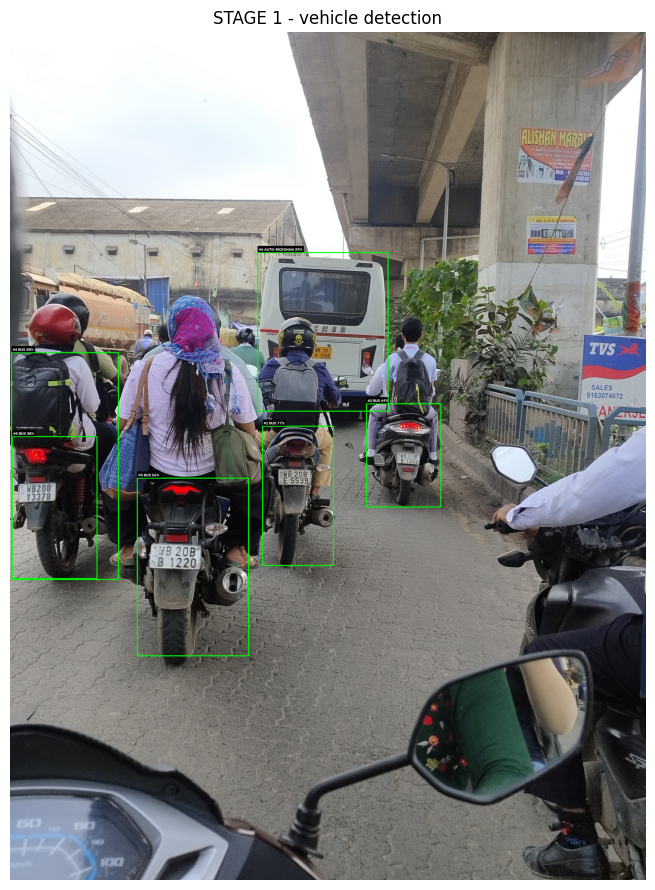

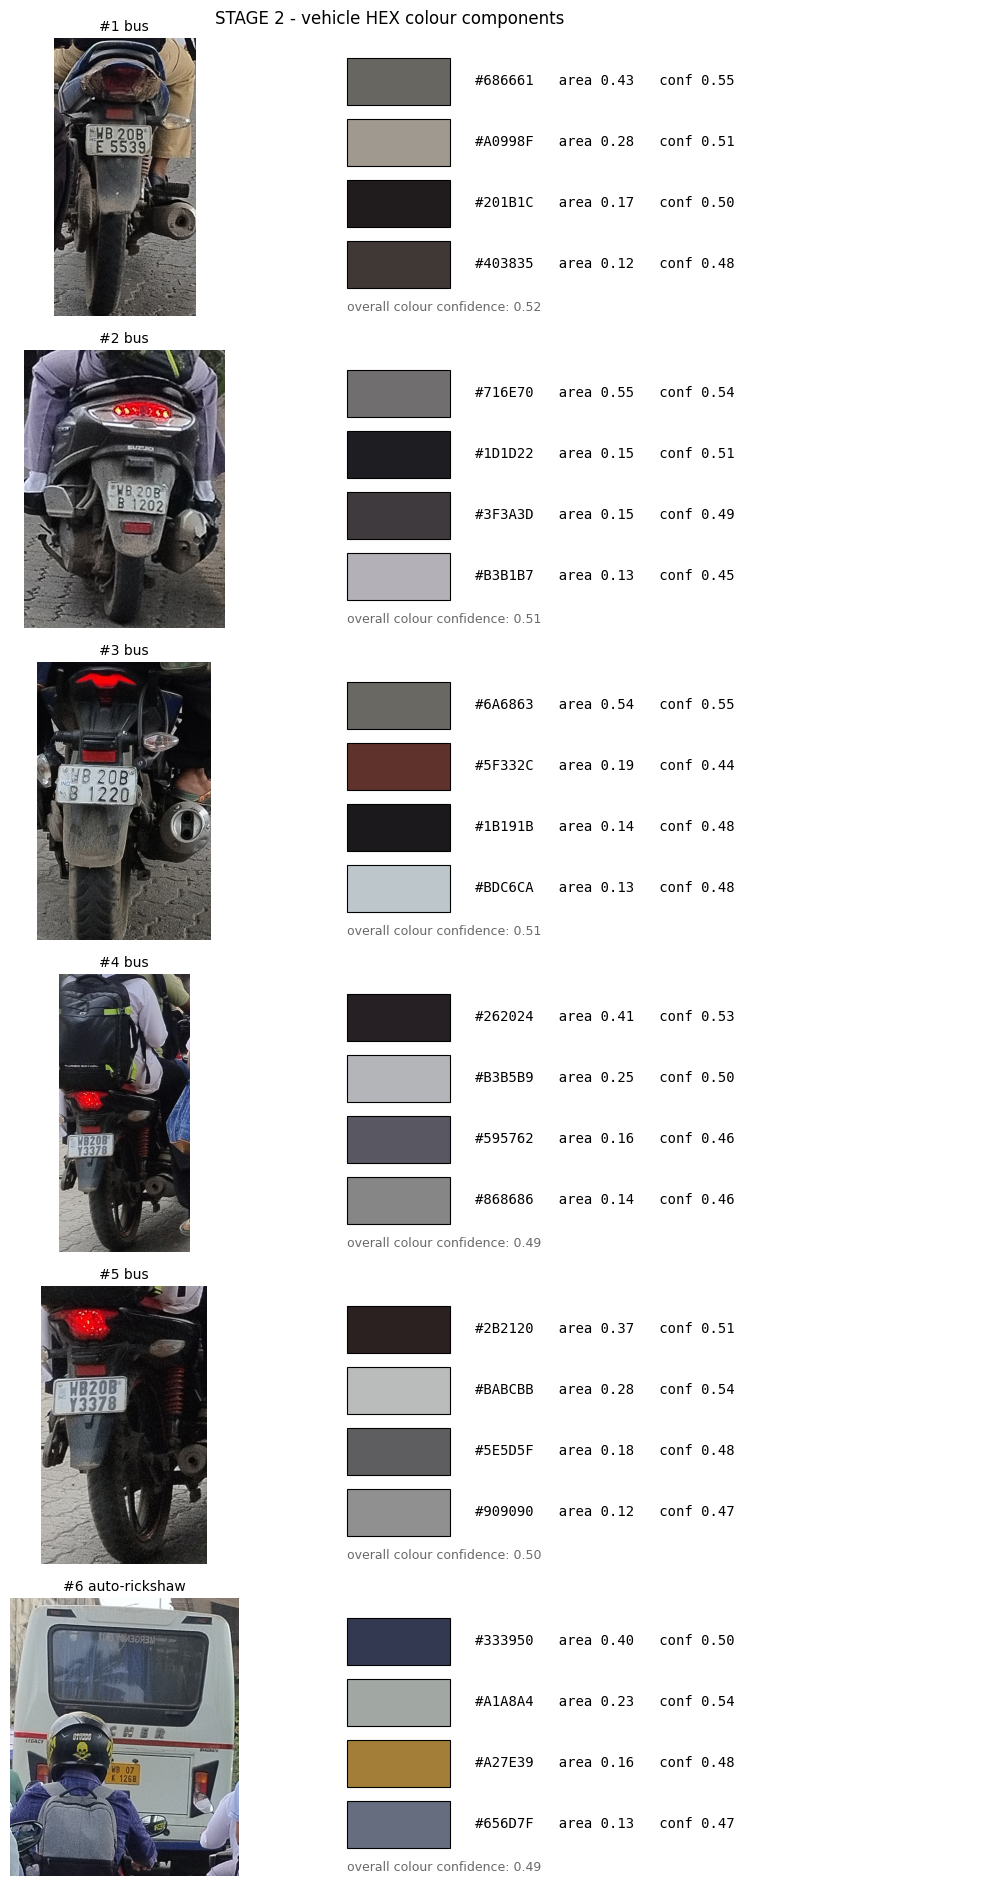

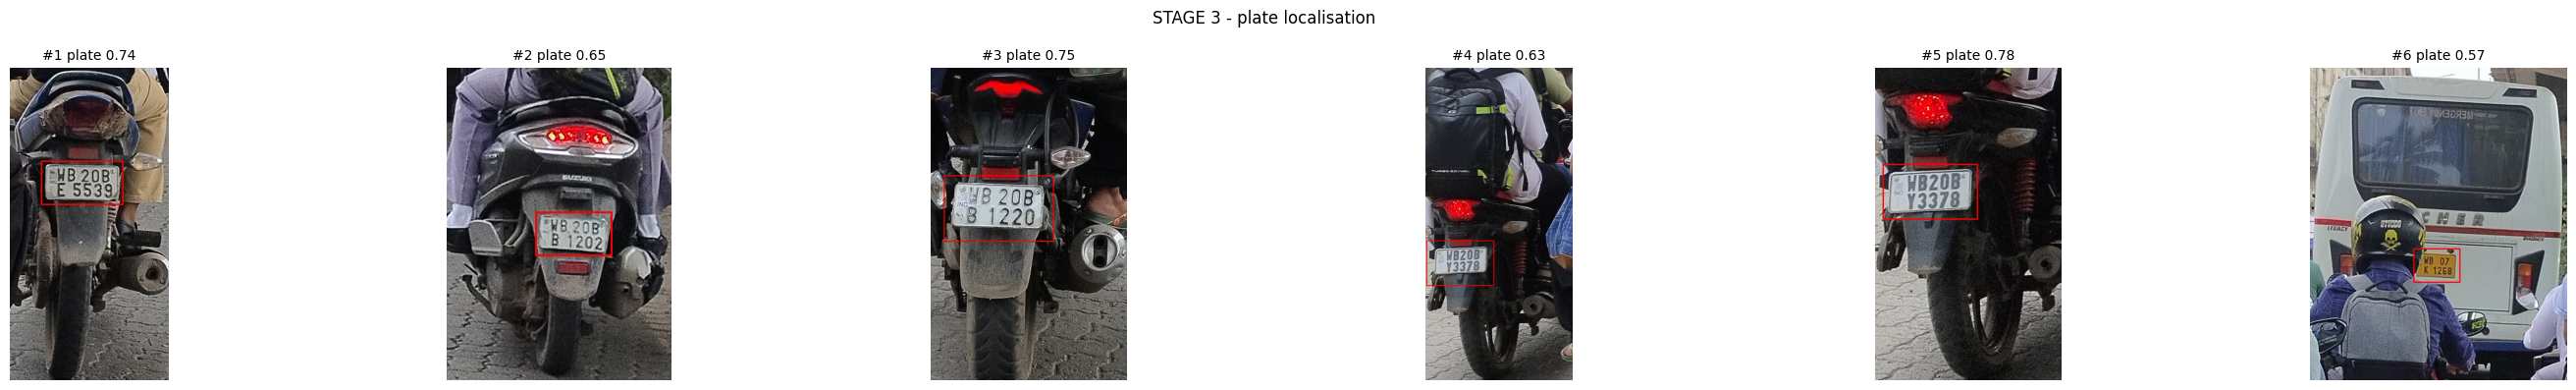

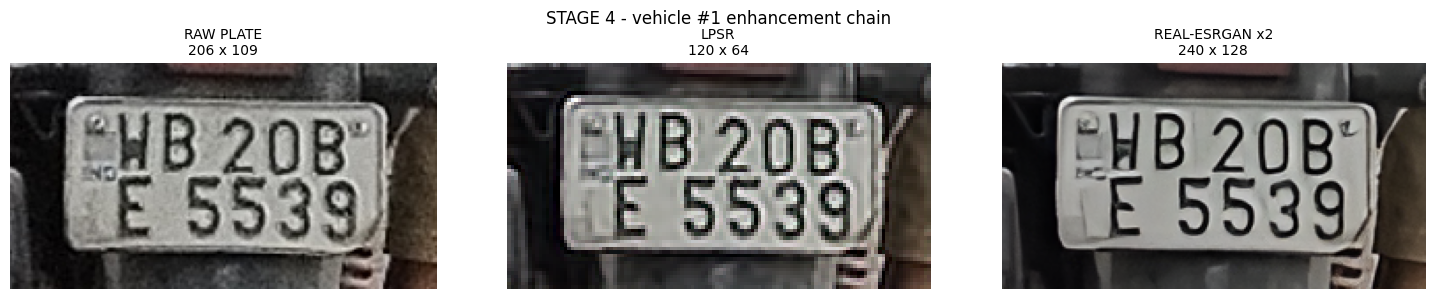

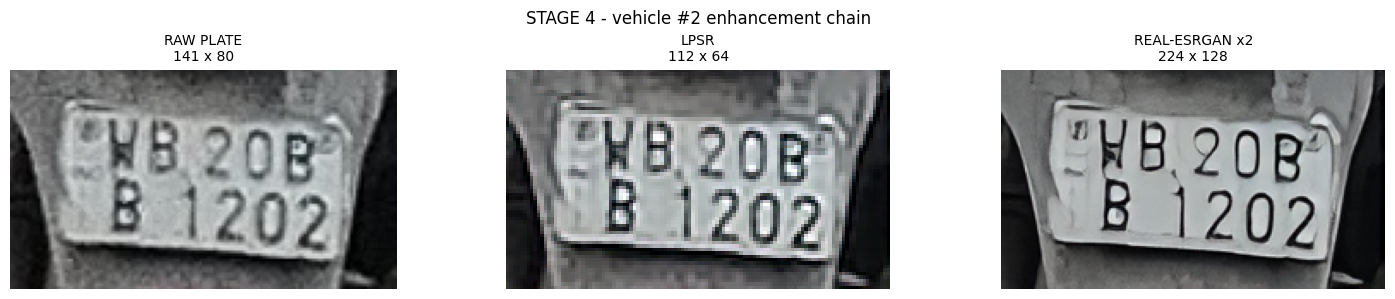

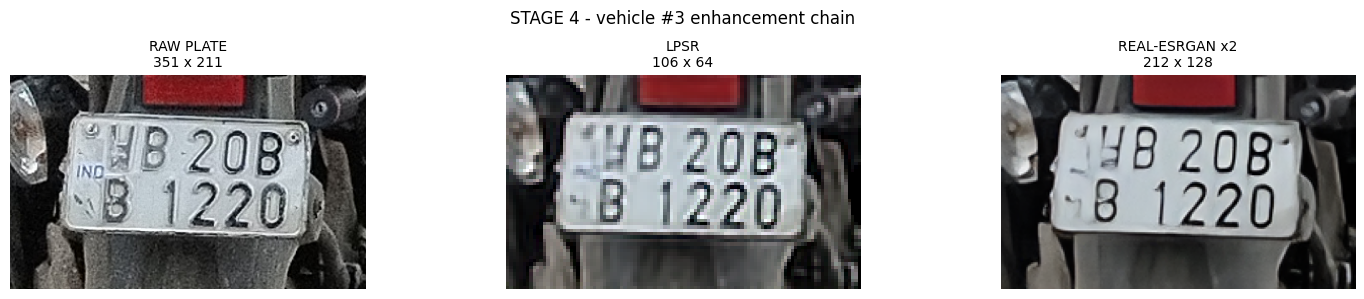

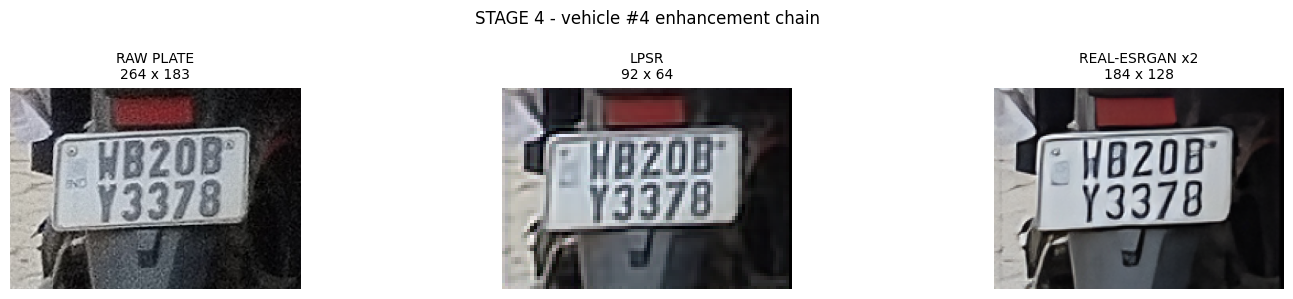

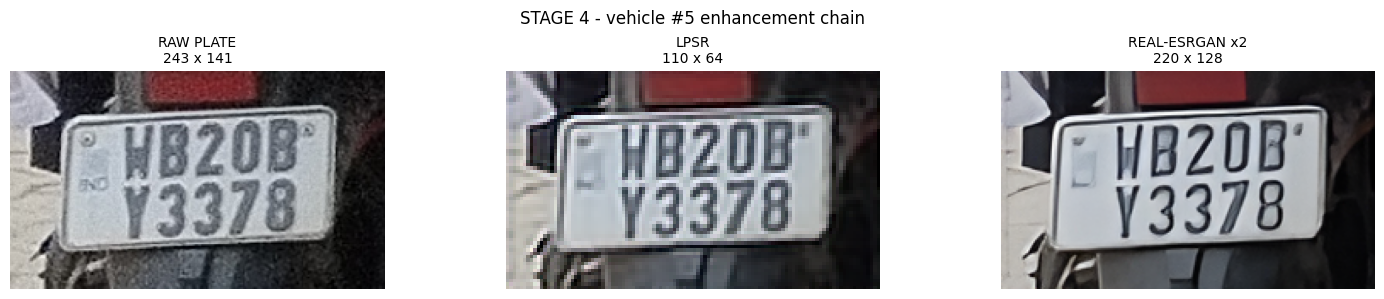

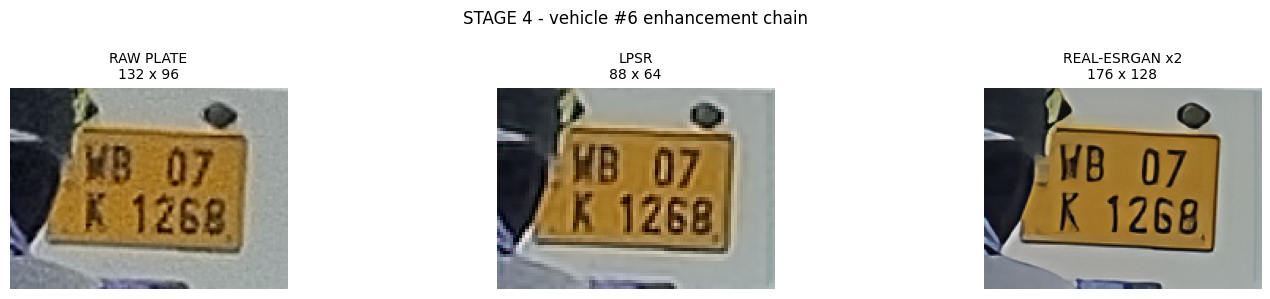

STAGE 5 -- OCR / RANKED OCR OPTIONS

Vehicle #1  bus  [complete]
  CHAR.PT OUTPUT      : WB20BE55389 (conf 0.74)
  TrOCR OUTPUT        : PB388 (conf 0.53)

  RANKED OCR OPTIONS:
       1. WB20BES5389    score=2.827 conf=0.73 enh=raw      reader=unknown
       2. WB20BE5539     score=2.179 conf=0.74 enh=esrgan   reader=unknown
       3. WB20E5539      score=1.640 conf=0.77 enh=lpsr     reader=unknown
       4. WB20BE55389    score=0.969 conf=0.80 enh=raw      reader=unknown
       5. PB20BE5539     score=0.651 conf=0.35 enh=esrgan   reader=unknown
       6. PB30BE5539     score=0.651 conf=0.35 enh=esrgan   reader=unknown
       7. PB38BE5539     score=0.651 conf=0.35 enh=esrgan   reader=unknown
       8. PB0BE5539      score=0.573 conf=0.35 enh=esrgan   reader=unknown
       9. PB3BE5539      score=0.573 conf=0.35 enh=esrgan   reader=unknown
      10. WB20B388       score=0.515 conf=0.60 enh=raw      reader=unknown

  GENERATED OCR CANDIDATES:
       1. WB20BES5389    score=5.204 conf=0

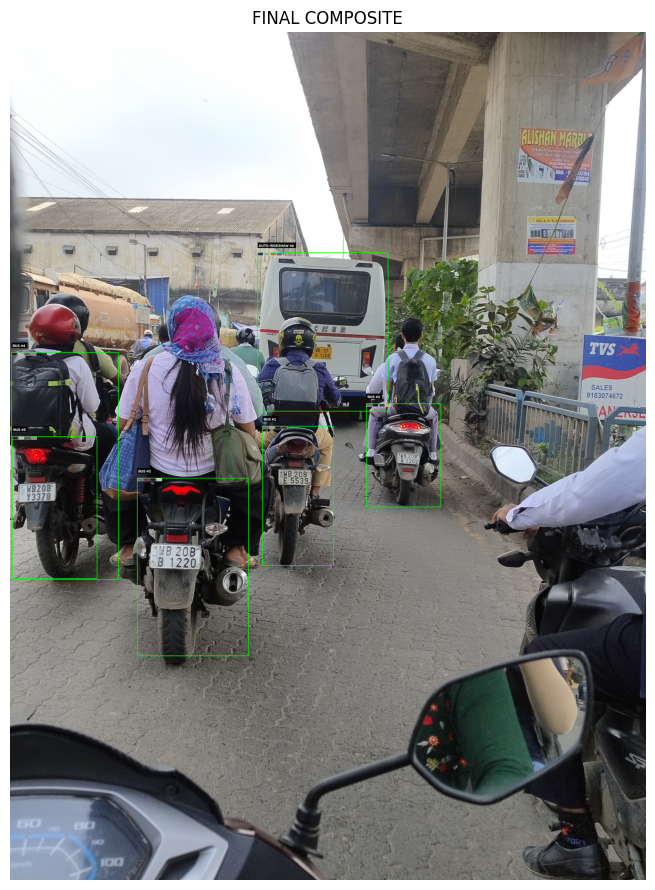

Saved: /content/output/final_composite.png

OCR MATRIX -- char.pt AND TrOCR x RAW / LPSR / ESRGAN

Vehicle #1 (bus)
  variant  | char.pt                      | TrOCR                       
  ----------------------------------------------------------------------
  raw      | WB20BE55389      conf 0.80   | PB388            conf 0.47  
  lpsr     | WB20E5539        conf 0.77   | 8388             conf 0.47  
  esrgan   | WB20BE5539       conf 0.74   | PB388            conf 0.53  
  ----------------------------------------------------------------------
  PER-VARIANT OCR CANDIDATES:

    ranked(raw) -> top candidates:
        1. WB20BES5389    score=1.225 conf=0.73 valid=True enh=selected reader=char.pt via=ocr_variation
        2. WB20BE55389    score=0.413 conf=0.80 valid=False enh=selected reader=char.pt via=model_read
        3. PB388          score=0.136 conf=0.47 valid=False enh=selected reader=TrOCR via=model_read
        4. PB20BE55389    score=0.112 conf=0.27 valid=False enh=selecte

In [143]:
# ============================================================
# 25. VISUAL DEBUGGING + FULL OCR MATRIX
#     char.pt AND TrOCR x RAW / LPSR / ESRGAN
# ============================================================


# ------------------------------------------------------------
# HELPER: SAFE OCR CANDIDATE ACCESS
# ------------------------------------------------------------

def _get_ranked_ocr_options(plate):
    """
    v6.4 canonical OCR output.

    Returns the ranked OCR options without assuming that the
    old plate-level `final_text` / `ocr_confidence` fields exist.
    """
    if not isinstance(plate, dict):
        return []

    return plate.get("ocr_ranked_options") or []


def _get_top_ocr_candidate(plate):
    """
    Return the highest-ranked OCR candidate, or None.
    """
    options = _get_ranked_ocr_options(plate)

    if not options:
        return None

    return options[0]


# ------------------------------------------------------------
# STAGE 5 -- OCR
# ------------------------------------------------------------

def show_stage5_ocr(result):
    """
    Display OCR reader outputs, generated candidates, ranked
    OCR options, and fusion diagnostics.

    v6.4 does NOT use a single plate-level:
        - final_text
        - top-ranked candidate
        - ocr_confidence

    Instead, the canonical public OCR result is:
        plate["ocr_ranked_options"]

    Confidence belongs to individual OCR candidates/readers.
    """

    print("=" * 78)
    print("STAGE 5 -- OCR / RANKED OCR OPTIONS")
    print("=" * 78)

    vehicles = result.get("vehicles") or []

    if not vehicles:
        print("\nNo vehicle records available.")
        print("=" * 78)
        return

    for vehicle in vehicles:

        vehicle_id = vehicle.get("vehicle_id", "?")
        class_name = vehicle.get("class_name", "?")
        status = vehicle.get("status", "?")

        print()
        print(
            f"Vehicle #{vehicle_id}  "
            f"{class_name}  "
            f"[{status}]"
        )

        plate = vehicle.get("license_plate")

        if not plate:
            print("  PLATE              : not detected")
            print("-" * 78)
            continue

        # ----------------------------------------------------
        # Individual OCR readers
        # ----------------------------------------------------

        char_text = plate.get("char_pt_text") or "(none)"
        char_conf = plate.get("char_pt_confidence", 0.0)

        trocr_text = plate.get("trocr_text") or "(none)"
        trocr_conf = plate.get("trocr_confidence", 0.0)

        print(
            f"  CHAR.PT OUTPUT      : {char_text} "
            f"(conf {char_conf:.2f})"
        )

        print(
            f"  TrOCR OUTPUT        : {trocr_text} "
            f"(conf {trocr_conf:.2f})"
        )

        # ----------------------------------------------------
        # Ranked OCR options
        # ----------------------------------------------------

        print()
        print("  RANKED OCR OPTIONS:")

        options = _get_ranked_ocr_options(plate)

        if not options:

            print("      (none)")

        else:

            for rank, candidate in enumerate(options[:10], 1):

                text = candidate.get("text") or "(none)"
                score = candidate.get("score", 0.0)
                confidence = candidate.get("confidence", 0.0)

                enhancement = candidate.get(
                    "enhancement",
                    candidate.get("variant", "unknown"),
                )

                reader = candidate.get(
                    "recognition_model",
                    candidate.get("reader", "unknown"),
                )

                print(
                    f"      {rank:>2}. "
                    f"{text:<14s} "
                    f"score={score:.3f} "
                    f"conf={confidence:.2f} "
                    f"enh={str(enhancement):<8s} "
                    f"reader={reader}"
                )

        # ----------------------------------------------------
        # Generated OCR candidates
        # ----------------------------------------------------

        print()
        print("  GENERATED OCR CANDIDATES:")

        candidates = plate.get("ocr_candidates") or []

        if not candidates:

            print("      (none)")

        else:

            for rank, candidate in enumerate(candidates[:10], 1):

                text = candidate.get("text") or "(none)"
                score = candidate.get("score", 0.0)
                confidence = candidate.get("confidence", 0.0)
                valid_format = candidate.get(
                    "valid_format",
                    False,
                )
                construction = candidate.get(
                    "construction",
                    "",
                )

                print(
                    f"      {rank:>2}. "
                    f"{text:<14s} "
                    f"score={score:.3f} "
                    f"conf={confidence:.2f} "
                    f"valid={valid_format} "
                    f"via={construction}"
                )

        # ----------------------------------------------------
        # Top candidate diagnostics
        # ----------------------------------------------------

        top_candidate = _get_top_ocr_candidate(plate)

        print()
        print("  TOP-RANKED OCR:")

        if top_candidate is None:

            print("      (none)")

        else:

            print(
                f"      text       : "
                f"{top_candidate.get('text') or '(none)'}"
            )

            print(
                f"      score      : "
                f"{top_candidate.get('score', 0.0):.3f}"
            )

            print(
                f"      confidence : "
                f"{top_candidate.get('confidence', 0.0):.2f}"
            )

            print(
                f"      valid      : "
                f"{top_candidate.get('valid_format', False)}"
            )

            print(
                f"      state      : "
                f"{top_candidate.get('state_code') or '(unknown)'}"
            )

            print(
                f"      characters : "
                f"{top_candidate.get('character_count', '(unknown)')}"
            )

            print(
                f"      enhancement: "
                f"{top_candidate.get('enhancement', top_candidate.get('variant', 'unknown'))}"
            )

            print(
                f"      reader     : "
                f"{top_candidate.get('recognition_model', top_candidate.get('reader', 'unknown'))}"
            )

        # ----------------------------------------------------
        # Crop quality
        # ----------------------------------------------------

        quality = plate.get("crop_quality") or {}

        if quality:

            print()
            print("  CROP QUALITY:")

            print(
                f"      overall    : "
                f"{quality.get('score', 0.0):.2f}"
            )

            print(
                "      sharpness={:.2f} "
                "contrast={:.2f} "
                "entropy={:.2f} "
                "edges={:.2f} "
                "exposure={:.2f} "
                "resolution={:.2f}".format(
                    quality.get("sharpness", 0.0),
                    quality.get("contrast", 0.0),
                    quality.get("entropy", 0.0),
                    quality.get("edge_structure", 0.0),
                    quality.get("exposure", 0.0),
                    quality.get("resolution", 0.0),
                )
            )

        # ----------------------------------------------------
        # Fusion diagnostics
        # ----------------------------------------------------

        print()
        print("  FUSION:")

        fusion_reason = plate.get("fusion_reason")

        if fusion_reason:
            print(f"      reason : {fusion_reason}")
        else:
            print("      reason : (none)")

        fusion_details = plate.get("fusion_details") or []

        for detail in fusion_details:
            print(f"      - {detail}")

        # ----------------------------------------------------
        # Stage errors
        # ----------------------------------------------------

        stage_errors = plate.get("stage_errors") or []

        if stage_errors:

            print()
            print("  STAGE ERRORS:")

            for error in stage_errors:
                print(f"      - {error}")

        print("-" * 78)

    print("=" * 78)


# ------------------------------------------------------------
# OCR MATRIX
# ------------------------------------------------------------

def compare_ocr_across_stages(result, max_plates=4):
    """
    Diagnostic comparison of:

        char.pt  x  RAW / LPSR / ESRGAN
        TrOCR    x  RAW / LPSR / ESRGAN

    Every available image variant is evaluated independently.

    The function does not assume that any enhancement is
    inherently better than another.

    The main pipeline's CHAR_INPUT / TROCR_INPUT settings are
    shown separately from this diagnostic matrix.

    No single "final OCR text" is assumed.
    """

    compared = 0

    print()
    print("=" * 78)
    print("OCR MATRIX -- char.pt AND TrOCR x RAW / LPSR / ESRGAN")
    print("=" * 78)

    # --------------------------------------------------------
    # Model availability
    # --------------------------------------------------------

    char_loaded = (
        isinstance(MODELS, dict)
        and MODELS.get("char") is not None
    )

    trocr_loaded = (
        isinstance(MODELS, dict)
        and MODELS.get("trocr") is not None
    )

    if not char_loaded and not trocr_loaded:

        print()
        print(
            "Neither char.pt nor TrOCR is loaded - "
            "nothing to compare."
        )

        print("=" * 78)
        return

    # --------------------------------------------------------
    # Raw vehicles are preferred because `_images` is retained
    # there for diagnostics.
    # --------------------------------------------------------

    raw_vehicles = result.get("_raw_vehicles")

    if raw_vehicles is None:
        raw_vehicles = result.get("vehicles") or []

    # --------------------------------------------------------
    # Process plates
    # --------------------------------------------------------

    for vehicle in raw_vehicles:

        if compared >= max_plates:
            break

        plate = vehicle.get("license_plate")

        if not plate:
            continue

        images = plate.get("_images")

        if not isinstance(images, dict):
            continue

        compared += 1

        print()
        print(
            f"Vehicle #{vehicle.get('vehicle_id', '?')} "
            f"({vehicle.get('class_name', '?')})"
        )

        print(
            f"  {'variant':<8s} | "
            f"{'char.pt':<28s} | "
            f"{'TrOCR':<28s}"
        )

        print("  " + "-" * 70)

        row_results = {}

        # ----------------------------------------------------
        # RAW / LPSR / ESRGAN
        # ----------------------------------------------------

        for variant in ("raw", "lpsr", "esrgan"):

            image = images.get(variant)

            # ------------------------------------------------
            # Missing image variant
            # ------------------------------------------------

            if image is None:

                if (
                    variant == "lpsr"
                    and isinstance(MODELS, dict)
                    and MODELS.get("lpsr") is None
                ):
                    reason = "model not loaded"

                elif (
                    variant == "esrgan"
                    and isinstance(MODELS, dict)
                    and MODELS.get("realesrgan") is None
                ):
                    reason = "model not loaded"

                else:
                    reason = "stage unavailable"

                print(
                    f"  {variant:<8s} | "
                    f"({reason})"
                )

                continue

            # ------------------------------------------------
            # char.pt
            # ------------------------------------------------

            if char_loaded:

                char_out = run_char_model(image) or {}

            else:

                char_out = {
                    "text": "",
                    "confidence": 0.0,
                }

            # ------------------------------------------------
            # TrOCR
            # ------------------------------------------------

            if trocr_loaded:

                trocr_out = run_trocr(image) or {}

            else:

                trocr_out = {
                    "text": "",
                    "confidence": 0.0,
                }

            row_results[variant] = (
                char_out,
                trocr_out,
            )

            # ------------------------------------------------
            # Format matrix cells
            # ------------------------------------------------

            char_text = (
                char_out.get("text")
                or "(none)"
            )

            char_conf = char_out.get(
                "confidence",
                0.0,
            )

            trocr_text = (
                trocr_out.get("text")
                or "(none)"
            )

            trocr_conf = trocr_out.get(
                "confidence",
                0.0,
            )

            char_cell = (
                f"{char_text:<16s} "
                f"conf {char_conf:.2f}"
            )

            trocr_cell = (
                f"{trocr_text:<16s} "
                f"conf {trocr_conf:.2f}"
            )

            print(
                f"  {variant:<8s} | "
                f"{char_cell:<28s} | "
                f"{trocr_cell:<28s}"
            )

        # ----------------------------------------------------
        # Per-variant fusion diagnostics
        # ----------------------------------------------------

        if row_results:

            print("  " + "-" * 70)

            print("  PER-VARIANT OCR CANDIDATES:")

            for variant, (
                char_out,
                trocr_out,
            ) in row_results.items():

                # v6.4 fuse_ocr() accepts the two reader outputs.
                fused = fuse_ocr(
                    char_out,
                    trocr_out,
                ) or {}

                candidates = (
                    fused.get("ocr_candidates")
                    or fused.get("candidates")
                    or []
                )

                print()
                print(
                    f"    ranked({variant}) -> "
                    f"top candidates:"
                )

                if not candidates:

                    print("        (none)")
                    continue

                for rank, candidate in enumerate(
                    candidates[:5],
                    1,
                ):

                    text = (
                        candidate.get("text")
                        or "(none)"
                    )

                    score = candidate.get(
                        "score",
                        0.0,
                    )

                    confidence = candidate.get(
                        "confidence",
                        0.0,
                    )

                    valid_format = candidate.get(
                        "valid_format",
                        False,
                    )

                    construction = candidate.get(
                        "construction",
                        "",
                    )

                    enhancement = candidate.get(
                        "enhancement",
                        candidate.get(
                            "variant",
                            variant,
                        ),
                    )

                    reader = candidate.get(
                        "recognition_model",
                        candidate.get(
                            "reader",
                            "?",
                        ),
                    )

                    print(
                        f"        {rank}. "
                        f"{text:<14s} "
                        f"score={score:.3f} "
                        f"conf={confidence:.2f} "
                        f"valid={valid_format} "
                        f"enh={str(enhancement):<7s} "
                        f"reader={reader} "
                        f"via={construction}"
                    )

        # ----------------------------------------------------
        # Main pipeline result
        # ----------------------------------------------------

        print()
        print(
            "  CURRENT PIPELINE SETTINGS:"
        )

        print(
            f"    CHAR_INPUT  = '{CHAR_INPUT}'"
        )

        print(
            f"    TROCR_INPUT = '{TROCR_INPUT}'"
        )

        print()
        print(
            "  CURRENT PIPELINE RANKED OPTIONS:"
        )

        pipeline_options = (
            plate.get("ocr_ranked_options")
            or []
        )

        if not pipeline_options:

            print("    (none)")

        else:

            for rank, candidate in enumerate(
                pipeline_options[:5],
                1,
            ):

                text = (
                    candidate.get("text")
                    or "(none)"
                )

                print(
                    f"    {rank}. "
                    f"{text:<14s} "
                    f"score="
                    f"{candidate.get('score', 0.0):.3f} "
                    f"conf="
                    f"{candidate.get('confidence', 0.0):.2f} "
                    f"enh="
                    f"{candidate.get('enhancement', candidate.get('variant', '?')):<7s} "
                    f"reader="
                    f"{candidate.get('recognition_model', candidate.get('reader', '?'))}"
                )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print()

    if compared == 0:

        print(
            "No plate crops with retained RAW/LPSR/ESRGAN "
            "images were available to compare."
        )

    else:

        print("-" * 78)

        print(
            "DIAGNOSTIC NOTE:"
        )

        print(
            "  Higher model confidence does NOT prove that "
            "a plate read is correct."
        )

        print(
            "  Compare the actual TEXT against the stage-4 "
            "images across several plates."
        )

        print(
            "  This matrix evaluates all available variants "
            "without assuming RAW, LPSR, or ESRGAN is best."
        )

    print("=" * 78)


# ============================================================
# RUN VISUAL DEBUGGING
# ============================================================

show_stage1_detections(result)
show_stage2_colours(result)
show_stage3_plates(result)
show_stage4_enhancement(result)
show_stage5_ocr(result)
show_final_composite(result)


# ============================================================
# RUN FULL OCR MATRIX
# ============================================================

compare_ocr_across_stages(result)

In [ ]:

# ============================================================
# PLATE VALIDATION AUDIT
# ============================================================
#
# This is the dedicated inspection unit for the new constraint engine.
#
# It answers:
#   - What did each OCR reader actually see?
#   - Which generated candidates are structurally valid?
#   - Which state code is being inferred?
#   - Why did a candidate rank where it did?
#   - How many options survived the dynamic importance cutoff?
#
# This does NOT alter the result. It is diagnostic only.
# ============================================================


def audit_plate_validation(result, max_plates=None):
    vehicles = result.get("vehicles") or []

    print("=" * 88)
    print("INDIAN LICENSE PLATE VALIDATION / RANKING AUDIT")
    print("=" * 88)

    shown = 0

    for vehicle in vehicles:

        if max_plates is not None and shown >= max_plates:
            break

        plate = vehicle.get("license_plate")

        if not plate:
            continue

        shown += 1

        print()
        print(
            f"Vehicle #{vehicle.get('vehicle_id', '?')} "
            f"({vehicle.get('class_name', '?')})"
        )

        print(
            f"  CHAR.PT : "
            f"{plate.get('char_pt_text') or '(none)'} "
            f"[{plate.get('char_pt_confidence', 0.0):.2f}]"
        )

        print(
            f"  TrOCR   : "
            f"{plate.get('trocr_text') or '(none)'} "
            f"[{plate.get('trocr_confidence', 0.0):.2f}]"
        )

        ensemble = plate.get("ocr_ensemble") or {}

        print(
            f"  Dominant frame state : "
            f"{ensemble.get('dominant_state_code') or '(none)'}"
        )

        print(
            f"  Dynamic cutoff       : "
            f"{ensemble.get('dynamic_cutoff', 0.0):.4f}"
        )

        print(
            f"  Generated candidates : "
            f"{ensemble.get('total_candidates', len(plate.get('ocr_candidates') or []))}"
        )

        print(
            f"  Final options        : "
            f"{ensemble.get('final_option_count', len(plate.get('ocr_ranked_options') or []))}"
        )

        options = plate.get("ocr_ranked_options") or []

        print()
        print("  FINAL VALIDATED OPTIONS:")

        if not options:
            print("    (none)")
            continue

        for rank, candidate in enumerate(options, 1):

            validation = (
                candidate.get("validation")
                or validate_indian_plate(
                    candidate.get("text", "")
                )
            )

            evidence = candidate.get(
                "ranking_evidence"
            ) or {}

            print(
                f"    {rank:>2}. "
                f"{candidate.get('text') or '(none)':<14s} "
                f"score={candidate.get('score', 0.0):.4f} "
                f"conf={candidate.get('confidence', 0.0):.2f} "
                f"valid={candidate.get('valid_format', False)}"
            )

            print(
                f"        type={validation.get('plate_type', '?')} "
                f"state={validation.get('state_code') or '?'} "
                f"layout={validation.get('layout', '?')}"
            )

            print(
                f"        length={candidate.get('length_evidence', 0.0):.3f} "
                f"position={candidate.get('position_evidence', 0.0):.3f} "
                f"fuzzy={candidate.get('fuzzy_support', 0.0):.3f} "
                f"state_prior={candidate.get('state_prior_factor', 1.0):.3f}"
            )

            print(
                f"        construction="
                f"{candidate.get('construction', '?')} "
                f"changes={candidate.get('changes', 0)} "
                f"sources={candidate.get('source_count', 1)}"
            )

            if candidate.get("retained_as_fallback"):
                print(
                    "        WARNING: no structurally valid "
                    "candidate existed; retained as fallback."
                )

        # Generated candidates that did not make the final list are useful
        # when debugging why an OCR hypothesis disappeared.
        generated = plate.get("ocr_candidates") or []

        invalid = [
            c for c in generated
            if not c.get("valid_format", False)
        ]

        if invalid and options:
            print()
            print(
                f"  Removed from public shortlist: "
                f"{len(invalid)} structurally invalid hypotheses."
            )

    if shown == 0:
        print("\nNo detected plates available for audit.")

    print()
    print("=" * 88)


# Run the audit for the current image.
audit_plate_validation(result)


In [144]:
# ============================================================
# 24. STRUCTURED JSON OUTPUT
# ============================================================

json_path = export_json(result, OUTPUT_DIR / "result.json")

print()
print("=" * 78)
print("STRUCTURED OUTPUT (truncated preview)")
print("=" * 78)

print_json(result, max_chars=4000)


# ------------------------------------------------------------
# Minimal backend contract
# ------------------------------------------------------------

print()
print("=" * 78)
print("BACKEND PAYLOAD")
print("=" * 78)
print(
    "HEX values are sent RAW. The backend owns HEX -> colour-name\n"
    "mapping and should use Lab / Delta-E nearest-neighbour rather\n"
    "than string equality.\n"
)

print(json.dumps(make_backend_payload(result), indent=2))

JSON written: /content/output/result.json

STRUCTURED OUTPUT (truncated preview)
{
  "frame_id": 0,
  "source": "/content/input/test.jpg",
  "frame_size": [
    3000,
    4000
  ],
  "vehicles": [
    {
      "vehicle_id": 1,
      "track_id": null,
      "class_id": 2,
      "class_name": "bus",
      "vehicle_confidence": 0.7658,
      "bbox": [
        1191,
        1859,
        1525,
        2516
      ],
      "colour_hex": [
        "#686661",
        "#A0998F",
        "#201B1C",
        "#403835"
      ],
      "colour_confidence": 0.5226,
      "colour_components": [
        {
          "hex": "#686661",
          "rgb": [
            104,
            102,
            97
          ],
          "area_ratio": 0.4292,
          "confidence": 0.5521,
          "lab_cv": [
            110.09181549328981,
            128.99360483984478,
            131.13095693061993
          ],
          "merged_clusters": 2
        },
        {
          "hex": "#A0998F",
          "rgb": [
    

In [145]:
# ============================================================
# 25. VIDEO TEST  (optional)
# ============================================================
#
# Switching to video does NOT require rewriting anything -- the
# same stage functions are used, with tracking and temporal
# colour fusion layered on top.
#
# Set RUN_VIDEO = True after placing a file at TEST_VIDEO.
# ============================================================

RUN_VIDEO = False

TEST_VIDEO = "/content/input/test.mp4"


if RUN_VIDEO:

    video_result = run_video_pipeline(
        TEST_VIDEO,
        max_frames=VIDEO_MAX_FRAMES,     # None = whole video
        frame_stride=VIDEO_FRAME_STRIDE,
    )

    export_json(video_result, OUTPUT_DIR / "video_result.json")

    print()
    print("=" * 78)
    print("PER-TRACK SUMMARY (temporally fused)")
    print("=" * 78)

    for track_id, state in sorted(
        video_result["tracks"].items(),
        key=lambda kv: (kv[0] is None, kv[0]),
    ):
        print()
        print(f"Track ID: {track_id}")
        print(f"Class: {state['class_name']}")
        print(f"Frames seen: {state['frames_seen']}")

        print("Colours (temporally fused):")
        if state["colour_hex"]:
            for component in state["colour_components"]:
                print(
                    f"    {component['hex']}   "
                    f"weight {component['area_ratio']:.2f}   "
                    f"conf {component['confidence']:.2f}   "
                    f"({component['observations']} observations)"
                )
        else:
            print("    (none)")

        print(
            f"Plate (confidence-weighted vote): "
            f"{state.get('voted_text') or '-'}"
        )
        print(
            f"Plate (single best ranked frame) : "
            f"{state.get('best_text') or '-'}"
            f"  rank score {state.get('best_ocr_rank_score', 0.0):.3f}"
        )

        if state.get("vote_distribution"):
            print(f"Vote distribution: {state['vote_distribution']}")

        print("-" * 78)

    print(f"\nAnnotated video: {video_result['video']['annotated_output']}")

else:
    print(
        "Video stage skipped.\n\n"
        "To run it:\n"
        "  1. put a video at /content/input/test.mp4\n"
        "  2. set RUN_VIDEO = True in this cell\n"
        "  3. re-run this cell\n\n"
        "Nothing else changes -- the pipeline functions are shared."
    )

Video stage skipped.

To run it:
  1. put a video at /content/input/test.mp4
  2. set RUN_VIDEO = True in this cell
  3. re-run this cell

Nothing else changes -- the pipeline functions are shared.


# 26. Troubleshooting

### Model loading

**`USER MUST PROVIDE THIS MODEL`** — the path in `MODEL_CONFIG` doesn't exist. Place the checkpoint in `DRIVE_MODEL_DIR` (recommended). The notebook copies it into `/content/models/` and loads only that runtime copy. The **config cell's readiness table runs before any model loads** and will already say `MISSING` next to the exact path it expects — check that table first; if a model shows `MISSING` there, the load cell reporting `NOT LOADED` right after is not a bug, it's the same fact reported twice. `load_lpsr_model` (and the vehicle/plate/char loaders) never silently substitute a different file or skip the check.

**`ultralytics.YOLO could not load ...`** — YOLO itself rejected the file. The printed diagnostics (detected kind, top-level keys, tensor keys) tell you what it actually is. If it is not a YOLO model, define the correct module yourself and assign it into `MODELS["vehicle"]` (or whichever slot) directly.

**Pipeline says "No vehicles detected" but a standalone notebook detects them** — check the LOAD SUMMARY first; if the vehicle model shows `NOT LOADED`, nothing downstream can work and the message is misleading. Then run the **sanity-check cell**, which calls the model directly with the same arguments a minimal standalone notebook uses and compares that against `detect_vehicles()`. It separates "the model sees nothing" from "the wrapper around it is at fault".

**`You need to have sentencepiece or tiktoken installed`** (TrOCR) — despite the wording, this is usually **not** a missing package. Check: if `sentencepiece` shows a version in the install-cell output but you still see this error, the real cause is `transformers` v5 — it removed the old slow/fast tokenizer split, and `microsoft/trocr-base-printed`'s legacy tokenizer files don't reliably convert under the new consolidated backend. The install cell pins `transformers<5.0.0` for exactly this reason. If you still hit it: **Runtime → Restart session**, then re-run every cell from the top including the install cell — a v5 import already sitting in memory from an earlier run survives a plain re-run of the install cell, since pip cannot hot-swap an already-imported package. The load-model cell will tell you plainly if v5 is still active.

**LPSR `load_state_dict` size mismatch** — your checkpoint isn't `features=64, num_blocks=4`. Read the shapes off the error and adjust the `TraffiqLPSR(...)` arguments in `load_lpsr_model`. Do **not** switch to `strict=False`: a partial load produces plausible-looking but wrong images with no warning.

**LPSR loads but output looks like noise** — check `checkpoint.get("epoch")` in the load log. A very early checkpoint hasn't learned the residual yet.

### Real-ESRGAN

**`realesrgan_not_available`** — the weight download failed (Colab occasionally can't reach GitHub releases). Download `RealESRGAN_x2plus.pth` manually and place it at `/content/models/`. The pipeline runs without it; the ESRGAN stage is simply skipped and LPSR output flows straight to OCR.

**Weight file under 50 MB** — truncated download. Delete it and re-run the load cell.

**Trying `REALESRGAN_BACKEND = "basicsr"` and getting `No module named 'torchvision.transforms.functional_tensor'`** — this is the exact breakage your original notebook built a venv to escape. Either stay on `"inline"` (recommended) or create the shim: a file at `torchvision/transforms/functional_tensor.py` containing `from torchvision.transforms.functional import rgb_to_grayscale`.

### Detection and OCR

**No vehicles detected** — lower `VEHICLE_CONF`; confirm `VEHICLE_IMGSZ = 960` matches how the model was trained (changing it changes the detection statistics); check the class mapping printed at load time is what you expect.

**Plates never detected** — set `PLATE_SEARCH_IN_VEHICLE_CROP = False` to search the whole frame. If plates then appear, the vehicle boxes are cropping them out; raise `PLATE_VEHICLE_CROP_PADDING`.

**`no_characters_detected`** — the enhanced crop may be too small or too degraded. Try `CHAR_INPUT = "raw"` or `"lpsr"`, and lower `CHAR_CONF`. Look at the stage-4 panel: if the raw crop is illegible to you, no enhancement will fix it.

**Characters come out scrambled** — a two-line plate whose rows weren't separated. Check `char_pt_rows` in the output; if it's 1 on a visibly two-line plate, lower `ROW_GAP_FACTOR` (default 0.60).

**TrOCR returns garbage or English words** — expected on hard crops; the model isn't fine-tuned on Indian plates. Run `compare_trocr_inputs()` and switch `TROCR_INPUT`. Fusion already discounts it when char.pt is more confident.

**Plate ranking is too aggressive** — tune `OCR_STATE_PRIOR_STRENGTH`, `OCR_LENGTH_PRIOR_STRENGTH`, `OCR_FORMAT_PRIOR_STRENGTH`, `OCR_FUZZY_PRIOR_STRENGTH`, and the smooth RAW/LPSR/ESRGAN quality gains. Candidates are never discarded solely because they fail the format or state prior.

### Colour

**One HEX returned for a visibly two-tone vehicle** — lower `COLOUR_MIN_AREA_RATIO` (the second colour is being filtered as insignificant) or lower `COLOUR_MERGE_DELTA_E` (the two colours are being merged as perceptually similar).

**Too many near-identical HEX values** — raise `COLOUR_MERGE_DELTA_E`, or raise `COLOUR_MIN_AREA_RATIO`.

**Colour is clearly the road or sky** — GrabCut picked the background. Check `foreground_ratio` via `estimate_vehicle_colours(..., return_debug=True)`; the `[0.18, 0.96]` fallback guard should catch most of these.

### Video

**Track IDs change constantly** — frames must reach `model.track()` consecutively and through the same model instance. A large `VIDEO_FRAME_STRIDE` breaks ByteTrack's motion assumptions; keep it at 1–2.

**Very slow** — expected; the OCR chain is the cost. Raise `OCR_REFRESH_EVERY_N_FRAMES`, lower `OCR_GOOD_ENOUGH_CONF`, or set `VIDEO_MAX_FRAMES` while testing.

### Colab

**Out of memory** — restart the runtime; reduce `VEHICLE_IMGSZ`; set `REALESRGAN_TILE = 256` if you ever run ESRGAN on full frames.

**Everything slow, `CUDA available: False`** — Runtime → Change runtime type → GPU.

---

## What this notebook does not claim

There is no labelled evaluation set attached, so there is **no accuracy figure** anywhere. Every result carries a model confidence and a status field. A high confidence is not a correctness guarantee — most importantly, Real-ESRGAN produces confident, sharp, plausible detail on inputs that never contained it, which is exactly why two independent OCR readers are fused and why the fusion reasoning is printed rather than hidden.